# Mataquito River — Quartz & Zircon Fertility and Flux Analysis

Monte Carlo error propagation combining flux-ordered ¹⁰Be erosion rates with detritalPy-mix bootstrap mixing coefficients.

---

## What this notebook produces

For every parent/child scenario, and for **both goodness-of-fit metrics** (`vmax` and `r2-kde`), four ratios:

| quantity | symbol | meaning |
|---|---|---|
| Quartz fertility | $Q_A/Q_B$ | quartz **concentration** per unit rock in A relative to B |
| Quartz flux ratio | $F_{QA}/F_{QB}$ | quartz **mass delivered** per unit time by A relative to B |
| Zircon fertility | $Z_A/Z_B$ | zircon **concentration** per unit rock in A relative to B |
| Zircon flux ratio | $F_{ZA}/F_{ZB}$ | zircon **mass delivered** per unit time by A relative to B |

**Fertility and flux are different quantities.** The fertility ratio says nothing on its own about how much sediment a tributary delivers — that requires multiplying by $E \cdot A$. Reporting a fertility ratio as though it were a yield is an error; both are reported here, separately and explicitly.

## Conventions

- **Sample A (numerator)** is always the fast-eroding / Principal Cordillera parent: CT-5, or CT-8.2 (or CT-4/CT-10/CT-11 in the exploratory scenarios).
- **Sample B (denominator)** is always CT-6 or CT-3\*.
- **Erosion rate uncertainty:** external throughout (includes production-rate uncertainty).
- **Units:** erosion rate m/Myr; area km²; production rate atoms/g/yr. Flux proxy $E \cdot A$ therefore has units m·km²/Myr.

## Sections

1. Imports and directory structure
2. Load sample data
3. Monte Carlo erosion rate samples
4. Flux ordering
5. Flux-ordered erosion rate plots
6. The equations
7. Scenario registry (CT-3\* areas)
8. Load mixing model results (both metrics)
9. Mixing coefficient violin plots
10. Quartz fertility and flux
11. Zircon fertility and flux
12. Fertility and flux violin plots
13. Distribution plots
14. Flux-ordering sensitivity
15. Results summary and table exports

---

## 1. Imports and directory structure

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import sys; sys.path.insert(0, '..')

from mataquito.sample_data import load_samples, get_areas, get_production_rates
from mataquito.revised_erosion import generate_mc_samples, flux_order_samples, raw_triples
from mataquito.revised_fertility import (
    load_mixing_results,
    quartz_fertility,
    zircon_fertility,
    ct3_star_area,
    ratio_stats,
    fmt_lin,
    fmt_log,
    THRESHOLD,
)

# ── Font handling for vector export ──────────────────────────────────────────
# Type-42 (TrueType) embedding in PDF, and live text (not paths) in SVG, so that
# figures remain editable in Illustrator.
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'

# ── Directory structure ──────────────────────────────────────────────────────
BASE_DIR = Path.cwd().parent                    # notebooks/ -> Mataquito/
DATA_DIR = BASE_DIR / 'data'
FIG_DIR  = BASE_DIR / 'figures'
RES_DIR  = BASE_DIR / 'results'

FERT_FIG_DIR   = FIG_DIR / 'fertility'          # figure outputs (PDF)
FERT_RES_DIR   = RES_DIR / 'fertility'          # table outputs (CSV)
MIXING_RES_DIR = RES_DIR / 'mixing_coefficients'  # detritalPy-mix xlsx inputs

for folder in [FERT_FIG_DIR, FERT_RES_DIR]:
    os.makedirs(folder, exist_ok=True)

print(f"BASE_DIR resolves to : {BASE_DIR}")
print(f"Reading mixing results from : {MIXING_RES_DIR}")
print(f"Figures -> {FERT_FIG_DIR}")
print(f"Tables  -> {FERT_RES_DIR}")

# ── Run parameters ───────────────────────────────────────────────────────────
N      = 100_000   # Monte Carlo draws per site for erosion rate distributions
M      = 10_000    # Monte Carlo draws for zircon fertility (matched to the
                   # 10,000 detritalPy-mix bootstrap iterations)
SEED   = 17        # master seed; every RNG in this notebook is local & seeded
METRICS = ['vmax', 'r2kde']   # both goodness-of-fit criteria

# Set SAVE_FIGS = True to write all PDFs, or leave False and uncomment individual savefig calls for the ones you need.
SAVE_FIGS = True

def savefig(fig, name):
    """Save a figure as PDF into FERT_FIG_DIR, if SAVE_FIGS is enabled."""
    if SAVE_FIGS:
        path = FERT_FIG_DIR / f'{name}.pdf'
        fig.savefig(path, bbox_inches='tight')
        print(f'  saved {path.name}')

BASE_DIR resolves to : /Users/Glong1/Desktop/Andes/Chapter_1_Manuscript/MataquitoWatershedAnalysis/Mataquito
Reading mixing results from : /Users/Glong1/Desktop/Andes/Chapter_1_Manuscript/MataquitoWatershedAnalysis/Mataquito/results/mixing_coefficients
Figures -> /Users/Glong1/Desktop/Andes/Chapter_1_Manuscript/MataquitoWatershedAnalysis/Mataquito/figures/fertility
Tables  -> /Users/Glong1/Desktop/Andes/Chapter_1_Manuscript/MataquitoWatershedAnalysis/Mataquito/results/fertility


---

## 2. Load sample data

Note that `CT-8.2` in the zircon dataset corresponds to `CT-8` in the sample
spreadsheet — they are the same sample. The zircon-side label carries the `.2`
suffix; the ¹⁰Be-side label does not.


In [2]:
df = load_samples()

print(df[['Sample_ID', 'Source_Area', 'Erosion_rate',
          'Erosion_rate_uncertainty_internal',
          'Erosion_rate_uncertainty_external',
          'Surface_Production_Rate']].to_string(index=False))

A = get_areas(df)             # {Sample_ID: km^2}
P = get_production_rates(df)  # {Sample_ID: atoms/g/yr}

Sample_ID  Source_Area  Erosion_rate  Erosion_rate_uncertainty_internal  Erosion_rate_uncertainty_external  Surface_Production_Rate
     CT-1     1385.185          22.9                              0.281                               1.86                20.280812
     CT-2     5760.128          94.8                              1.810                               7.73                13.032630
     CT-3      189.205          29.5                              0.556                               2.42                 5.512812
     CT-4     4706.717          29.6                              0.594                               2.44                14.333800
     CT-5     1495.897         387.0                              9.230                              32.00                18.111600
     CT-6     2573.245          29.8                              0.566                               2.44                14.672780
     CT-7     1207.810         532.0                             30.600     

In [3]:
# ── Sanity check: does the two-parent model tile each child basin? ───────────
# The mass balance (manuscript Eq. 3) assumes A_C ~= A_A + A_B. Quantify the gap
# so the approximation is visible rather than buried in a "~=" sign.
#
# This does NOT invalidate the analysis:
#   - the QUARTZ FLUX ratio is area-independent (the areas cancel exactly)
#   - the ZIRCON FLUX ratio is w_a/w_b, which involves no areas at all
# but the two FERTILITY ratios do carry the assumption, so its size matters.

A_parents_56 = A['CT-5'] + A['CT-6']
print(f"A(CT-5) + A(CT-6) = {A_parents_56:.3f} km^2\n")
print(f"{'child':<8} {'A_child':>10} {'unaccounted':>12} {'% of child':>11}")
print('-' * 45)
for c in ['CT-4', 'CT-10', 'CT-11', 'CT-8']:
    gap = A[c] - A_parents_56
    print(f"{c:<8} {A[c]:>10.3f} {gap:>12.3f} {100*gap/A[c]:>10.1f}%")

print("\nThe unaccounted area is the below-confluence subwatershed lying between")
print("the Teno/Lontue confluence and each downstream sample point. The two-parent")
print("model assigns its sediment contribution to CT-5 and CT-6. This is a stated")
print("limitation, and it is distinct from the sediment-storage (bypass) argument:")
print("bypass constrains STORAGE; this approximation concerns local PRODUCTION.")

A(CT-5) + A(CT-6) = 4069.142 km^2

child       A_child  unaccounted  % of child
---------------------------------------------
CT-4       4706.717      637.575       13.5%
CT-10      4864.942      795.800       16.4%
CT-11      4913.334      844.192       17.2%
CT-8       4950.395      881.253       17.8%

The unaccounted area is the below-confluence subwatershed lying between
the Teno/Lontue confluence and each downstream sample point. The two-parent
model assigns its sediment contribution to CT-5 and CT-6. This is a stated
limitation, and it is distinct from the sediment-storage (bypass) argument:
bypass constrains STORAGE; this approximation concerns local PRODUCTION.


---

## 3. Monte Carlo erosion rate samples

Erosion rates are drawn from a normal distribution with mean equal to the measured
rate and standard deviation equal to the **external** uncertainty, which includes
production-rate scaling, spallation and muogenic contributions (Balco et al., 2008).


In [4]:
ER = generate_mc_samples(df, N=N, seed=SEED)

print(f"{'Sample':<8} {'measured':>10} {'sigma_ext':>10} {'MC median':>10} {'25th':>9} {'75th':>9}")
print('-' * 60)
for _, row in df.iterrows():
    sid = row['Sample_ID']
    p25, p50, p75 = np.percentile(ER[sid], [25, 50, 75])
    print(f"{sid:<8} {row['Erosion_rate']:>10.1f} "
          f"{row['Erosion_rate_uncertainty_external']:>10.2f} "
          f"{p50:>10.2f} {p25:>9.2f} {p75:>9.2f}")

Sample     measured  sigma_ext  MC median      25th      75th
------------------------------------------------------------
CT-1           22.9       1.86      22.89     21.65     24.15
CT-2           94.8       7.73      94.83     89.61    100.06
CT-3           29.5       2.42      29.49     27.86     31.12
CT-4           29.6       2.44      29.60     27.95     31.24
CT-5          387.0      32.00     386.96    365.27    408.65
CT-6           29.8       2.44      29.80     28.16     31.46
CT-7          532.0      52.00     532.41    497.31    567.10
CT-8          263.0      22.90     263.03    247.46    278.53
CT-9          105.0       8.55     105.02     99.22    110.83
CT-10         246.0      21.30     246.16    231.79    260.41
CT-11         286.0      24.50     285.98    269.44    302.43


---

## 4. Flux ordering

**Physical constraint:** downstream sediment flux ($E \times A$) must be at least
as large as the sum of the upstream fluxes.

$$E_C A_C \;\ge\; E_A A_A + E_B A_B$$

Monte Carlo iterations violating this are discarded; the surviving parent
distributions are resampled with replacement back to $N$.

**Ordering chain (as stated in the manuscript Methods):**

- CT-7 → CT-5
- CT-1 → CT-6
- CT-5 + CT-6 → CT-10 / CT-11 / CT-8
- CT-3 is hydrologically independent (no upstream constraint)
- CT-4 is excluded from ordering (poorly mixed sample)
- CT-2 and CT-9 are not ordered (the Central Depression reach involves deposition
  and bypass, so a strict ordering statement is not meaningful across it)

### What $E \cdot A$ actually is

A ¹⁰Be catchment-averaged erosion rate is a **quartz-flux-weighted** mean, not an
area-weighted mean, because the nuclide concentration of the sediment is the
quartz-flux-weighted average of its sources. So $E \cdot A$ is a *quartz-weighted
flux proxy*, not a bulk sediment mass flux, and the ordering constraint is a
physically motivated **prior** rather than a statement of mass conservation.

This is why the apparent fluxes at CT-10/CT-11/CT-8.2 exceed the sum of the parent
fluxes by 50–70%: the Teno is both faster-eroding and (per this study's result)
more quartz-fertile, which pulls the apparent downstream erosion rate upward. That
excess *is* the fertility signal, not a mass-balance failure.


In [5]:
# Apply flux-ordering (mass-balance) constraint to the raw MC samples
fo = flux_order_samples(ER, A, N=N, seed=SEED)

# Report retention per constraint (~100% = inert, lower = doing work)
print("Retention by constraint:")
print(f"{'constraint':<28} {'retained':>10}")
print('-' * 40)
for name, frac in fo['retained'].items():
    print(f"{name:<28} {100*frac:>9.1f}%")
print()

# Show why CT-7 -> CT-5 binds: flux proxy = E * A, upstream must not exceed downstream
print("Only CT-7 -> CT-5 actually binds. The measured values violate it:")
f7 = df.set_index('Sample_ID').loc['CT-7', 'Erosion_rate'] * A['CT-7']   # upstream flux
f5 = df.set_index('Sample_ID').loc['CT-5', 'Erosion_rate'] * A['CT-5']   # downstream flux
print(f"  E(CT-7) * A(CT-7) = {f7:,.0f} m.km^2/Myr")
print(f"  E(CT-5) * A(CT-5) = {f5:,.0f} m.km^2/Myr   <-- smaller, so the")
print(f"                                                 constraint is violated")

# One-sided truncation shifts CT-5's median up; report the size of the shift
print(f"\nThe filter therefore shifts CT-5 upward:")
print(f"  raw     median = {np.median(ER['CT-5']):.2f} m/Myr")
print(f"  ordered median = {np.median(fo['CT5_res']):.2f} m/Myr "
      f"({100*(np.median(fo['CT5_res'])/np.median(ER['CT-5']) - 1):+.1f}%)")

Retention by constraint:
constraint                     retained
----------------------------------------
CT-7 -> CT-5                      20.8%
CT-1 -> CT-6                     100.0%
CT-5 + CT-6 -> CT-10             100.0%
CT-5 + CT-6 -> CT-11             100.0%
CT-5 + CT-6 -> CT-8              100.0%
CT-4 (unconstrained)             100.0%

Only CT-7 -> CT-5 actually binds. The measured values violate it:
  E(CT-7) * A(CT-7) = 642,555 m.km^2/Myr
  E(CT-5) * A(CT-5) = 578,912 m.km^2/Myr   <-- smaller, so the
                                                 constraint is violated

The filter therefore shifts CT-5 upward:
  raw     median = 386.96 m/Myr
  ordered median = 413.64 m/Myr (+6.9%)


In [6]:
# ── Summary table of raw vs ordered erosion rates (feeds manuscript Table 2) ──
er_rows = []
for sid in df['Sample_ID']:
    raw = ER[sid]
    # Use the ordered array where the sample was flux-ordered; else ordered == raw
    ordered = {
        'CT-5':  fo['CT5_res'],
        'CT-6':  fo['CT6_res'],
        'CT-8':  fo['CT8_res'],
        'CT-10': fo['CT10_res'],
        'CT-11': fo['CT11_res'],
        'CT-3':  fo['CT3_res'],
    }.get(sid, raw)
    rp = np.percentile(raw, [25, 50, 75])       # raw median + IQR
    op = np.percentile(ordered, [25, 50, 75])   # ordered median + IQR
    er_rows.append({
        'sample': sid,
        'measured': float(df.loc[df['Sample_ID'] == sid, 'Erosion_rate'].iloc[0]),
        'sigma_external': float(
            df.loc[df['Sample_ID'] == sid, 'Erosion_rate_uncertainty_external'].iloc[0]),
        'raw_median': rp[1], 'raw_p25': rp[0], 'raw_p75': rp[2],
        'ordered_median': op[1], 'ordered_p25': op[0], 'ordered_p75': op[2],
        'shift_pct': 100 * (op[1] / rp[1] - 1),  # % change from ordering (nonzero only for CT-5)
    })
T2 = pd.DataFrame(er_rows)
print(T2.to_string(index=False, float_format=lambda v: f'{v:.2f}'))

sample  measured  sigma_external  raw_median  raw_p25  raw_p75  ordered_median  ordered_p25  ordered_p75  shift_pct
  CT-1     22.90            1.86       22.89    21.65    24.15           22.89        21.65        24.15       0.00
  CT-2     94.80            7.73       94.83    89.61   100.06           94.83        89.61       100.06       0.00
  CT-3     29.50            2.42       29.49    27.86    31.12           29.49        27.87        31.13       0.01
  CT-4     29.60            2.44       29.60    27.95    31.24           29.60        27.95        31.24       0.00
  CT-5    387.00           32.00      386.96   365.27   408.65          413.64       395.53       431.70       6.90
  CT-6     29.80            2.44       29.80    28.16    31.46           29.79        28.17        31.45      -0.05
  CT-7    532.00           52.00      532.41   497.31   567.10          532.41       497.31       567.10       0.00
  CT-8    263.00           22.90      263.03   247.46   278.53          

---

## 5. Flux-ordered erosion rate plots

Dashed = unordered (raw Monte Carlo); solid = flux-ordered.

**Note on the distributions.** The raw arrays are normal by construction. The
*ordered* arrays are **truncated and resampled** normals — CT-5 in particular is a
one-sided truncation retaining only ~21% of draws — so they are neither normal nor
symmetric. This is why medians and IQRs are reported throughout rather than means
and standard deviations.


  saved erosion_rates_ordered_pairs.pdf


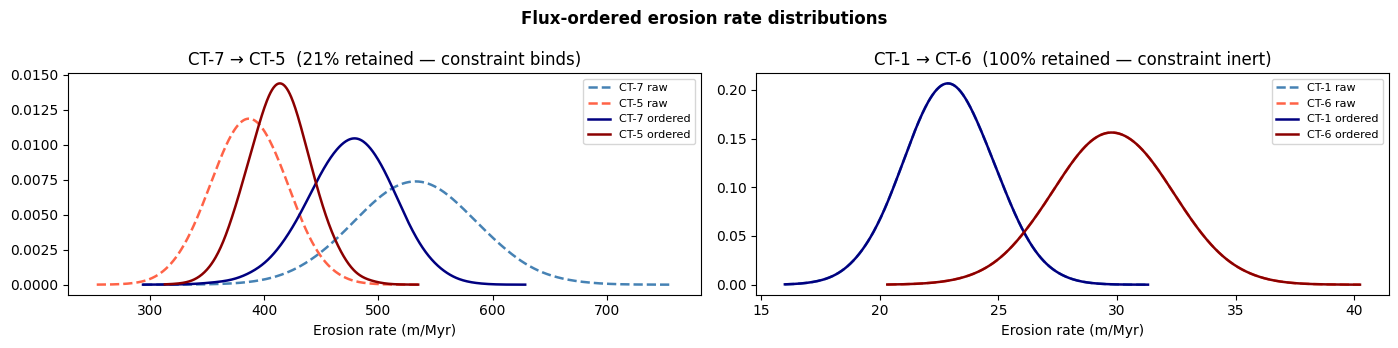

In [7]:
def kde_plot(ax, arrays, labels, colors, styles, title,
             xlabel='Erosion rate (m/Myr)'):
    """Overlay KDE curves for several 1-D sample arrays on one axis."""
    for arr, lbl, col, ls in zip(arrays, labels, colors, styles):
        kde = gaussian_kde(arr, bw_method=0.3)          # smooth density estimate
        x = np.linspace(arr.min(), arr.max(), 500)      # eval grid over the array's range
        ax.plot(x, kde(x), label=lbl, color=col, linewidth=1.8, linestyle=ls)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

# ── Panel 1: the two binding-candidate pairs ────────────────────────────────
# Dashed = raw MC, solid = flux-ordered. Left binds (only 21% retained),
# right is inert (100% retained) — the ordered curves sit on the raw ones.
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
fig.suptitle('Flux-ordered erosion rate distributions', fontsize=12, fontweight='bold')

kde_plot(axes[0],
         [ER['CT-7'], ER['CT-5'], fo['CT7_ord'], fo['CT5_ord']],   # raw pair, then ordered pair
         ['CT-7 raw', 'CT-5 raw', 'CT-7 ordered', 'CT-5 ordered'],
         ['steelblue', 'tomato', 'navy', 'darkred'],
         ['--', '--', '-', '-'],
         'CT-7 → CT-5  (21% retained — constraint binds)')

kde_plot(axes[1],
         [ER['CT-1'], ER['CT-6'], fo['CT1_ord'], fo['CT6_ord']],
         ['CT-1 raw', 'CT-6 raw', 'CT-1 ordered', 'CT-6 ordered'],
         ['steelblue', 'tomato', 'navy', 'darkred'],
         ['--', '--', '-', '-'],
         'CT-1 → CT-6  (100% retained — constraint inert)')

plt.tight_layout()
savefig(fig, 'erosion_rates_ordered_pairs')   # writes PDF only if SAVE_FIGS is True
plt.show()

  saved erosion_rates_child_ordering.pdf


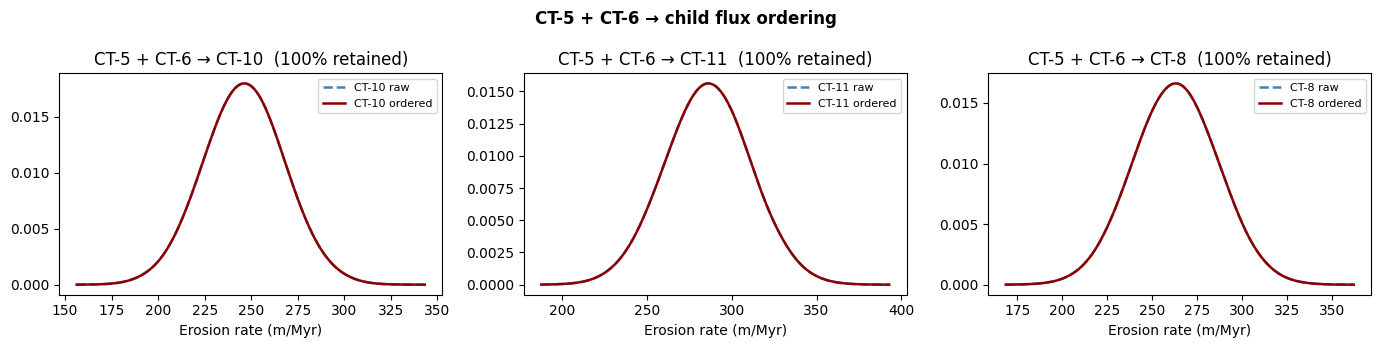

In [8]:
# ── Panel 2: CT-5 + CT-6 -> child ordering ──────────────────────────────────
# All three retain ~100%, so the ordered curve sits on top of the raw one. That
# is the point: the constraint is inert for these children, and showing it is
# more honest than omitting the panel.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
fig.suptitle('CT-5 + CT-6 → child flux ordering', fontsize=12, fontweight='bold')

for ax, child in zip(axes, ['CT-10', 'CT-11', 'CT-8']):
    _, _, child_ord = fo['triples'][child]
    kde_plot(ax,
             [ER[child], child_ord],
             [f'{child} raw', f'{child} ordered'],
             ['steelblue', 'darkred'],
             ['--', '-'],
             f"CT-5 + CT-6 → {child}  "
             f"({100*fo['retained'][f'CT-5 + CT-6 -> {child}']:.0f}% retained)")

plt.tight_layout()
savefig(fig, 'erosion_rates_child_ordering')
plt.show()

---

## 6. The equations

### Quartz

From the flux-weighted nuclide mass balance (manuscript Eq. 5), assuming steady
state, negligible decay, and constant attenuation length and rock density:

$$\frac{Q_A}{Q_B} \;=\; \frac{A_B\,\bigl(P_B E_C - P_C E_B\bigr)}{A_A\,\bigl(P_C E_A - P_A E_C\bigr)}$$

The **quartz flux ratio** follows by multiplying by the sediment flux ratio. The
areas cancel exactly:

$$\frac{F_{QA}}{F_{QB}} \;=\; \frac{Q_A E_A A_A}{Q_B E_B A_B} \;=\; \frac{E_A\,\bigl(P_B E_C - P_C E_B\bigr)}{E_B\,\bigl(P_C E_A - P_A E_C\bigr)}$$

Neither expression contains $A_C$: the child area cancels out of the mass balance.

### Zircon

From the zircon mass balance (manuscript Eq. 11):

$$\frac{Z_A}{Z_B} \;=\; \frac{w_{z1}}{w_{z2}}\cdot\frac{E_B A_B}{E_A A_A}$$

and, because the mixing coefficient *is* the fraction of the child's zircon supplied
by each parent, the **zircon flux ratio** is simply

$$\frac{F_{ZA}}{F_{ZB}} \;=\; \frac{Z_A E_A A_A}{Z_B E_B A_B} \;=\; \frac{w_{z1}}{w_{z2}}$$

with no erosion rates and no areas involved at all.

### Why both flux ratios are robust to the area approximation

The two **fertility** ratios carry the source areas and therefore inherit the
$A_C \simeq A_A + A_B$ approximation quantified in Section 2. The two **flux**
ratios do not: the areas cancel in the quartz case, and never enter in the zircon
case. The sediment-routing result is therefore insensitive to the area
approximation, even though the fertility result is not.

### Sign flips

Write the quartz ratios in terms of two shared kernels:

$$\text{num}_k = P_B E_C - P_C E_B \qquad\qquad \text{den}_k = P_C E_A - P_A E_C$$

$$\frac{Q_A}{Q_B} = \frac{A_B\,\text{num}_k}{A_A\,\text{den}_k} \qquad\qquad \frac{F_{QA}}{F_{QB}} = \frac{E_A\,\text{num}_k}{E_B\,\text{den}_k}$$

**Either kernel can straddle zero** within the Monte Carlo cloud, and which one
does *differs by scenario*. A draw for which either kernel changes sign gives a
negative (unphysical) ratio and is masked out. Because $Q$ and $F$ share both
kernels and differ only by the strictly positive factor $(E_AA_A)/(E_BA_B)$, they
always share a sign — one mask serves both.

For **CT-4** it is the **numerator** that nearly vanishes, because
$E_{CT\text{-}4} \approx E_{CT\text{-}6}$ *and* $P_{CT\text{-}4} \approx P_{CT\text{-}6}$:
the child is nearly indistinguishable from parent B in both erosion rate and
production rate. The ¹⁰Be data cannot constrain even the **sign** of the quartz
fertility contrast for CT-4. This is why CT-4 is excluded from the reported quartz
results. It is still computed below, so the failure is visible rather than hidden.

For **CT-10 / CT-11 / CT-8.2** it is the **denominator** that comes closest to
zero, which is what produces their long right tails.

In [9]:
print(f"THRESHOLD (mixing coefficient filter) = {THRESHOLD}")
print()
print("Sign-flip diagnostic — how close does each kernel come to zero?")
print("Distance is reported in units of the kernel's own Monte Carlo standard")
print("deviation, so a value near zero means the pole sits inside the cloud.\n")

print(f"{'scenario':<22} {'num_k mean':>11} {'sigma':>7} | "
      f"{'den_k mean':>11} {'sigma':>7} | {'retained':>9}")
print('-' * 78)

# Evaluated directly from the flux-ordered triples, so this cell is self-contained
# and can be run before the scenario registry (Section 7) exists.
for key in ['ct4', 'ct10', 'ct11', 'ct82']:
    child_er = {'ct4': 'CT-4', 'ct10': 'CT-10', 'ct11': 'CT-11', 'ct82': 'CT-8'}[key]
    E_a, E_b, E_c = fo['triples'][child_er]

    num_k = P['CT-6'] * E_c - P[child_er] * E_b
    den_k = P[child_er] * E_a - P['CT-5'] * E_c
    Q = (A['CT-6'] * num_k) / (A['CT-5'] * den_k)
    retained = 100 * (Q > 0).mean()

    print(f"CT-5/CT-6 → {child_er:<10} "
          f"{num_k.mean():>11.1f} {abs(num_k.mean()/num_k.std()):>6.2f}s | "
          f"{den_k.mean():>11.1f} {abs(den_k.mean()/den_k.std()):>6.2f}s | "
          f"{retained:>8.1f}%")

print()
print("CT-4: num_k sits ~0.1 sigma from zero — the pole is essentially at the")
print("centre of the Monte Carlo cloud, so roughly half the draws are unphysical.")
print("That is the CT-4 degeneracy, and it is why CT-4 carries no quartz result.")
print("The other three children have a comfortable numerator; their (smaller)")
print("losses come from the denominator instead.")

THRESHOLD (mixing coefficient filter) = 0.01

Sign-flip diagnostic — how close does each kernel come to zero?
Distance is reported in units of the kernel's own Monte Carlo standard
deviation, so a value near zero means the pole sits inside the cloud.

scenario                num_k mean   sigma |  den_k mean   sigma |  retained
------------------------------------------------------------------------------
CT-5/CT-6 → CT-4               7.0   0.14s |      5395.3  13.79s |     55.5%
CT-5/CT-6 → CT-10           3177.5  10.12s |      1563.5   2.83s |     99.8%
CT-5/CT-6 → CT-11           3764.8  10.44s |       802.0   1.36s |     91.3%
CT-5/CT-6 → CT-8            3428.8  10.15s |      1213.6   2.13s |     98.4%

CT-4: num_k sits ~0.1 sigma from zero — the pole is essentially at the
centre of the Monte Carlo cloud, so roughly half the draws are unphysical.
That is the CT-4 degeneracy, and it is why CT-4 carries no quartz result.
The other three children have a comfortable numerator; their (s

---

## 7. Scenario registry


Every scenario is defined in one place: its parents, its child, the workbook it
reads, the source areas, and which erosion-rate arrays it uses.

### The CT-3\* convention

**CT-3\* is not the CT-3 watershed.** CT-3 is a small (189.2 km²) Coastal Cordillera
tributary used as a **lithologic proxy** for the entire portion of the child basin
not covered by the Principal Cordillera parent. The area that proxy stands for is
the residual:

$$A_{CT\text{-}3^*} \;=\; A_{\text{child}} \;-\; A_{\text{parent A}}$$

Two corrections relative to the previous version of this notebook:

| scenario | was | now | why |
|---|---|---|---|
| CT-8.2 & CT-3 → CT-9 | $A_9 - A_8 = 1239.321$ | unchanged | correct |
| CT-8.2 & CT-3 → CT-2 | $A_2 - A_8 + A_3 = 998.938$ | $A_2 - A_8 = 809.733$ | the `+ A₃` term over-tiled the CT-2 basin by exactly $A_3$; CT-3's drainage lies outside the CT-2 polygon and cannot be added to it |
| CT-4 & CT-3 → CT-9 | $A_3 = 189.205$ | $A_9 - A_4 = 1482.999$ | raw CT-3 area is ~7× too small and inconsistent with the CT-8.2 row in the same table |
| CT-10 & CT-3 → CT-9 | $A_3 = 189.205$ | $A_9 - A_{10} = 1324.774$ | as above |
| CT-11 & CT-3 → CT-9 | $A_3 = 189.205$ | $A_9 - A_{11} = 1276.382$ | as above |


In [10]:
# CT-3* = residual area a parent doesn't cover in its child basin (A_child - A_parent).
# CT-3 is used as a lithologic proxy for that residual
A_CT3_9_from_8  = ct3_star_area(A, 'CT-8',  'CT-9')
A_CT3_2_from_8  = ct3_star_area(A, 'CT-8',  'CT-2')
A_CT3_9_from_4  = ct3_star_area(A, 'CT-4',  'CT-9')
A_CT3_9_from_10 = ct3_star_area(A, 'CT-10', 'CT-9')
A_CT3_9_from_11 = ct3_star_area(A, 'CT-11', 'CT-9')
A_CT3_2_from_4  = ct3_star_area(A, 'CT-4',  'CT-2')
A_CT3_2_from_10 = ct3_star_area(A, 'CT-10', 'CT-2')
A_CT3_2_from_11 = ct3_star_area(A, 'CT-11', 'CT-2')

# Print each CT-3* area vs the raw CT-3 watershed; 'factor' shows how much larger
# the residual is (raw CT-3 was the old)
print("CT-3* source areas (km^2):")
print(f"{'parent A':<10} {'child':<8} {'A_CT3*':>10} {'raw A(CT-3)':>12} {'factor':>8}")
print('-' * 52)
for pa, ch, a3 in [('CT-8', 'CT-9', A_CT3_9_from_8),
                   ('CT-8', 'CT-2', A_CT3_2_from_8),
                   ('CT-4', 'CT-9', A_CT3_9_from_4),
                   ('CT-10', 'CT-9', A_CT3_9_from_10),
                   ('CT-11', 'CT-9', A_CT3_9_from_11),
                   ('CT-4', 'CT-2', A_CT3_2_from_4),
                   ('CT-10', 'CT-2', A_CT3_2_from_10),
                   ('CT-11', 'CT-2', A_CT3_2_from_11)]:
    print(f"{pa:<10} {ch:<8} {a3:>10.3f} {A['CT-3']:>12.3f} {a3/A['CT-3']:>7.2f}x")

CT-3* source areas (km^2):
parent A   child        A_CT3*  raw A(CT-3)   factor
----------------------------------------------------
CT-8       CT-9       1239.321      189.205    6.55x
CT-8       CT-2        809.733      189.205    4.28x
CT-4       CT-9       1482.999      189.205    7.84x
CT-10      CT-9       1324.774      189.205    7.00x
CT-11      CT-9       1276.382      189.205    6.75x
CT-4       CT-2       1053.411      189.205    5.57x
CT-10      CT-2        895.186      189.205    4.73x
CT-11      CT-2        846.794      189.205    4.48x


In [11]:
# ── Scenario registry ───────────────────────────────────────────────────────
# Each entry defines everything a scenario needs. `erosion` is a callable so that
# the same registry can be evaluated against the ORDERED arrays (the primary
# analysis) and the RAW arrays (the Section 14 sensitivity test).
#
#   key       : short handle used throughout
#   label     : readable scenario name
#   workbook  : detritalPy-mix results file stem (metric suffix appended at load)
#   child     : sheet name inside the workbook == child sample name
#   A_a, A_b  : source areas (km^2)
#   P_a,P_b,P_c: production rates (atoms/g/yr)
#   quartz    : whether a quartz calculation is defined for this scenario
#   erosion   : fn(ER, fo) -> (E_a, E_b, E_c) index-aligned arrays
#
# Note the sample-ID mismatch: the zircon dataset calls the sample 'CT-8.2', the
# ^10Be spreadsheet calls it 'CT-8'. Same sample.

SCENARIOS = {
    # ── CT-5 (Teno) & CT-6 (Lontue) parents ─────────────────────────────────
    'ct4': dict(
        label='CT-5 & CT-6 to CT-4',
        workbook='dPy-mix_ct-5_ct-6_to_ct-4_ct-10_ct-11_ct-8.2_results',
        child='CT-4',
        A_a=A['CT-5'], A_b=A['CT-6'],
        P_a=P['CT-5'], P_b=P['CT-6'], P_c=P['CT-4'],
        quartz=True,
        erosion=lambda ER, fo: fo['triples']['CT-4'],
        note='EXCLUDED from reported quartz results: ~44% of draws unphysical '
             '(E_CT-4 ~= E_CT-6 and P_CT-4 ~= P_CT-6 -> degenerate).',
    ),
    'ct10': dict(
        label='CT-5 & CT-6 to CT-10',
        workbook='dPy-mix_ct-5_ct-6_to_ct-4_ct-10_ct-11_ct-8.2_results',
        child='CT-10',
        A_a=A['CT-5'], A_b=A['CT-6'],
        P_a=P['CT-5'], P_b=P['CT-6'], P_c=P['CT-10'],
        quartz=True,
        erosion=lambda ER, fo: fo['triples']['CT-10'],
    ),
    'ct11': dict(
        label='CT-5 & CT-6 to CT-11',
        workbook='dPy-mix_ct-5_ct-6_to_ct-4_ct-10_ct-11_ct-8.2_results',
        child='CT-11',
        A_a=A['CT-5'], A_b=A['CT-6'],
        P_a=P['CT-5'], P_b=P['CT-6'], P_c=P['CT-11'],
        quartz=True,
        erosion=lambda ER, fo: fo['triples']['CT-11'],
    ),
    'ct82': dict(
        label='CT-5 & CT-6 to CT-8.2',
        workbook='dPy-mix_ct-5_ct-6_to_ct-4_ct-10_ct-11_ct-8.2_results',
        child='CT-8.2',
        A_a=A['CT-5'], A_b=A['CT-6'],
        P_a=P['CT-5'], P_b=P['CT-6'], P_c=P['CT-8'],
        quartz=True,
        erosion=lambda ER, fo: fo['triples']['CT-8'],
    ),

    # ── CT-8.2 (Principal Cordillera) & CT-3* (Coastal Cordillera) parents ──
    'ct9_83': dict(
        label='CT-8.2 & CT-3* to CT-9',
        workbook='dPy-mix_ct-8.2_ct-3_to_ct-9_results',
        child='CT-9',
        A_a=A['CT-8'], A_b=A_CT3_9_from_8,
        P_a=P['CT-8'], P_b=P['CT-3'], P_c=P['CT-9'],
        quartz=True,
        erosion=lambda ER, fo: (fo['CT8_res'], fo['CT3_res'], ER['CT-9']),
    ),
    'ct9_43': dict(
        label='CT-4 & CT-3* to CT-9',
        workbook='dPy-mix_ct-4_ct-3_to_ct-9_results',
        child='CT-9',
        A_a=A['CT-4'], A_b=A_CT3_9_from_4,
        P_a=P['CT-4'], P_b=P['CT-3'], P_c=P['CT-9'],
        quartz=True,
        erosion=lambda ER, fo: (fo['CT4_res'], fo['CT3_res'], ER['CT-9']),
        # Note: Z_A/Z_B scales as 1/E_A, and CT-4's erosion rate (29.6 m/Myr) is
        # ~8x smaller than the CT-10/CT-11 alternatives (246-286), so this
        # scenario's zircon fertility comes out ~20x higher than every other
        # CT-x/CT-3* scenario. That is CT-4's anomalous 10Be propagating, not a
        # real fertility contrast.
    ),
    'ct9_103': dict(
        label='CT-10 & CT-3* to CT-9',
        workbook='dPy-mix_ct-10_ct-3_to_ct-9_results',
        child='CT-9',
        A_a=A['CT-10'], A_b=A_CT3_9_from_10,
        P_a=P['CT-10'], P_b=P['CT-3'], P_c=P['CT-9'],
        quartz=True,
        erosion=lambda ER, fo: (fo['CT10_res'], fo['CT3_res'], ER['CT-9']),
    ),
    'ct9_113': dict(
        label='CT-11 & CT-3* to CT-9',
        workbook='dPy-mix_ct-11_ct-3_to_ct-9_results',
        child='CT-9',
        A_a=A['CT-11'], A_b=A_CT3_9_from_11,
        P_a=P['CT-11'], P_b=P['CT-3'], P_c=P['CT-9'],
        quartz=True,
        erosion=lambda ER, fo: (fo['CT11_res'], fo['CT3_res'], ER['CT-9']),
    ),
    'ct2_83': dict(
        label='CT-8.2 & CT-3* to CT-2',
        workbook='dPy-mix_ct-8.2_ct-3_to_ct-2_results',
        child='CT-2',
        A_a=A['CT-8'], A_b=A_CT3_2_from_8,
        P_a=P['CT-8'], P_b=P['CT-3'], P_c=P['CT-2'],
        quartz=True,
        erosion=lambda ER, fo: (fo['CT8_res'], fo['CT3_res'], ER['CT-2']),
    ),
    'ct2_43': dict(
        label='CT-4 & CT-3* to CT-2',
        workbook='dPy-mix_ct-4_ct-3_to_ct-2_results',
        child='CT-2',
        A_a=A['CT-4'], A_b=ct3_star_area(A, 'CT-4', 'CT-2'),
        P_a=P['CT-4'], P_b=P['CT-3'], P_c=P['CT-2'],
        quartz=True,
        erosion=lambda ER, fo: (fo['CT4_res'], fo['CT3_res'], ER['CT-2']),
    ),
    'ct2_103': dict(
        label='CT-10 & CT-3* to CT-2',
        workbook='dPy-mix_ct-10_ct-3_to_ct-2_results',
        child='CT-2',
        A_a=A['CT-10'], A_b=ct3_star_area(A, 'CT-10', 'CT-2'),
        P_a=P['CT-10'], P_b=P['CT-3'], P_c=P['CT-2'],
        quartz=True,
        erosion=lambda ER, fo: (fo['CT10_res'], fo['CT3_res'], ER['CT-2']),
    ),
    'ct2_113': dict(
        label='CT-11 & CT-3* to CT-2',
        workbook='dPy-mix_ct-11_ct-3_to_ct-2_results',
        child='CT-2',
        A_a=A['CT-11'], A_b=ct3_star_area(A, 'CT-11', 'CT-2'),
        P_a=P['CT-11'], P_b=P['CT-3'], P_c=P['CT-2'],
        quartz=True,
        erosion=lambda ER, fo: (fo['CT11_res'], fo['CT3_res'], ER['CT-2']),
    ),
    
}

print(f"{len(SCENARIOS)} scenarios registered "
      f"({sum(s['quartz'] for s in SCENARIOS.values())} with quartz).")

12 scenarios registered (12 with quartz).


---

## 8. Load mixing model results — both metrics

Coefficients are read from the detritalPy-mix **results workbook**, not from the
`mix_coeffs_all_*.csv` files.

In [12]:
# results[metric][key] -> dict from load_mixing_results()
results = {m: {} for m in METRICS}

for metric in METRICS:
    for key, s in SCENARIOS.items():
        path = MIXING_RES_DIR / f"{s['workbook']}_{metric}.xlsx"
        results[metric][key] = load_mixing_results(path, s['child'])

# ── Retention + goodness-of-fit summary ─────────────────────────────────────
# Columns:
#   kept/tot    bootstrap iterations surviving the THRESHOLD coefficient filter
#   w_a med     median bootstrap mixing coefficient for parent A
#   best-fit    best-fit objective value on the unperturbed data
#   crit        noise floor (child vs. bootstrapped self)
#   %bw         % of bootstrap best-fit mixtures WORSE than best-fit
#   %rb         % of resampled observations BETTER than the mixture (~50 = the
#               child is indistinguishable from the mixture; ~100 = poor fit)
for metric in METRICS:
    print(f"\n=== metric: {metric} ===")
    print(f"{'key':<9} {'scenario':<22} {'kept':>6} {'/tot':>6} "
          f"{'w_a med':>8} {'best-fit':>9} {'crit':>7} {'%bw':>6} {'%rb':>6}")
    print('-' * 100)
    for key, s in SCENARIOS.items():
        r = results[metric][key]
        print(f"{key:<9} {s['label']:<22} {r['n_kept']:>6} {r['n_total']:>6} "
              f"{np.median(r['wa']):>8.4f} {r['best_fit']:>9.4f} "
              f"{r['crit']:>7.4f} "
              f"{100*r['pct_boot_worse_than_best_fit']:>5.1f} "
              f"{100*r['pct_resampled_better_than_mixture']:>5.1f}")


=== metric: vmax ===
key       scenario                 kept   /tot  w_a med  best-fit    crit    %bw    %rb
----------------------------------------------------------------------------------------------------
ct4       CT-5 & CT-6 to CT-4      9822  10000   0.2634    0.0516  0.1104  10.4  58.9
ct10      CT-5 & CT-6 to CT-10     9997  10000   0.6364    0.1304  0.1232  64.7  93.4
ct11      CT-5 & CT-6 to CT-11     9991  10000   0.4588    0.1288  0.1209  71.5  95.0
ct82      CT-5 & CT-6 to CT-8.2    9992  10000   0.5583    0.1323  0.1216  54.0  90.0
ct9_83    CT-8.2 & CT-3* to CT-9   9983  10000   0.8714    0.1718  0.1200  98.2  99.4
ct9_43    CT-4 & CT-3* to CT-9     8158  10000   0.9333    0.1966  0.1200  99.8  99.9
ct9_103   CT-10 & CT-3* to CT-9    9999  10000   0.8682    0.1542  0.1200  97.3  99.4
ct9_113   CT-11 & CT-3* to CT-9    9998  10000   0.8874    0.1562  0.1200  98.4  99.6
ct2_83    CT-8.2 & CT-3* to CT-2  10000  10000   0.8229    0.1644  0.1235  99.7  99.8
ct2_43    CT-4 

In [13]:
# ── Metric concordance ───────────────────────────────────────────────────────
# Compare the two goodness-of-fit metrics (vmax, r2-kde) per scenario on the
# parent-A mixing coefficient, its CI width, and the zircon flux ratio (w_a/w_b),
# to see whether results depend on the metric chosen.
print(f"{'scenario':<22} | {'w_a: vmax':>9} {'r2kde':>7} {'d':>6} "
      f"| {'CIw: vmax':>9} {'r2kde':>7} | {'FZ: vmax':>9} {'r2kde':>8} {'x':>6} ")
print('-' * 104)
for key, s in SCENARIOS.items():
    rv, rr = results['vmax'][key], results['r2kde'][key]   # results under each metric
    # median mixing coefficient of parent A, each metric
    wav, war = float(np.median(rv['wa'])), float(np.median(rr['wa']))
    # bootstrap 95% CI width of parent A
    civ = float(np.percentile(rv['wa'], 97.5) - np.percentile(rv['wa'], 2.5))
    cir = float(np.percentile(rr['wa'], 97.5) - np.percentile(rr['wa'], 2.5))
    # zircon flux ratio F_ZA/F_ZB = median(w_a / w_b), each metric
    fzv = float(np.median(rv['wa'] / rv['wb']))
    fzr = float(np.median(rr['wa'] / rr['wb']))
    # columns: w_a (both + diff), CI width (both), flux ratio (both + fold-change)
    print(f"{s['label']:<22} | {wav:>9.3f} {war:>7.3f} {war-wav:>+6.3f} "
          f"| {civ:>9.3f} {cir:>7.3f} | {fzv:>9.3f} {fzr:>8.3f} "
          f"{fzr/fzv:>5.2f}x")
print()

# Flag the largest and smallest metric divergence in the flux ratio
divergences = []
for key, s in SCENARIOS.items():
    rv, rr = results['vmax'][key], results['r2kde'][key]
    fzv = float(np.median(rv['wa'] / rv['wb']))
    fzr = float(np.median(rr['wa'] / rr['wb']))
    fold = max(fzr / fzv, fzv / fzr)     # symmetric fold-change (>=1 either direction)
    divergences.append((fold, s['label']))
divergences.sort(reverse=True)
worst_fold, worst_label = divergences[0]
stable_fold = divergences[-1][0]
print(f"  Largest metric divergence in the zircon flux ratio: {worst_label} "
      f"at {worst_fold:.2f}x.")
print(f"  Smallest: {divergences[-1][1]} at {stable_fold:.2f}x.")

scenario               | w_a: vmax   r2kde      d | CIw: vmax   r2kde |  FZ: vmax    r2kde      x 
--------------------------------------------------------------------------------------------------------
CT-5 & CT-6 to CT-4    |     0.263   0.275 +0.012 |     0.371   0.367 |     0.358    0.379  1.06x
CT-5 & CT-6 to CT-10   |     0.636   0.695 +0.058 |     0.495   0.437 |     1.750    2.278  1.30x
CT-5 & CT-6 to CT-11   |     0.459   0.513 +0.054 |     0.541   0.419 |     0.848    1.053  1.24x
CT-5 & CT-6 to CT-8.2  |     0.558   0.627 +0.068 |     0.472   0.428 |     1.264    1.679  1.33x
CT-8.2 & CT-3* to CT-9 |     0.871   0.951 +0.080 |     0.211   0.077 |     6.778   19.475  2.87x
CT-4 & CT-3* to CT-9   |     0.933   0.941 +0.008 |     0.123   0.073 |    13.986   15.946  1.14x
CT-10 & CT-3* to CT-9  |     0.868   0.944 +0.076 |     0.207   0.074 |     6.586   16.842  2.56x
CT-11 & CT-3* to CT-9  |     0.887   0.945 +0.058 |     0.200   0.079 |     7.879   17.307  2.20x
CT-8.2 & CT-

---

## 9. Mixing coefficient violin plots

Bootstrap distributions of the two mixing coefficients, with the deterministic
best-fit overlaid. Best-fit values are read from the workbook — nothing is
hard-coded.


  saved wct_violin_ct4_vmax.pdf


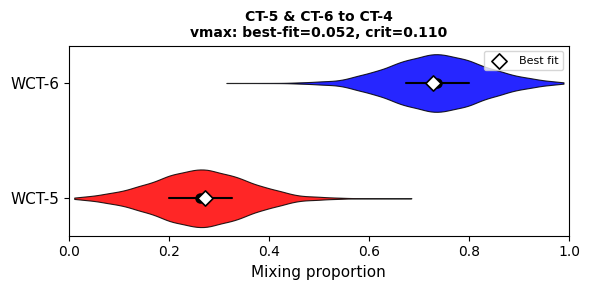

  saved wct_violin_ct10_vmax.pdf


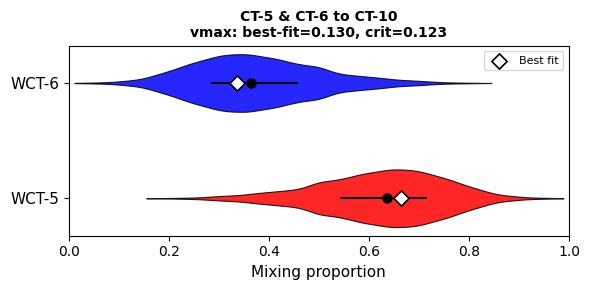

  saved wct_violin_ct11_vmax.pdf


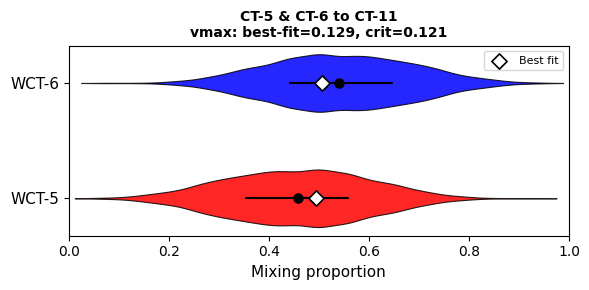

  saved wct_violin_ct82_vmax.pdf


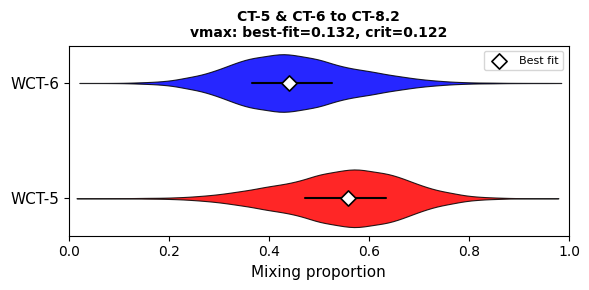

  saved wct_violin_ct9_83_vmax.pdf


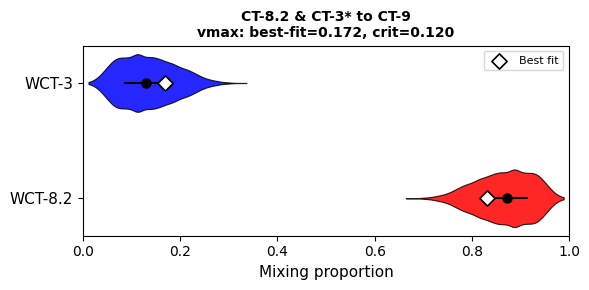

  saved wct_violin_ct9_43_vmax.pdf


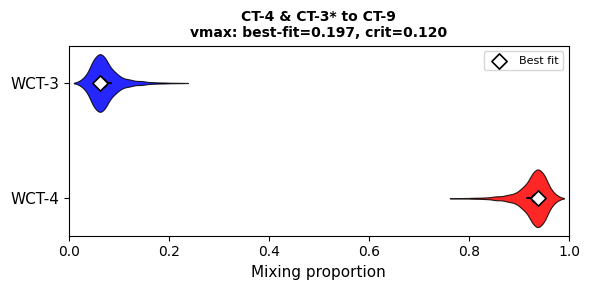

  saved wct_violin_ct9_103_vmax.pdf


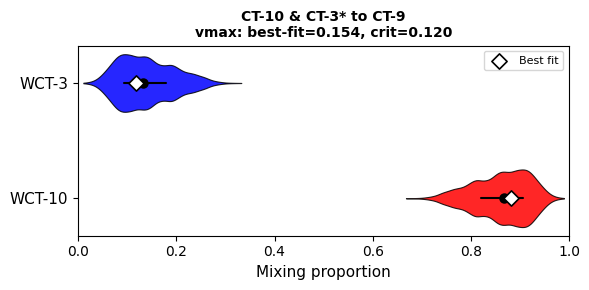

  saved wct_violin_ct9_113_vmax.pdf


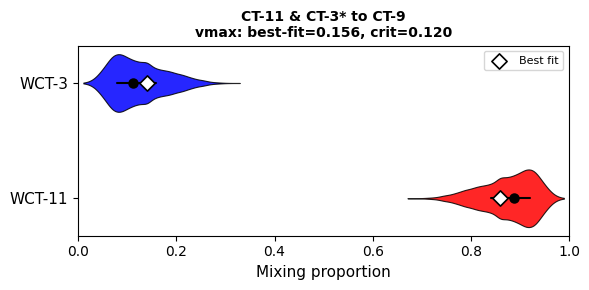

  saved wct_violin_ct2_83_vmax.pdf


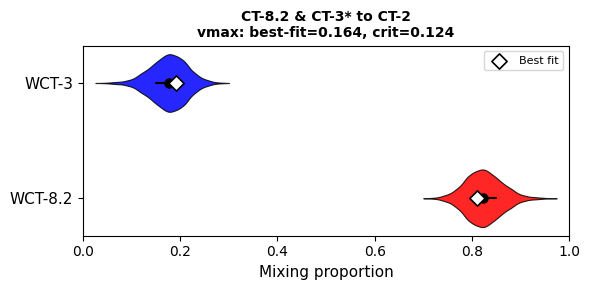

  saved wct_violin_ct2_43_vmax.pdf


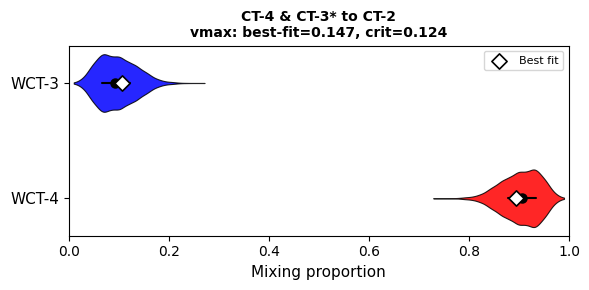

  saved wct_violin_ct2_103_vmax.pdf


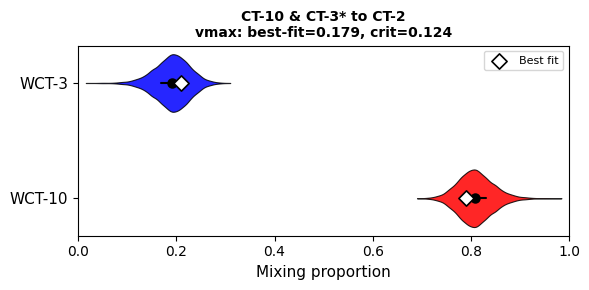

  saved wct_violin_ct2_113_vmax.pdf


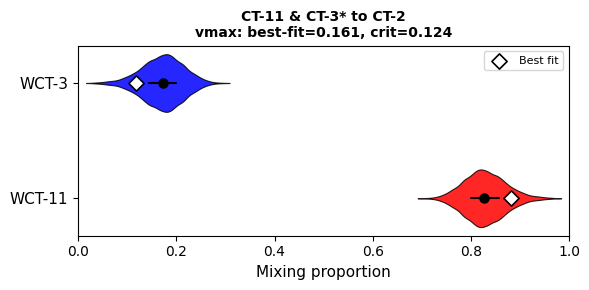

  saved wct_violin_ct4_r2kde.pdf


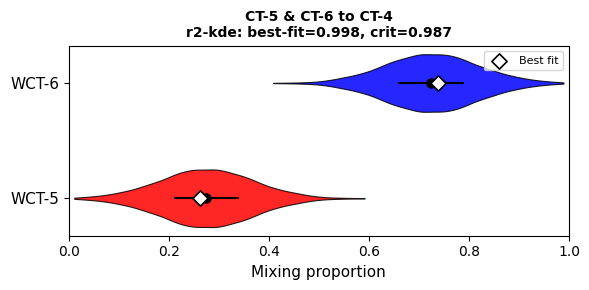

  saved wct_violin_ct10_r2kde.pdf


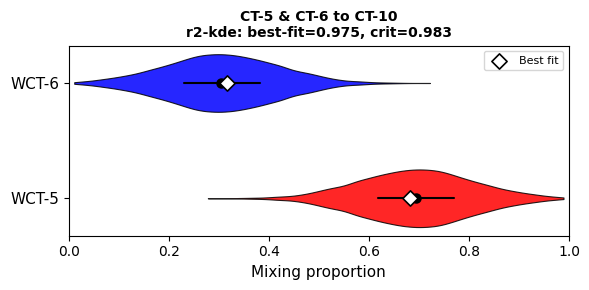

  saved wct_violin_ct11_r2kde.pdf


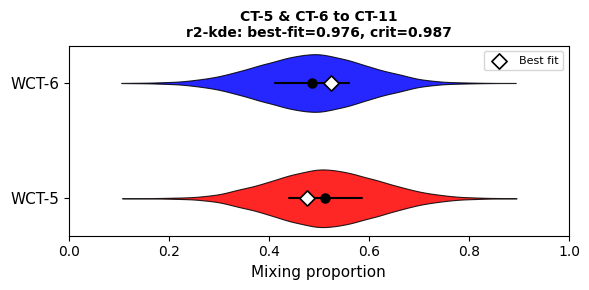

  saved wct_violin_ct82_r2kde.pdf


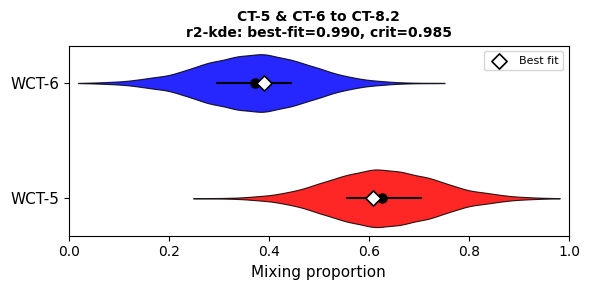

  saved wct_violin_ct9_83_r2kde.pdf


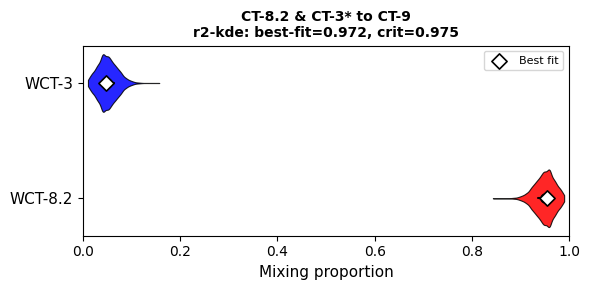

  saved wct_violin_ct9_43_r2kde.pdf


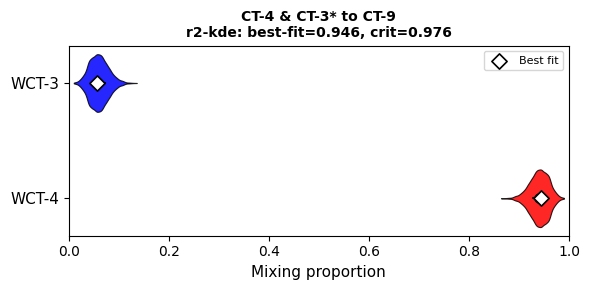

  saved wct_violin_ct9_103_r2kde.pdf


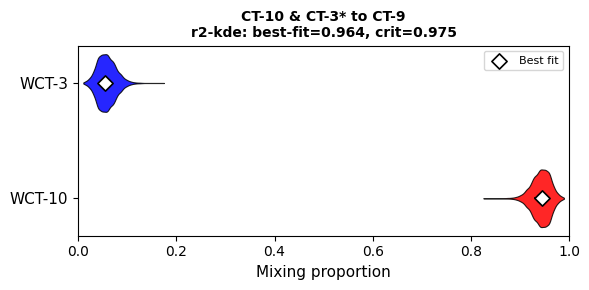

  saved wct_violin_ct9_113_r2kde.pdf


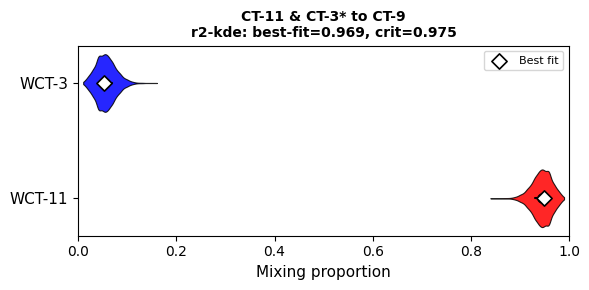

  saved wct_violin_ct2_83_r2kde.pdf


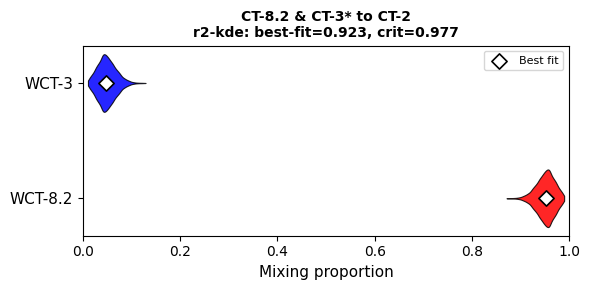

  saved wct_violin_ct2_43_r2kde.pdf


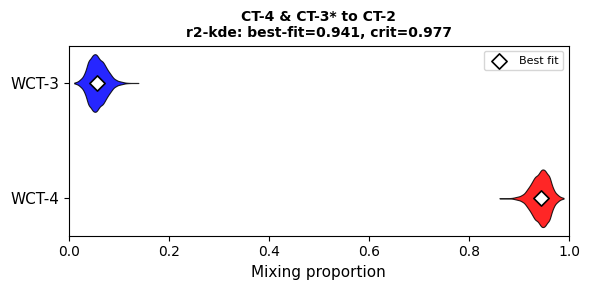

  saved wct_violin_ct2_103_r2kde.pdf


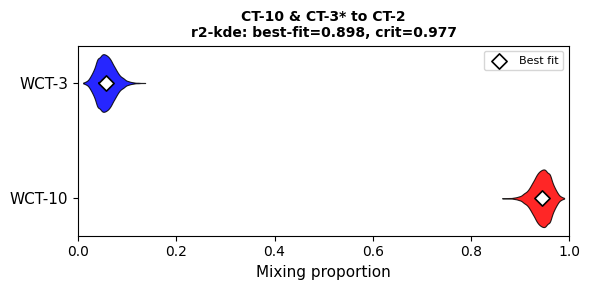

  saved wct_violin_ct2_113_r2kde.pdf


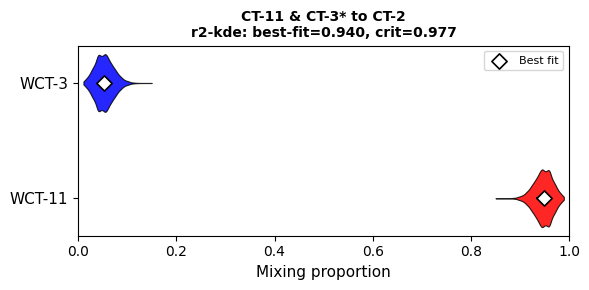

In [14]:
def plot_wct_violin(r, label_a, label_b, title, figsize=(6, 3)):
    """Horizontal violin plot of the two bootstrap mixing coefficients.
    r : dict from load_mixing_results()
    """
    fig, ax = plt.subplots(figsize=figsize)
    data = [r['wa'], r['wb']]           # bootstrap coefficient arrays for A and B
    colors = ['red', 'blue']            # red = parent A, blue = parent B

    # Violin bodies for each coefficient's bootstrap distribution
    parts = ax.violinplot(data, positions=[1, 2], vert=False, widths=0.5,
                          showmeans=False, showextrema=False, showmedians=False)
    for pc, col in zip(parts['bodies'], colors):
        pc.set_facecolor(col); pc.set_edgecolor('black')
        pc.set_linewidth(0.8); pc.set_alpha(0.85)

    # Black IQR bar + median dot on each violin
    for d, pos in zip(data, [1, 2]):
        ax.plot([np.percentile(d, 25), np.percentile(d, 75)], [pos, pos],
                color='black', linewidth=1.5, solid_capstyle='round', zorder=5)
        ax.scatter(np.median(d), pos, color='black', s=40,
                   edgecolor='black', linewidth=1.2, zorder=6)

    # White diamond marks the deterministic best-fit coefficient
    for val, pos in zip([r['best_a'], r['best_b']], [1, 2]):
        ax.scatter(val, pos, color='white', s=60, edgecolor='black',
                   linewidth=1.2, zorder=7, marker='D',
                   label='Best fit' if pos == 1 else '')

    ax.set_xlim(0, 1)                   # coefficients span 0-1
    ax.set_yticks([1, 2]); ax.set_yticklabels([label_a, label_b], fontsize=11)
    ax.set_xlabel('Mixing proportion', fontsize=11)
    # Title carries the metric name and its fit values (best-fit, crit)
    ax.set_title(f"{title}\n{r['metric']}: best-fit={r['best_fit']:.3f}, "
                 f"crit={r['crit']:.3f}",
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    return fig

# One violin figure per scenario per metric
for metric in METRICS:
    for key, s in SCENARIOS.items():
        r = results[metric][key]
        pa, pb = r['parents']                            # parent names for y-axis labels
        fig = plot_wct_violin(r, f'W{pa}', f'W{pb}', s['label'])
        savefig(fig, f'wct_violin_{key}_{metric}')       # PDF only if SAVE_FIGS is True
        plt.show()

---

## 10. Quartz fertility and flux

Computed once per scenario (the quartz calculation depends only on ¹⁰Be and DEM
data, **not** on the zircon mixing coefficients, so it is identical under both
metrics).


In [15]:
# Compute quartz fertility (Q) and flux ratio (F) for every quartz-enabled scenario.
# quartz[key] -> dict with 'Q' (fertility), 'F' (flux ratio), 'n', 'n_total', 'retention'
quartz = {}
for key, s in SCENARIOS.items():
    if not s['quartz']:
        continue
    E_a, E_b, E_c = s['erosion'](ER, fo)     # paired erosion arrays for this scenario
    Q, F, mask = quartz_fertility(
        E_a, E_b, E_c,
        A_a=s['A_a'], A_b=s['A_b'],
        P_a=s['P_a'], P_b=s['P_b'], P_c=s['P_c'],
    )
    # n = physical draws retained; n_total = all draws; retention = fraction kept
    quartz[key] = dict(Q=Q, F=F, n=len(Q), n_total=len(mask),
                       retention=len(Q) / len(mask))

print("QUARTZ — fertility Q_A/Q_B and flux ratio F_QA/F_QB")
print("A = numerator parent, B = denominator parent (see each scenario label).")
print("Each cell: median (25% - 75% IQR). Linear and log10 shown side by side.\n")

hdr = (f"{'scenario':<22} | "
       f"{'Q_A/Q_B linear':>28} {'Q_A/Q_B log10':>28} | "
       f"{'F_QA/F_QB linear':>28} {'F_QA/F_QB log10':>28} | {'ret%':>6}")
print(hdr)
print('-' * len(hdr))
for key, s in SCENARIOS.items():
    if key not in quartz:
        continue
    q = ratio_stats(quartz[key]['Q'])                    # fertility median/IQR
    f = ratio_stats(quartz[key]['F'])                    # flux median/IQR
    flag = '  <-- EXCLUDED' if key == 'ct4' else ''      # CT-4 quartz is degenerate
    print(f"{s['label']:<22} | "
          f"{fmt_lin(q):>28} {fmt_log(q):>28} | "
          f"{fmt_lin(f):>28} {fmt_log(f):>28} | "
          f"{100*quartz[key]['retention']:>5.1f}{flag}")
print()

# Fertility and flux are different quantities; spell out the distinction.
# Example numbers are computed live from the results above, not hardcoded.
flux_factor = np.median(quartz['ct10']['F']) / np.median(quartz['ct10']['Q'])  # sediment-flux ratio for CT-5/CT-6
q_ct9 = np.median(quartz['ct9_83']['Q'])                 # CC vs PC concentration at CT-9
f_ct9 = np.median(quartz['ct9_83']['F'])                 # CC vs PC delivered mass at CT-9
sed_ct9 = f_ct9 / q_ct9                                  # implied sediment-flux ratio at CT-9

print("Read the two ratio families as different statements:")
print("  Q_A/Q_B   = A's rock contains this many times more quartz than B's rock")
print("              (concentration, per unit rock).")
print("  F_QA/F_QB = A delivers this many times more quartz MASS than B does")
print("              (flux = fertility x the sediment-flux ratio (E_A A_A)/(E_B A_B)).")
print(f"They differ by that sediment-flux ratio. For CT-5/CT-6 it is ~{flux_factor:.0f}x, "
      f"so the Teno")
print(f"delivers ~{flux_factor:.0f}x more quartz mass than its fertility contrast alone implies.")
print(f"For CT-8/CT-3 -> CT-9 the fertility says the Coastal Cordillera is ~{1/q_ct9:.0f}x more")
print(f"quartz-rich per unit rock, yet the flux ratio is ~{f_ct9:.1f}: the Principal Cordillera")
print(f"pushes ~{sed_ct9:.0f}x more total sediment, so the two arrive at CT-9 carrying")
print("about equal quartz mass by opposite routes. That cancellation is the result.")

QUARTZ — fertility Q_A/Q_B and flux ratio F_QA/F_QB
A = numerator parent, B = denominator parent (see each scenario label).
Each cell: median (25% - 75% IQR). Linear and log10 shown side by side.

scenario               |               Q_A/Q_B linear                Q_A/Q_B log10 |             F_QA/F_QB linear              F_QA/F_QB log10 |   ret%
-------------------------------------------------------------------------------------------------------------------------------------------------------
CT-5 & CT-6 to CT-4    |     0.0117 (0.0056 - 0.0197)  -1.9333 (-2.2525 - -1.7057) |     0.0972 (0.0457 - 0.1699)  -1.0121 (-1.3400 - -0.7699) |  55.5  <-- EXCLUDED
CT-5 & CT-6 to CT-10   |     3.5001 (2.6788 - 4.8026)     0.5441 (0.4279 - 0.6815) |  28.4722 (22.0469 - 38.3150)     1.4544 (1.3433 - 1.5834) |  99.8
CT-5 & CT-6 to CT-11   |    7.4206 (4.9196 - 12.9897)     0.8704 (0.6919 - 1.1136) | 60.6022 (40.9644 - 104.1283)     1.7825 (1.6124 - 2.0176) |  91.3
CT-5 & CT-6 to CT-8.2  |     4.8

---

## 11. Zircon fertility and flux

Computed **twice** — once per goodness-of-fit metric — because the mixing
coefficients differ between them.


In [16]:
# Compute zircon fertility (Z_A/Z_B) and flux ratio (F_ZA/F_ZB) for every scenario,
# under both goodness-of-fit metrics.
# zircon[metric][key] -> dict from zircon_fertility()
zircon = {m: {} for m in METRICS}
for metric in METRICS:
    for key, s in SCENARIOS.items():
        r = results[metric][key]              # mixing coefficients for this metric
        E_a, E_b, _ = s['erosion'](ER, fo)    # parent erosion arrays; child rate not used
        zircon[metric][key] = zircon_fertility(
            r['wa'], r['wb'],
            ER_A=E_a, ER_B=E_b,
            A_A=s['A_a'], A_B=s['A_b'],
            num_samples=M, seed=SEED,
        )

for metric in METRICS:
    print(f"\n=== ZIRCON fertility Z_A/Z_B and flux F_ZA/F_ZB — metric: {metric} ===")
    print("A = numerator parent, B = denominator parent (see each scenario label).")
    print("Each cell: median (25% - 75% IQR). Linear and log10 side by side.\n")
    hdr = (f"{'scenario':<22} | "
           f"{'Z_A/Z_B linear':>28} {'Z_A/Z_B log10':>28} | "
           f"{'F_ZA/F_ZB linear':>28} {'F_ZA/F_ZB log10':>28}")
    print(hdr)
    print('-' * len(hdr))
    for key, s in SCENARIOS.items():
        z = ratio_stats(zircon[metric][key]['ZA_ZB']['samples'])    # fertility median/IQR
        f = ratio_stats(zircon[metric][key]['FZA_FZB']['samples'])  # flux median/IQR
        print(f"{s['label']:<22} | "
              f"{fmt_lin(z):>28} {fmt_log(z):>28} | "
              f"{fmt_lin(f):>28} {fmt_log(f):>28}")
print()

# Distinguish the flux ratio from the fertility ratio
print("F_ZA/F_ZB is exactly w_a / w_b -- no erosion rates, no areas. It is the")
print("quantity that answers 'how much zircon comes from each parent', and it is")
print("completely independent of the 10Be data and the source-area assumptions.")
print("Z_A/Z_B is the zircon CONCENTRATION contrast = that flux ratio divided by")
print("the sediment-flux ratio (E_A A_A)/(E_B A_B).")
print()


=== ZIRCON fertility Z_A/Z_B and flux F_ZA/F_ZB — metric: vmax ===
A = numerator parent, B = denominator parent (see each scenario label).
Each cell: median (25% - 75% IQR). Linear and log10 side by side.

scenario               |               Z_A/Z_B linear                Z_A/Z_B log10 |             F_ZA/F_ZB linear              F_ZA/F_ZB log10
----------------------------------------------------------------------------------------------------------------------------------------------
CT-5 & CT-6 to CT-4    |     0.0440 (0.0308 - 0.0604)  -1.3570 (-1.5111 - -1.2188) |     0.3572 (0.2508 - 0.4848)  -0.4471 (-0.6006 - -0.3145)
CT-5 & CT-6 to CT-10   |     0.2195 (0.1482 - 0.3147)  -0.6585 (-0.8291 - -0.5021) |     1.7619 (1.2042 - 2.5234)     0.2460 (0.0807 - 0.4020)
CT-5 & CT-6 to CT-11   |     0.1055 (0.0676 - 0.1565)  -0.9767 (-1.1702 - -0.8056) |     0.8490 (0.5497 - 1.2512)   -0.0711 (-0.2599 - 0.0973)
CT-5 & CT-6 to CT-8.2  |     0.1549 (0.1092 - 0.2139)  -0.8100 (-0.9617 - -0.6

---

## 12. Fertility and flux violin plots


In [17]:
def fertility_violin(data_list, labels, title, xlabel,
                     separator_after=None, group_labels=None,
                     figsize=(8, 7), log=True):
    """Horizontal violin plot of ratio distributions, with IQR bar + median dot.
    data_list : list of 1-D arrays (log10 values if log=True, else linear)
    separator_after : draw a horizontal rule after this (1-based) position
    group_labels    : [(text, y_axes_fraction), ...]
    """
    n = len(labels)
    # Sequential blue shading, light to dark, one shade per violin
    cmap = plt.cm.Blues
    colors = [cmap(0.4 + 0.5 * i / max(n - 1, 1)) for i in range(n)]

    fig, ax = plt.subplots(figsize=figsize)
    parts = ax.violinplot(data_list, positions=range(1, n + 1), vert=False,
                          widths=0.7, showmeans=False, showextrema=False,
                          showmedians=False)
    for pc, col in zip(parts['bodies'], colors):
        pc.set_facecolor(col); pc.set_edgecolor('black')
        pc.set_linewidth(0.8); pc.set_alpha(0.85)

    # Black IQR bar + white median dot on each violin
    for d, pos in zip(data_list, range(1, n + 1)):
        ax.plot([np.percentile(d, 25), np.percentile(d, 75)], [pos, pos],
                color='black', linewidth=1.5, solid_capstyle='round', zorder=5)
        ax.scatter(np.median(d), pos, color='white', s=40,
                   edgecolor='black', linewidth=1.2, zorder=6)

    # Dashed reference line at ratio = 1 (log10 = 0, or linear = 1)
    ax.axvline(0 if log else 1, color='gray', linestyle='--',
               linewidth=0.8, alpha=0.7)

    # Optional horizontal rule separating parent-pair groups
    if separator_after:
        ax.axhline(separator_after + 0.5, color='black', linewidth=1.0)
    # Optional group labels placed at axes-fraction y positions
    if group_labels:
        for txt, y in group_labels:
            ax.text(0.02, y, txt, transform=ax.transAxes, fontsize=10, va='center')

    ax.set_yticks(range(1, n + 1)); ax.set_yticklabels(labels, fontsize=11)
    ax.set_ylim(0.3, n + 0.7)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', labelsize=10)
    plt.tight_layout()
    return fig, ax

# Plot order: CT-4 at top, CT-8.2/CT-3* group at bottom, separated by a rule.
# Order is reversed vs reading order because matplotlib's y-axis counts upward.
PLOT_ORDER   = ['ct2_83', 'ct9_83', 'ct82', 'ct11', 'ct10', 'ct4']
PLOT_LABELS  = ['CT-2', 'CT-9', 'CT-8.2', 'CT-11', 'CT-10', 'CT-4']
SEPARATOR    = 2                                              # rule after 2nd position (the CT-3* group)
GROUP_LABELS = [('Parents: CT-8.2 & CT-3*', 0.14), ('Parents: CT-5 & CT-6', 0.62)]

  saved violin_quartz_fertility_log10.pdf


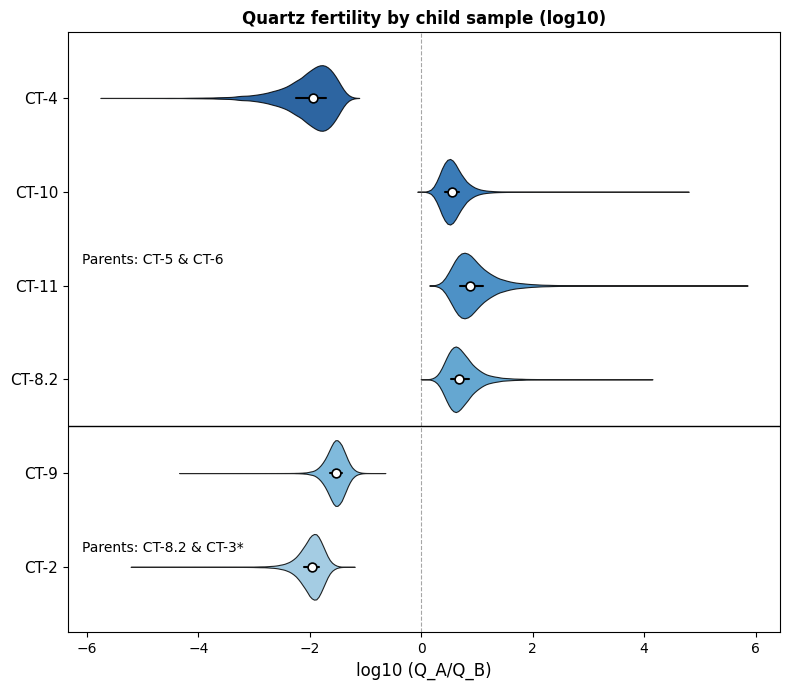

  saved violin_quartz_flux_log10.pdf


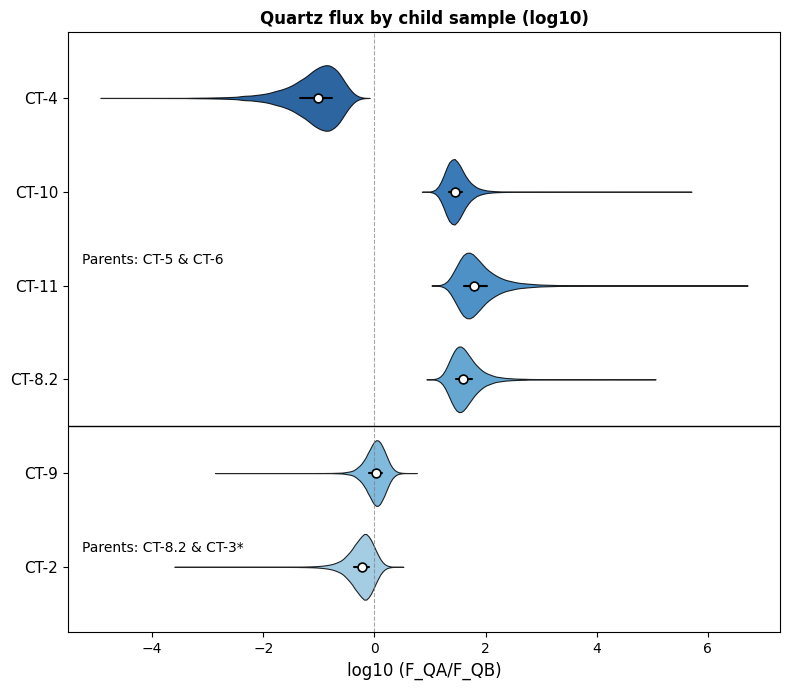

In [18]:
# ── Quartz: fertility and flux, log10 ───────────────────────────────────────
# CT-4 is plotted for completeness but its quartz result is degenerate (see the
# retention column in the quartz table); it is shown, not relied on.
for quantity, arr_key, sym in [('fertility', 'Q', 'Q_A/Q_B'),
                               ('flux',      'F', 'F_QA/F_QB')]:
    data = [np.log10(quartz[k][arr_key]) for k in PLOT_ORDER]   # log10 of each scenario's array
    fig, ax = fertility_violin(
        data, PLOT_LABELS,
        title=f'Quartz {quantity} by child sample (log10)',
        xlabel=f'log10 ({sym})',
        separator_after=SEPARATOR, group_labels=GROUP_LABELS)
    savefig(fig, f'violin_quartz_{quantity}_log10')           # PDF only if SAVE_FIGS is True
    plt.show()

  saved violin_ct9_parents_quartz_fertility.pdf


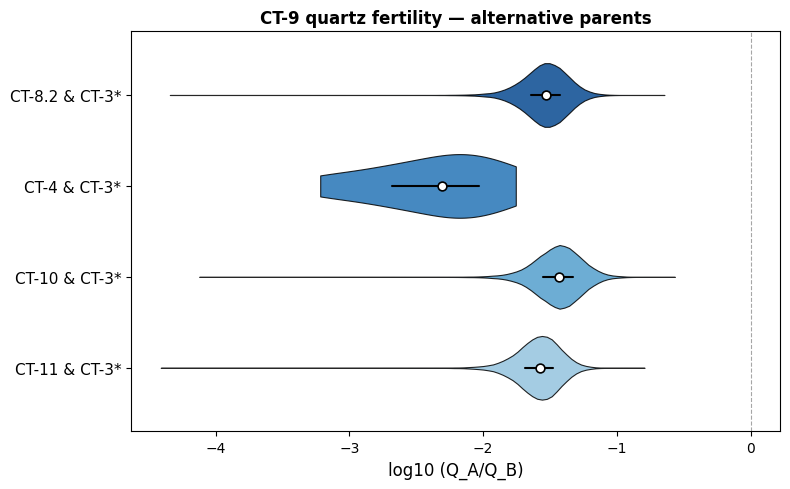

  saved violin_ct9_parents_quartz_flux.pdf


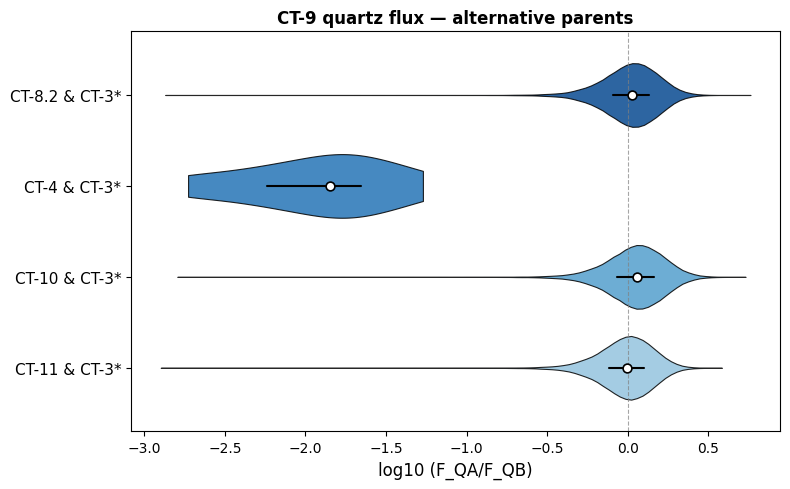

  saved violin_ct2_parents_quartz_fertility.pdf


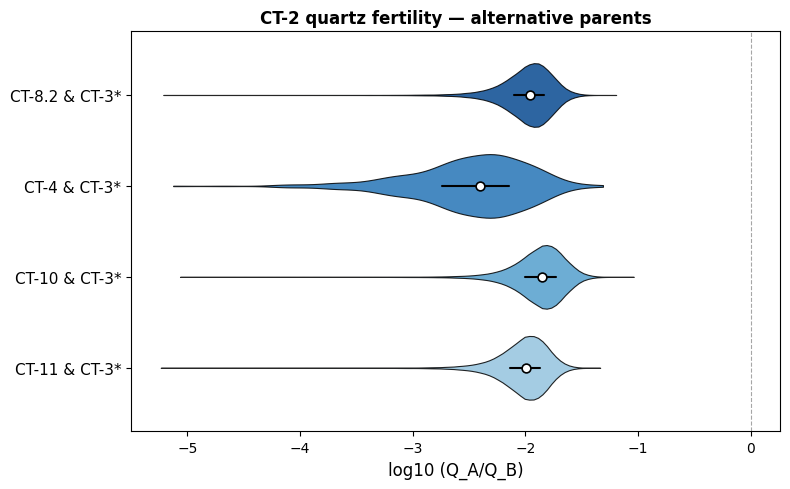

  saved violin_ct2_parents_quartz_flux.pdf


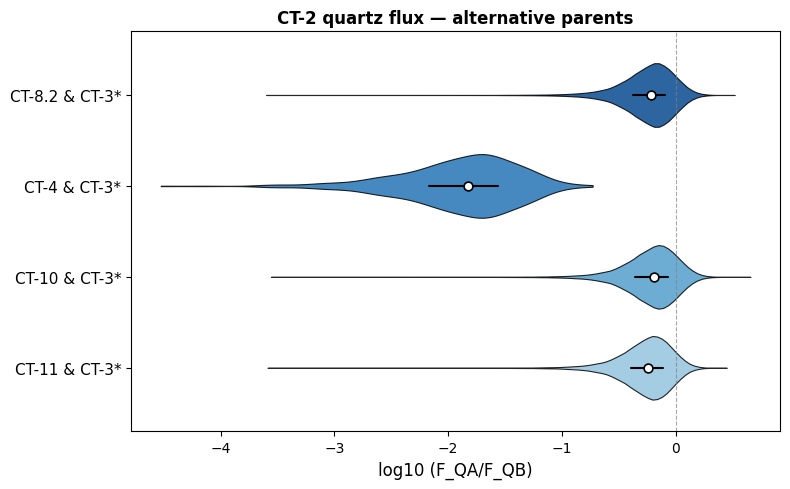

In [19]:
# ── Exploratory alternative-parent scenarios: quartz ────────────────────────
# Quartz fertility and flux for each child under alternative Principal Cordillera
# parents, all sharing the CT-3* residual-area convention.
EXPL_SETS = {
    'CT-9': (['ct9_113', 'ct9_103', 'ct9_43', 'ct9_83'],
             ['CT-11 & CT-3*', 'CT-10 & CT-3*', 'CT-4 & CT-3*', 'CT-8.2 & CT-3*']),
    'CT-2': (['ct2_113', 'ct2_103', 'ct2_43', 'ct2_83'],
             ['CT-11 & CT-3*', 'CT-10 & CT-3*', 'CT-4 & CT-3*', 'CT-8.2 & CT-3*']),
}

for child, (order, labels) in EXPL_SETS.items():
    child_slug = child.replace('-', '').lower()                      # 'CT-9' -> 'ct9'
    for quantity, arr_key, sym in [('fertility', 'Q', 'Q_A/Q_B'),
                                   ('flux',      'F', 'F_QA/F_QB')]:
        data = [np.log10(quartz[k][arr_key]) for k in order]        # log10 of each scenario's array
        fig, ax = fertility_violin(
            data, labels,
            title=f'{child} quartz {quantity} — alternative parents',
            xlabel=f'log10 ({sym})', figsize=(8, 5))
        savefig(fig, f'violin_{child_slug}_parents_quartz_{quantity}')  # PDF only if SAVE_FIGS
        plt.show()

  saved violin_zircon_fertility_log10_vmax.pdf


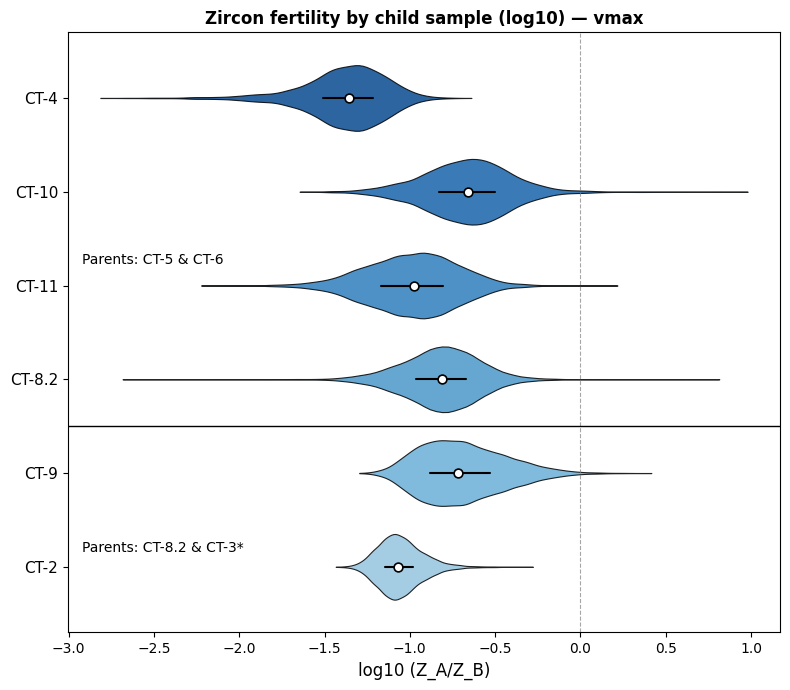

  saved violin_zircon_flux_log10_vmax.pdf


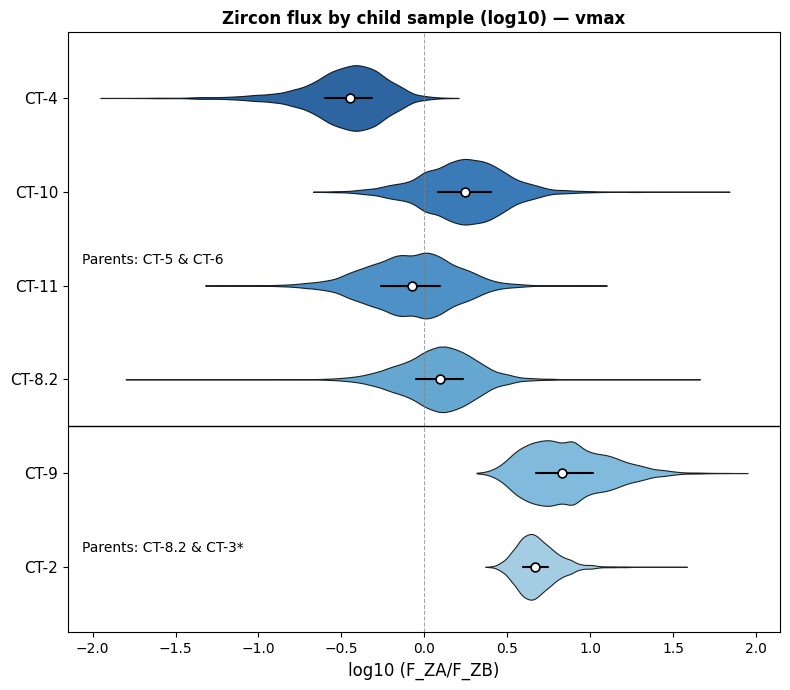

  saved violin_zircon_fertility_log10_r2kde.pdf


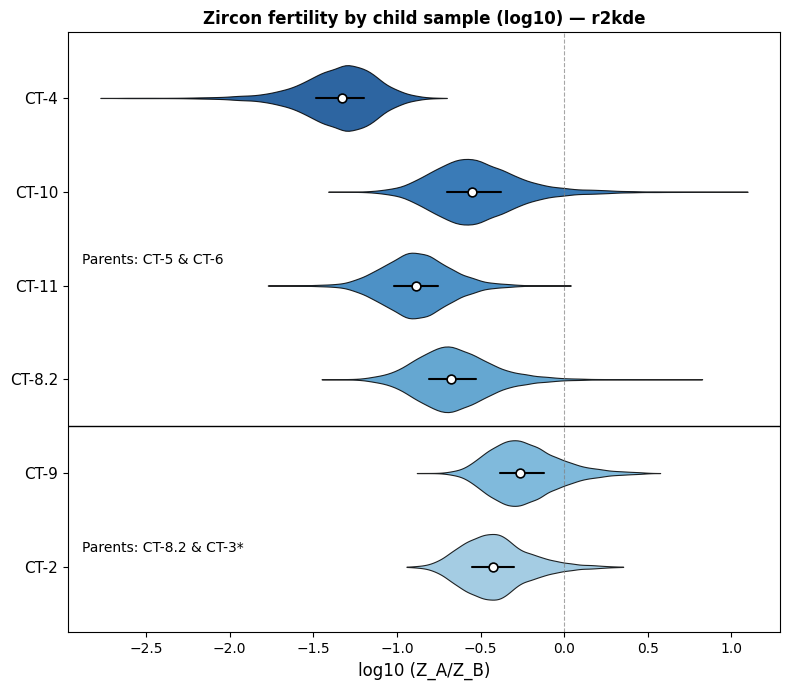

  saved violin_zircon_flux_log10_r2kde.pdf


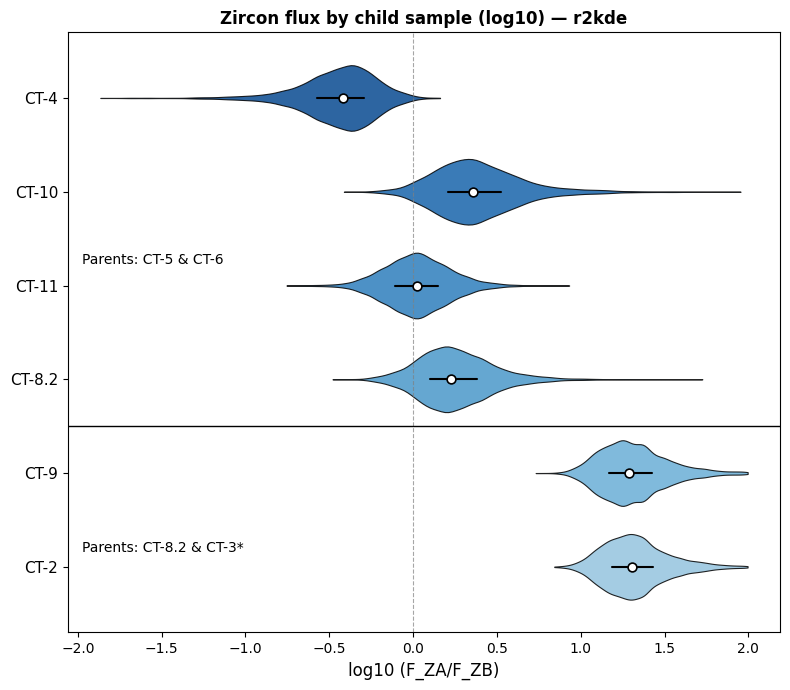

In [20]:
# ── Zircon: fertility and flux, log10, one figure per metric ────────────────
for metric in METRICS:
    for quantity, res_key, sym in [('fertility', 'ZA_ZB',   'Z_A/Z_B'),
                                   ('flux',      'FZA_FZB', 'F_ZA/F_ZB')]:
        data = [zircon[metric][k][res_key]['log10_samples'] for k in PLOT_ORDER]
        fig, ax = fertility_violin(
            data, PLOT_LABELS,
            title=f'Zircon {quantity} by child sample (log10) — {metric}',
            xlabel=f'log10 ({sym})',
            separator_after=SEPARATOR, group_labels=GROUP_LABELS)
        savefig(fig, f'violin_zircon_{quantity}_log10_{metric}')   # PDF only if SAVE_FIGS
        plt.show()

  saved violin_ct9_parents_zircon_fertility_vmax.pdf


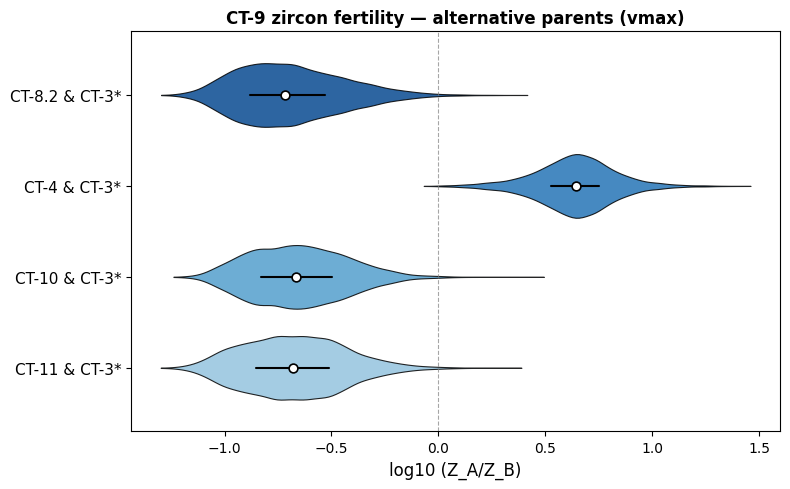

  saved violin_ct9_parents_zircon_flux_vmax.pdf


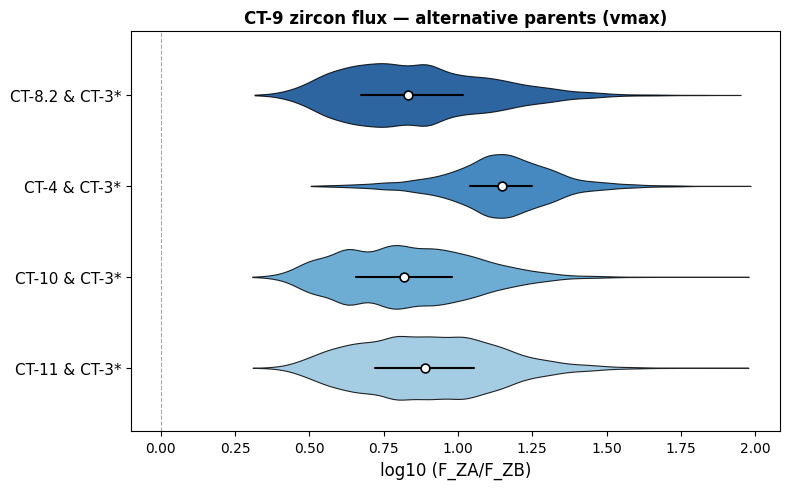

  saved violin_ct9_parents_zircon_fertility_r2kde.pdf


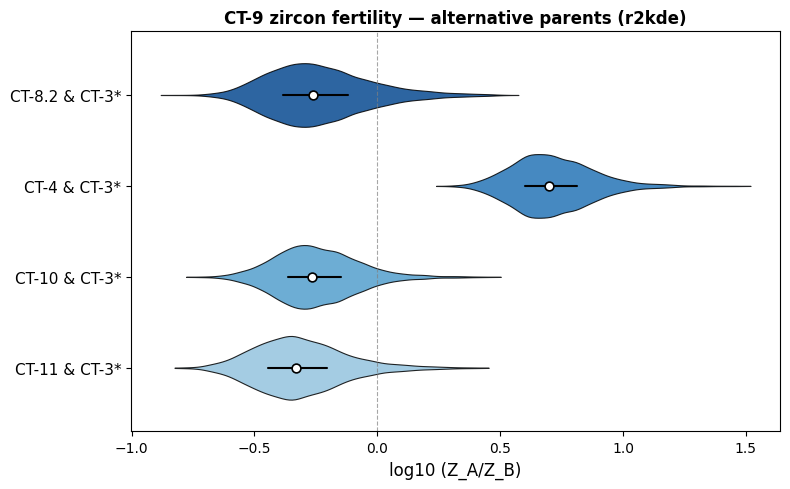

  saved violin_ct9_parents_zircon_flux_r2kde.pdf


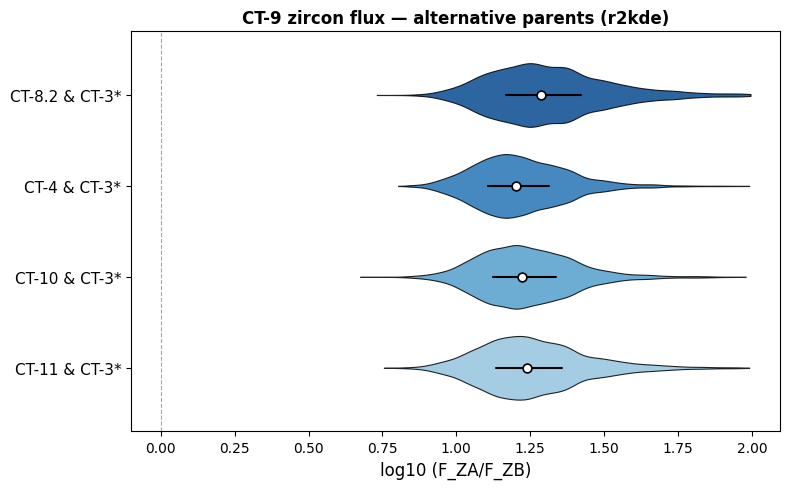

  saved violin_ct2_parents_zircon_fertility_vmax.pdf


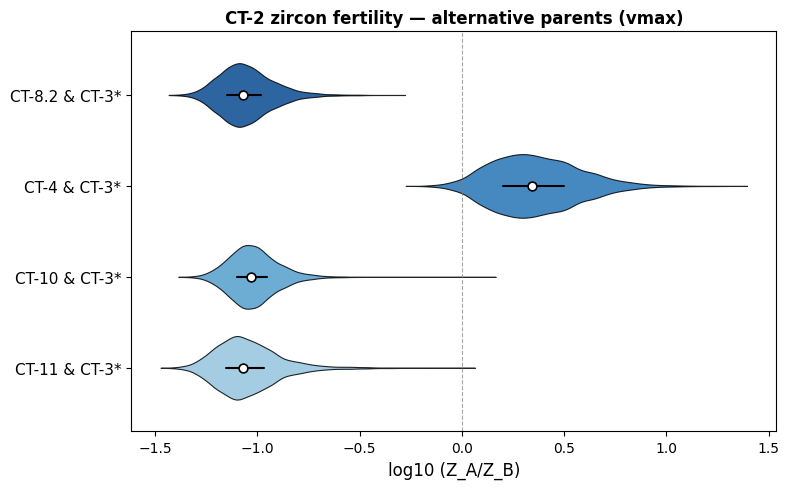

  saved violin_ct2_parents_zircon_flux_vmax.pdf


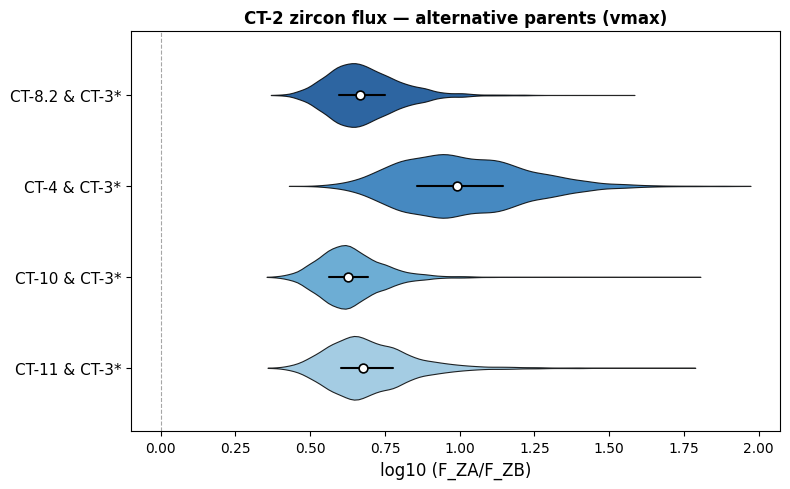

  saved violin_ct2_parents_zircon_fertility_r2kde.pdf


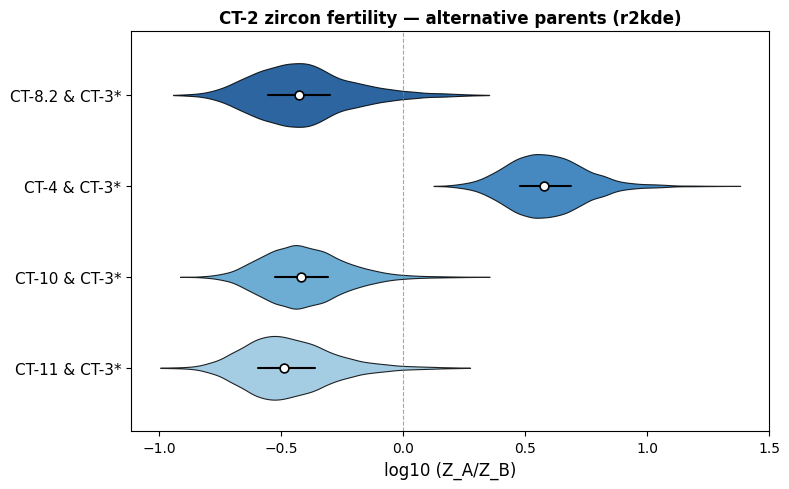

  saved violin_ct2_parents_zircon_flux_r2kde.pdf


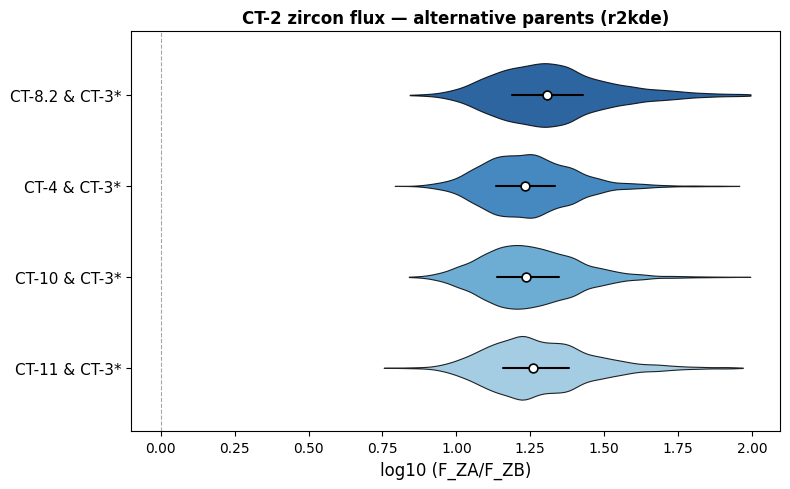

In [21]:
# ── Exploratory alternative-parent scenarios: zircon ────────────────────────
# Zircon fertility and flux for each child under alternative Principal Cordillera
# parents, all sharing the CT-3* residual-area convention. EXPL_SETS is defined
# in the quartz exploratory cell above.
for child, (order, labels) in EXPL_SETS.items():
    child_slug = child.replace('-', '').lower()                       # 'CT-9' -> 'ct9'
    for metric in METRICS:
        for quantity, res_key, sym in [('fertility', 'ZA_ZB',   'Z_A/Z_B'),
                                       ('flux',      'FZA_FZB', 'F_ZA/F_ZB')]:
            data = [zircon[metric][k][res_key]['log10_samples'] for k in order]
            fig, ax = fertility_violin(
                data, labels,
                title=f'{child} zircon {quantity} — alternative parents ({metric})',
                xlabel=f'log10 ({sym})', figsize=(8, 5))
            savefig(fig, f'violin_{child_slug}_parents_zircon_{quantity}_{metric}')  # PDF only if SAVE_FIGS
            plt.show()

---
## 13. Distribution plots

One histogram per scenario per quantity. Linear axes are clipped at the 99th
percentile for display only; the reported medians and IQRs are computed on the
unclipped samples and are unaffected.

  saved dist_quartz_fertility_linear_ct4.pdf


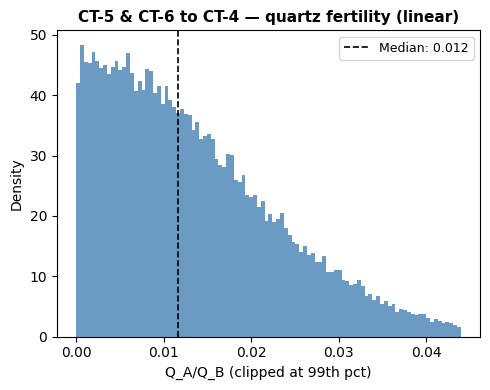

  saved dist_quartz_fertility_log10_ct4.pdf


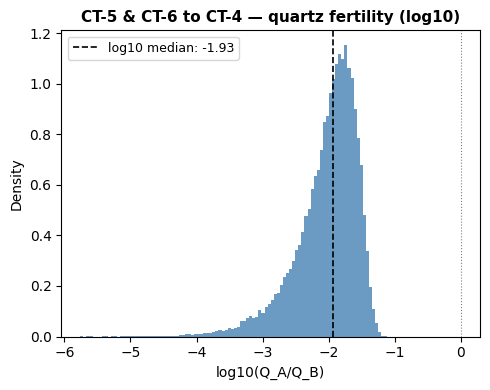

  saved dist_quartz_flux_linear_ct4.pdf


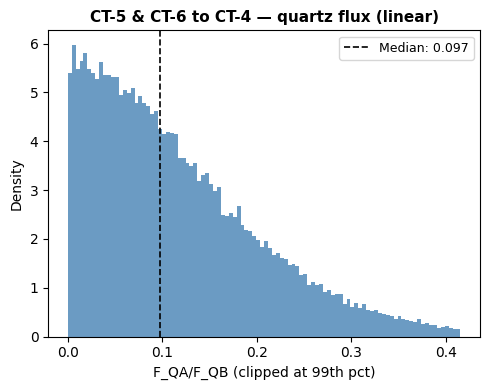

  saved dist_quartz_flux_log10_ct4.pdf


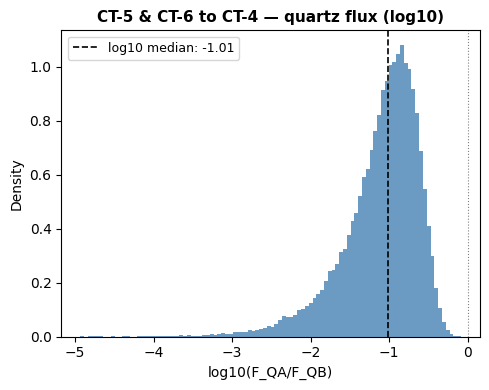

  saved dist_quartz_fertility_linear_ct10.pdf


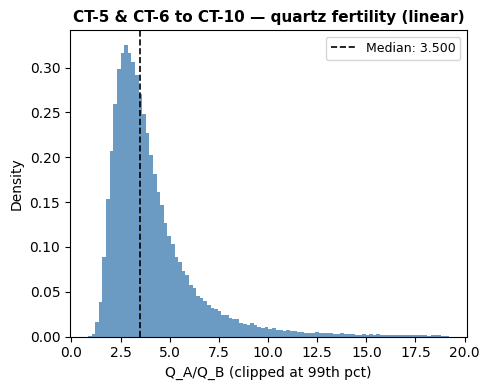

  saved dist_quartz_fertility_log10_ct10.pdf


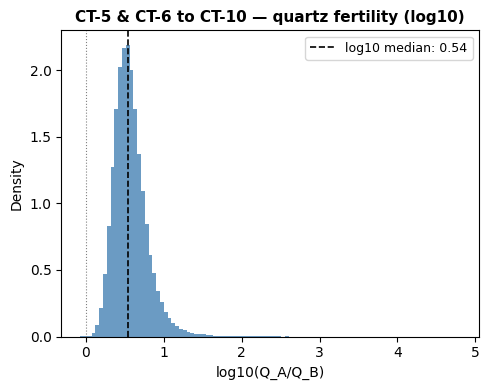

  saved dist_quartz_flux_linear_ct10.pdf


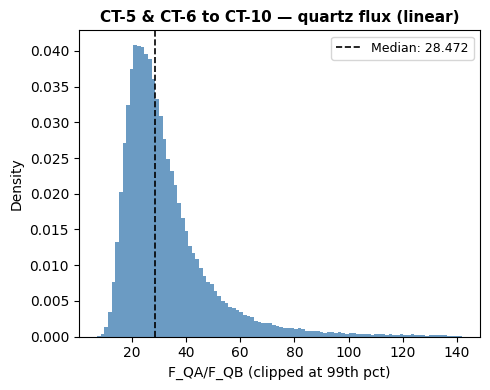

  saved dist_quartz_flux_log10_ct10.pdf


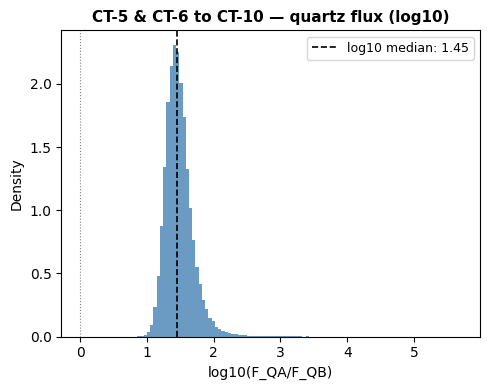

  saved dist_quartz_fertility_linear_ct11.pdf


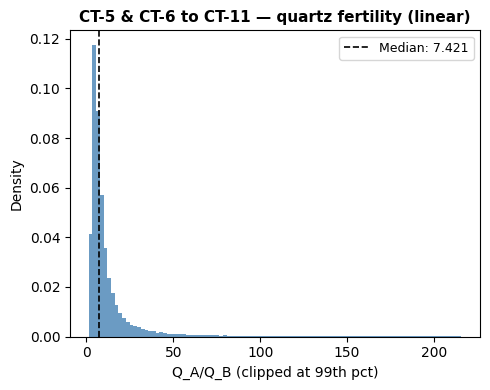

  saved dist_quartz_fertility_log10_ct11.pdf


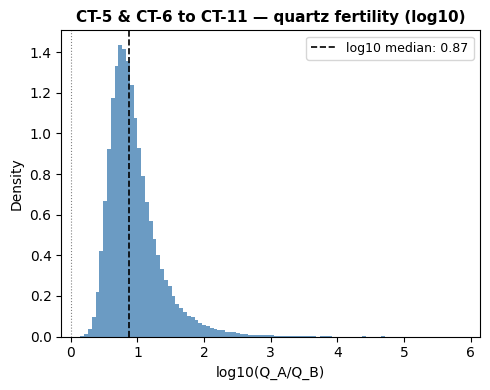

  saved dist_quartz_flux_linear_ct11.pdf


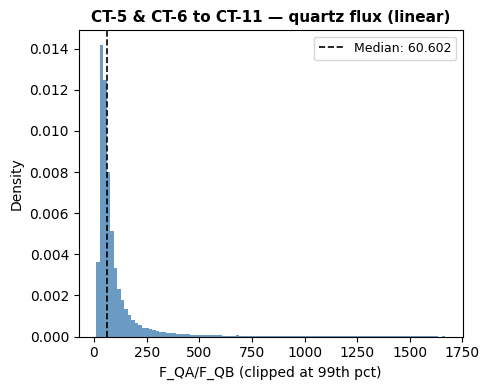

  saved dist_quartz_flux_log10_ct11.pdf


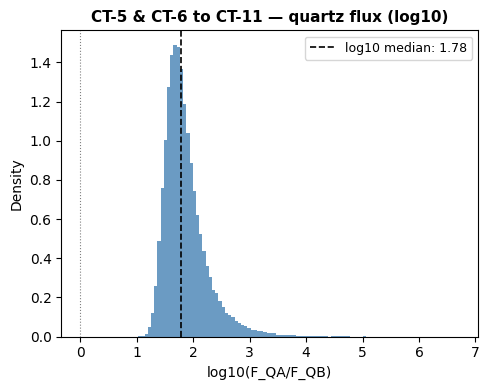

  saved dist_quartz_fertility_linear_ct82.pdf


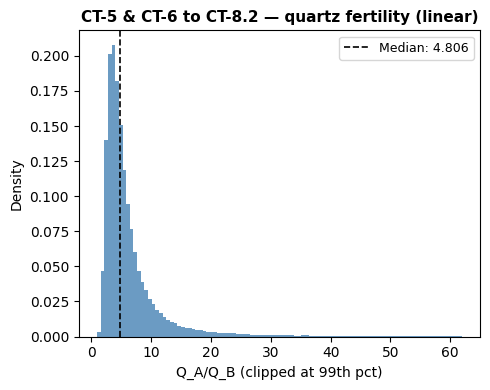

  saved dist_quartz_fertility_log10_ct82.pdf


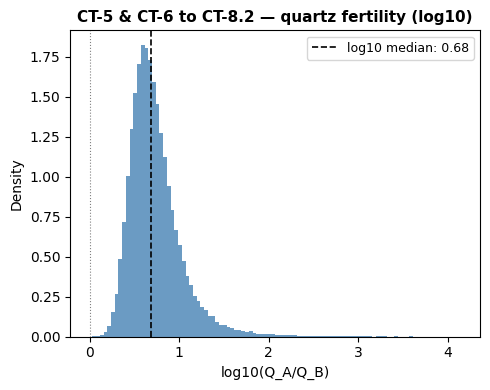

  saved dist_quartz_flux_linear_ct82.pdf


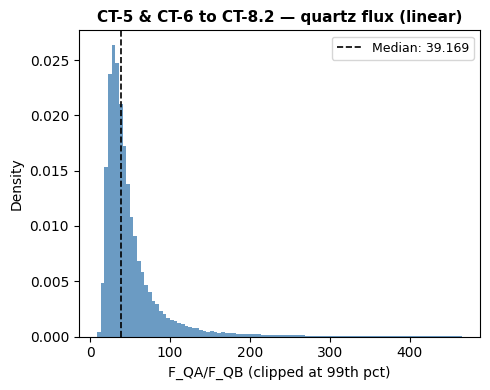

  saved dist_quartz_flux_log10_ct82.pdf


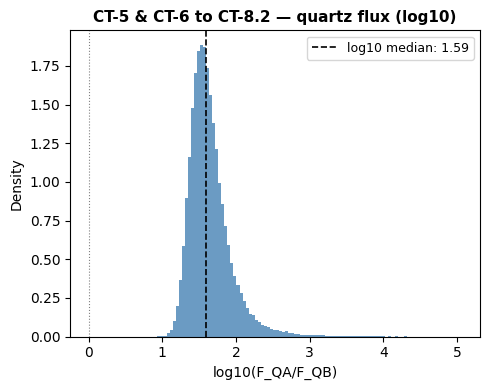

  saved dist_quartz_fertility_linear_ct9_83.pdf


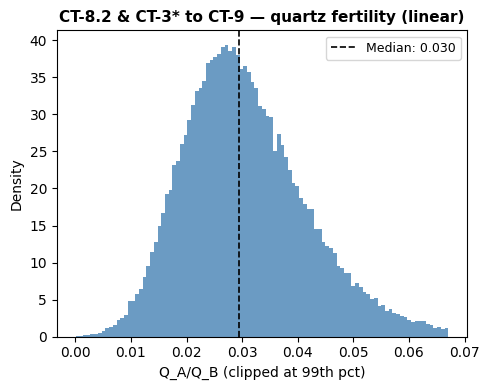

  saved dist_quartz_fertility_log10_ct9_83.pdf


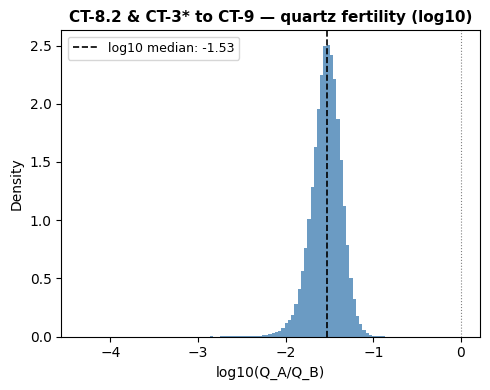

  saved dist_quartz_flux_linear_ct9_83.pdf


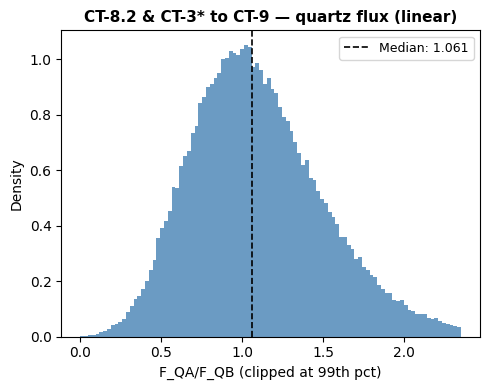

  saved dist_quartz_flux_log10_ct9_83.pdf


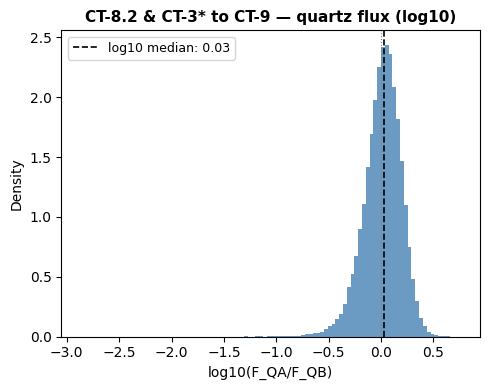

  saved dist_quartz_fertility_linear_ct9_43.pdf


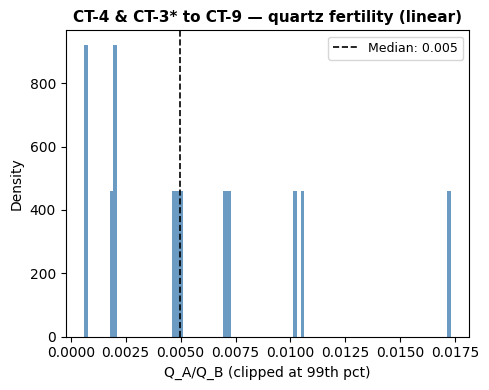

  saved dist_quartz_fertility_log10_ct9_43.pdf


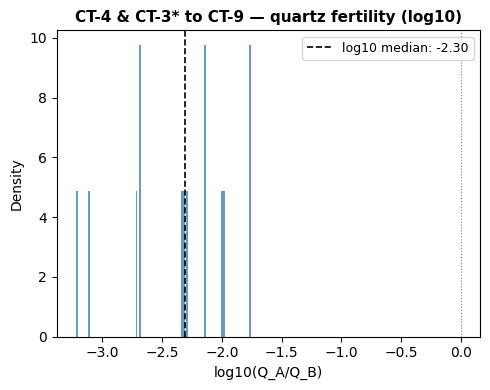

  saved dist_quartz_flux_linear_ct9_43.pdf


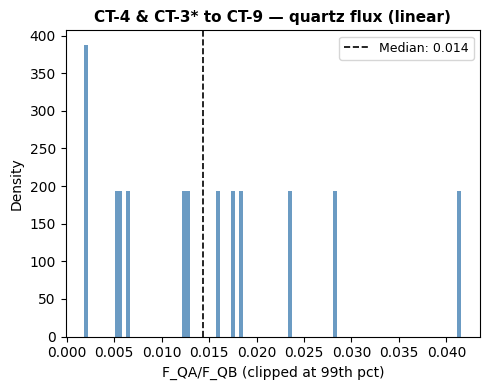

  saved dist_quartz_flux_log10_ct9_43.pdf


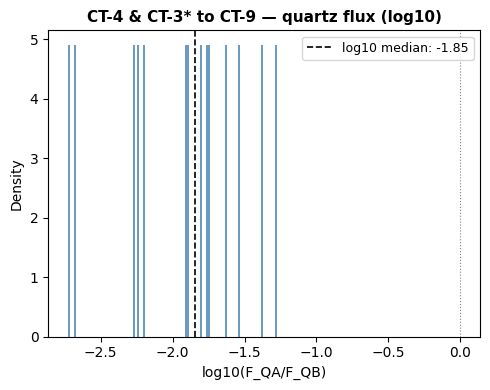

  saved dist_quartz_fertility_linear_ct9_103.pdf


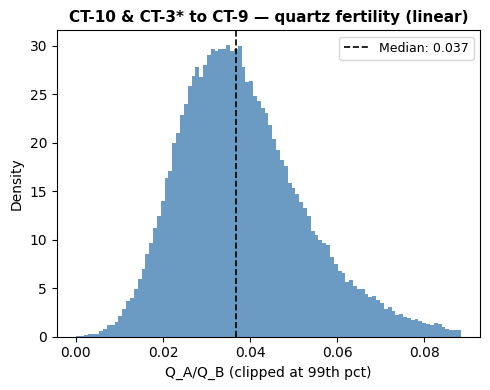

  saved dist_quartz_fertility_log10_ct9_103.pdf


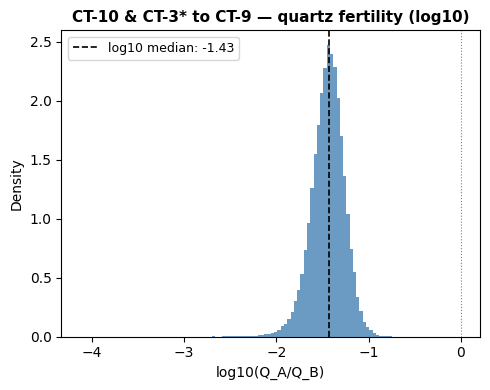

  saved dist_quartz_flux_linear_ct9_103.pdf


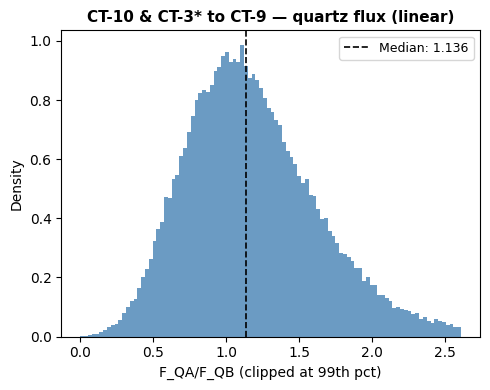

  saved dist_quartz_flux_log10_ct9_103.pdf


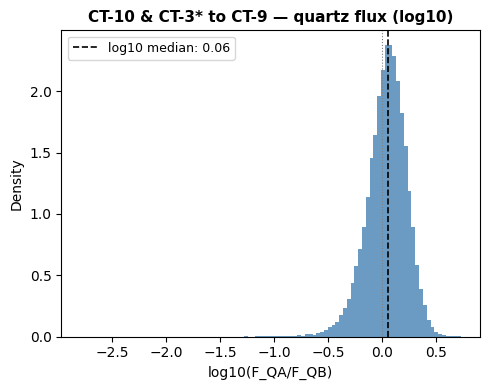

  saved dist_quartz_fertility_linear_ct9_113.pdf


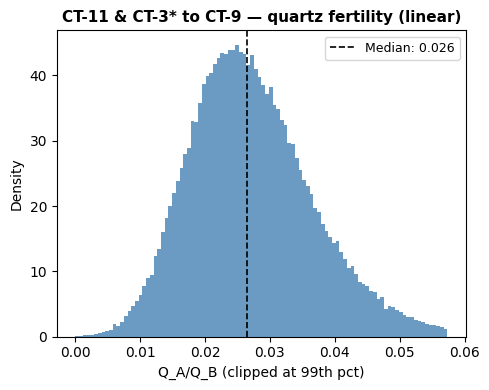

  saved dist_quartz_fertility_log10_ct9_113.pdf


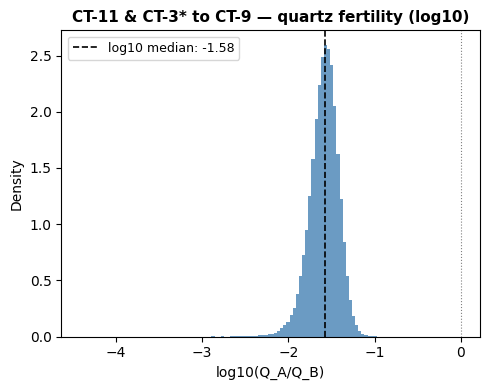

  saved dist_quartz_flux_linear_ct9_113.pdf


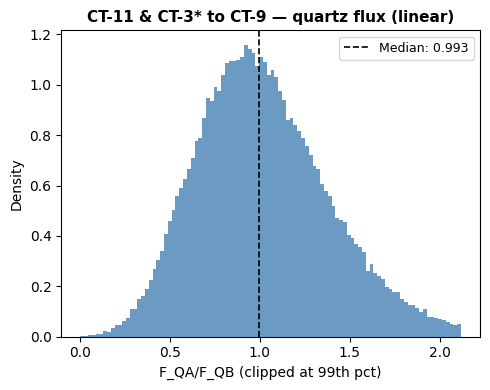

  saved dist_quartz_flux_log10_ct9_113.pdf


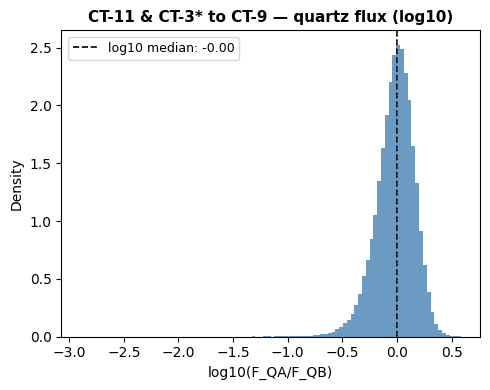

  saved dist_quartz_fertility_linear_ct2_83.pdf


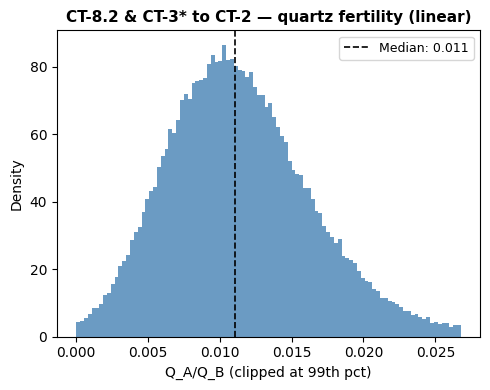

  saved dist_quartz_fertility_log10_ct2_83.pdf


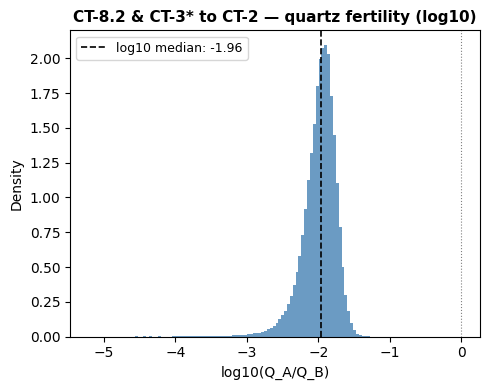

  saved dist_quartz_flux_linear_ct2_83.pdf


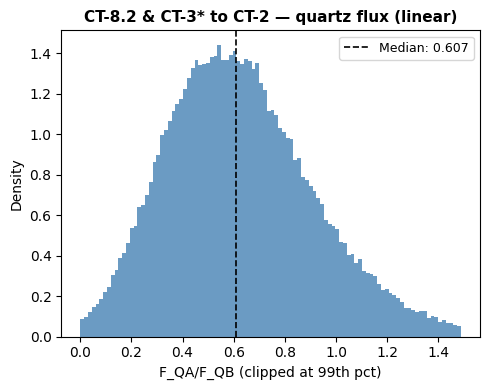

  saved dist_quartz_flux_log10_ct2_83.pdf


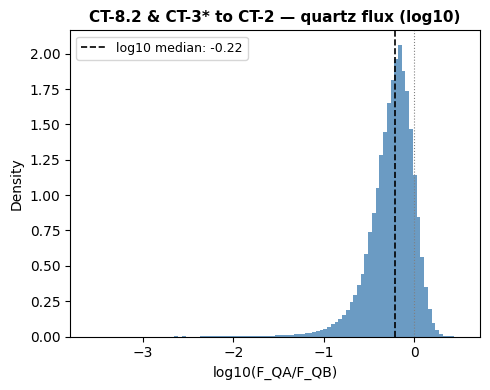

  saved dist_quartz_fertility_linear_ct2_43.pdf


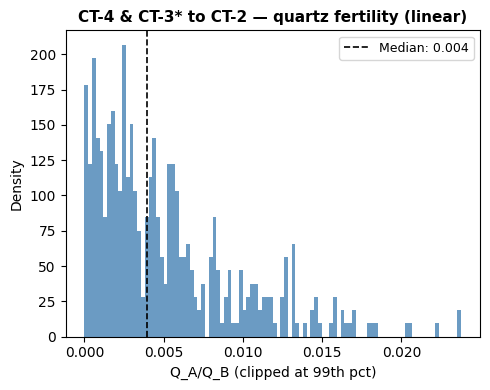

  saved dist_quartz_fertility_log10_ct2_43.pdf


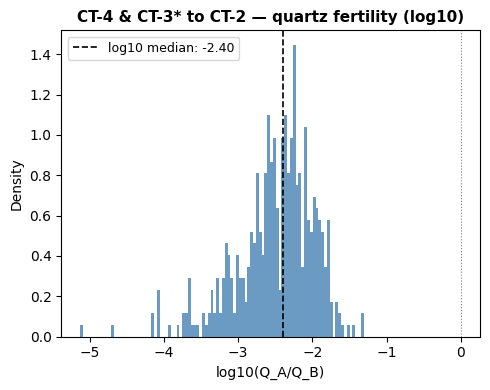

  saved dist_quartz_flux_linear_ct2_43.pdf


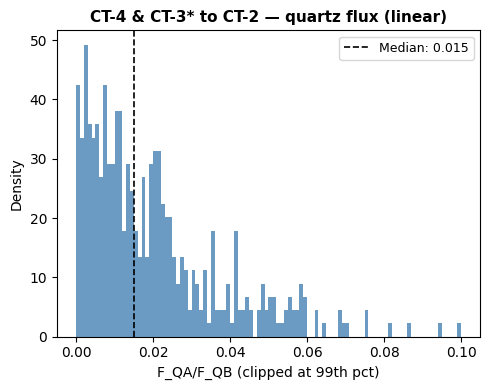

  saved dist_quartz_flux_log10_ct2_43.pdf


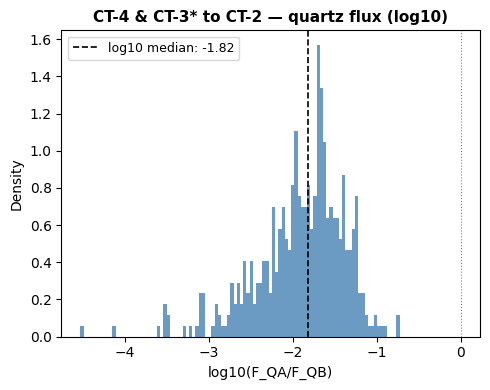

  saved dist_quartz_fertility_linear_ct2_103.pdf


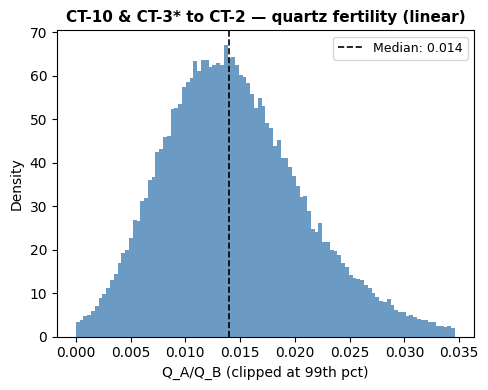

  saved dist_quartz_fertility_log10_ct2_103.pdf


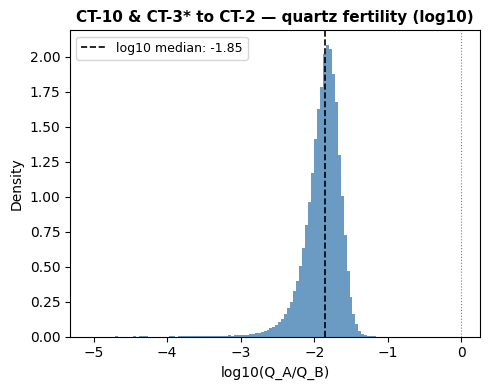

  saved dist_quartz_flux_linear_ct2_103.pdf


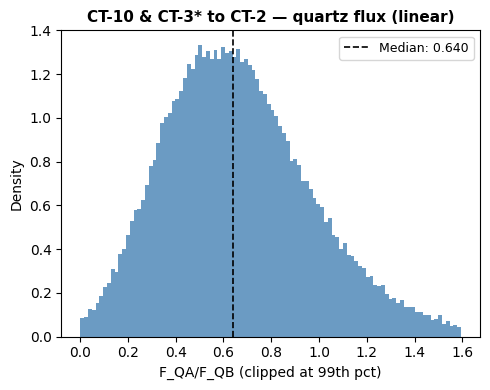

  saved dist_quartz_flux_log10_ct2_103.pdf


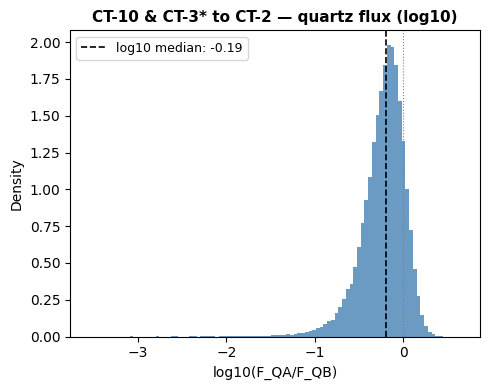

  saved dist_quartz_fertility_linear_ct2_113.pdf


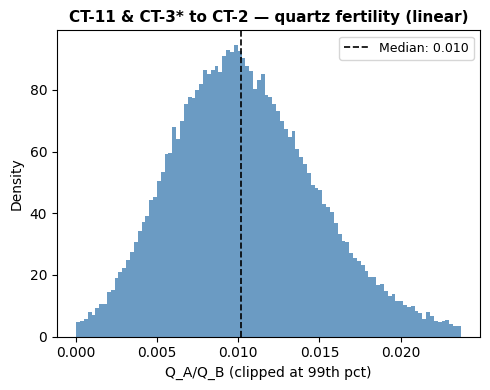

  saved dist_quartz_fertility_log10_ct2_113.pdf


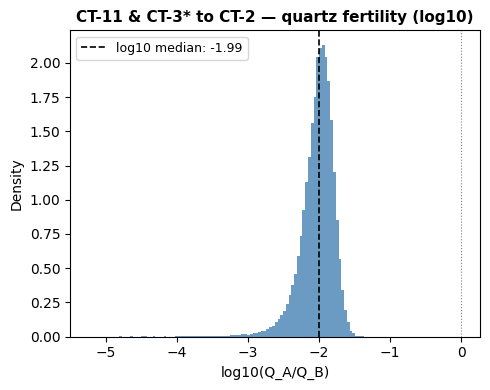

  saved dist_quartz_flux_linear_ct2_113.pdf


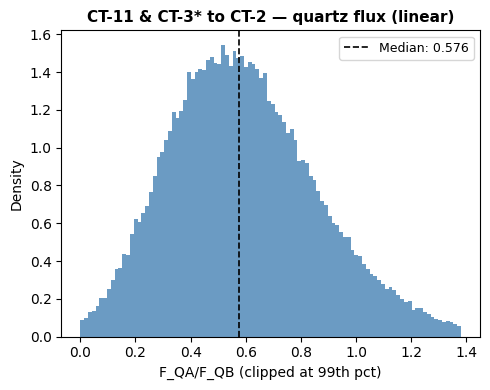

  saved dist_quartz_flux_log10_ct2_113.pdf


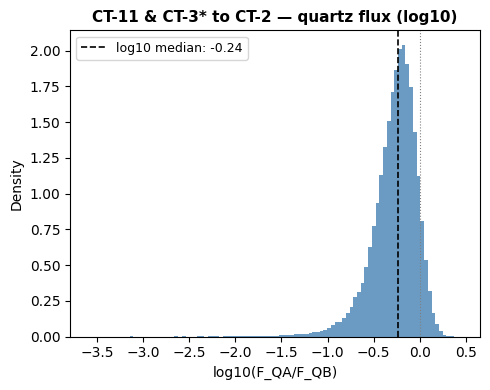

In [22]:
def plot_hist(x, title, xlabel, color, log=False, clip=True):
    """Histogram of a ratio distribution with the median marked."""
    x = np.asarray(x)
    if log:
        d = np.log10(x)             # plot in log10 space
        med = np.median(d)
        lab = f'log10 median: {med:.2f}'
    else:
        # linear: clip display at 99th pct to keep the long tail from squashing
        # the plot, but compute the median on the UNCLIPPED sample
        d = x[x <= np.percentile(x, 99)] if clip else x
        med = np.median(x)
        lab = f'Median: {med:.3f}'
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.hist(d, bins=100, color=color, alpha=0.8, density=True, edgecolor='none')
    ax.axvline(med, color='black', linewidth=1.2, linestyle='--', label=lab)  # median line
    if log:
        ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')             # ratio = 1
    ax.set_xlabel(xlabel); ax.set_ylabel('Density')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    return fig

# ── Quartz distributions ────────────────────────────────────────────────────
# One linear + one log10 histogram per scenario, for both fertility and flux
for key, s in SCENARIOS.items():
    if key not in quartz:
        continue
    q = quartz[key]
    for arr, sym, tag in [(q['Q'], 'Q_A/Q_B', 'fertility'),
                          (q['F'], 'F_QA/F_QB', 'flux')]:
        fig = plot_hist(arr, f"{s['label']} — quartz {tag} (linear)",
                        f'{sym} (clipped at 99th pct)', 'steelblue', log=False)
        savefig(fig, f'dist_quartz_{tag}_linear_{key}')   # PDF only if SAVE_FIGS
        plt.show()
        fig = plot_hist(arr, f"{s['label']} — quartz {tag} (log10)",
                        f'log10({sym})', 'steelblue', log=True)
        savefig(fig, f'dist_quartz_{tag}_log10_{key}')     # PDF only if SAVE_FIGS
        plt.show()

  saved dist_zircon_fertility_linear_ct4_vmax.pdf


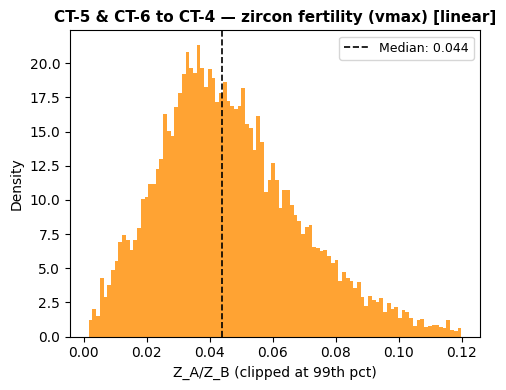

  saved dist_zircon_fertility_log10_ct4_vmax.pdf


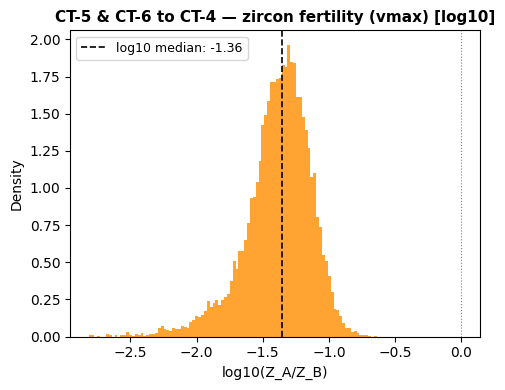

  saved dist_zircon_flux_linear_ct4_vmax.pdf


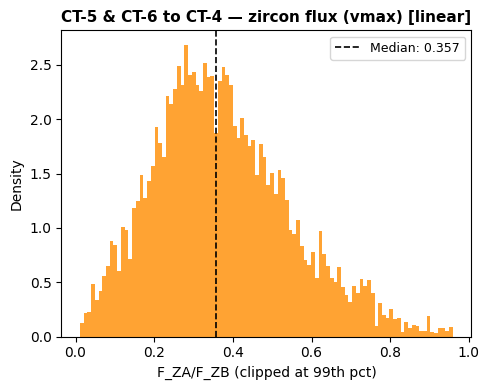

  saved dist_zircon_flux_log10_ct4_vmax.pdf


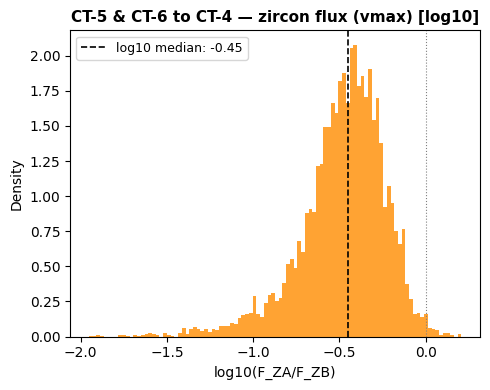

  saved dist_zircon_fertility_linear_ct10_vmax.pdf


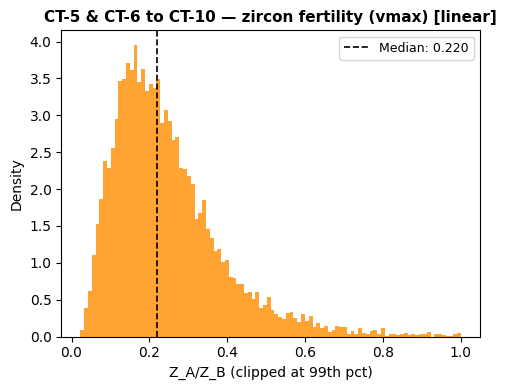

  saved dist_zircon_fertility_log10_ct10_vmax.pdf


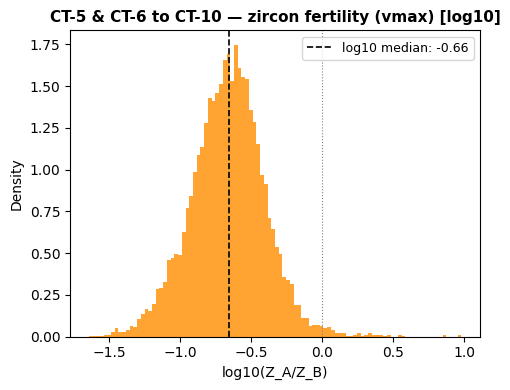

  saved dist_zircon_flux_linear_ct10_vmax.pdf


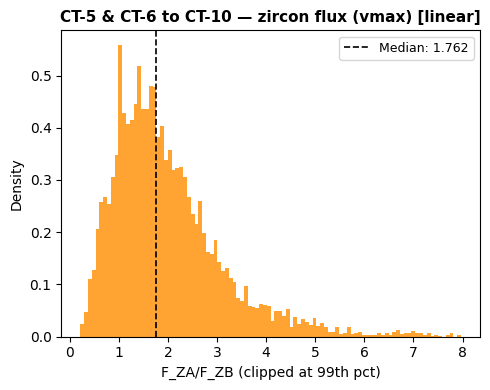

  saved dist_zircon_flux_log10_ct10_vmax.pdf


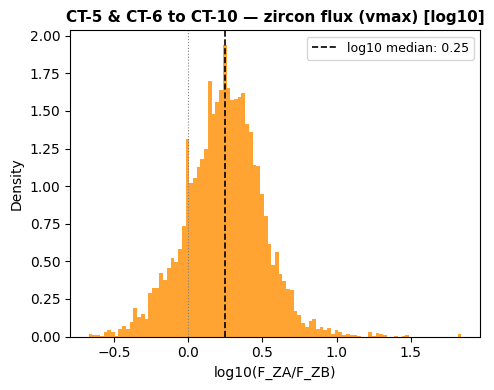

  saved dist_zircon_fertility_linear_ct11_vmax.pdf


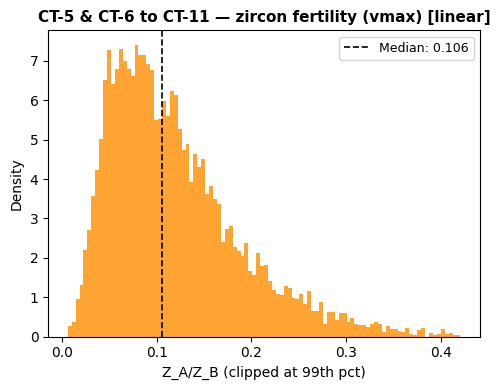

  saved dist_zircon_fertility_log10_ct11_vmax.pdf


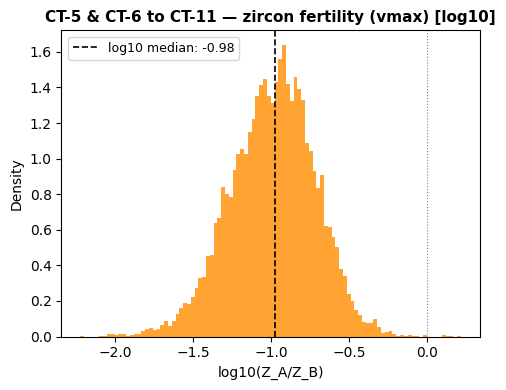

  saved dist_zircon_flux_linear_ct11_vmax.pdf


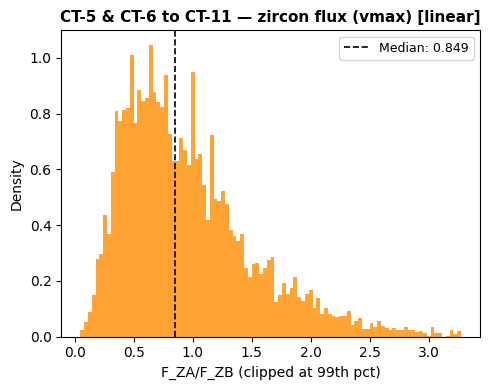

  saved dist_zircon_flux_log10_ct11_vmax.pdf


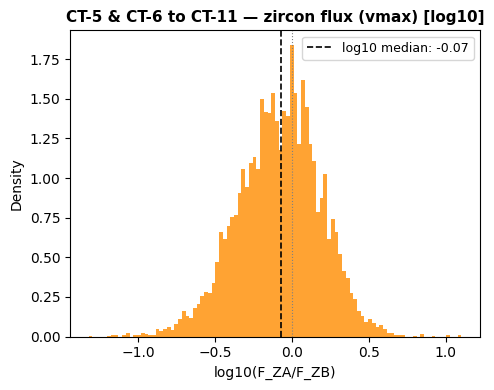

  saved dist_zircon_fertility_linear_ct82_vmax.pdf


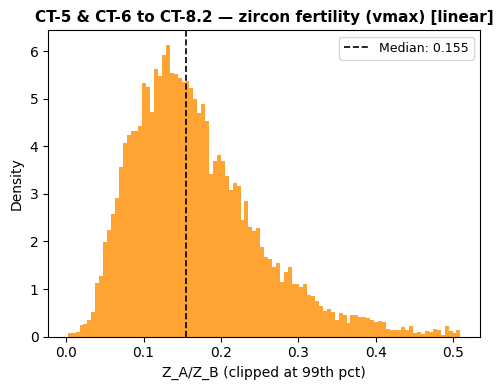

  saved dist_zircon_fertility_log10_ct82_vmax.pdf


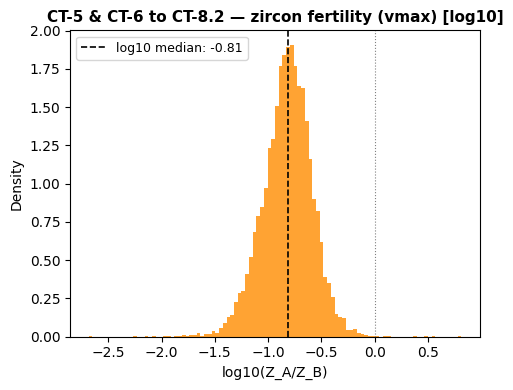

  saved dist_zircon_flux_linear_ct82_vmax.pdf


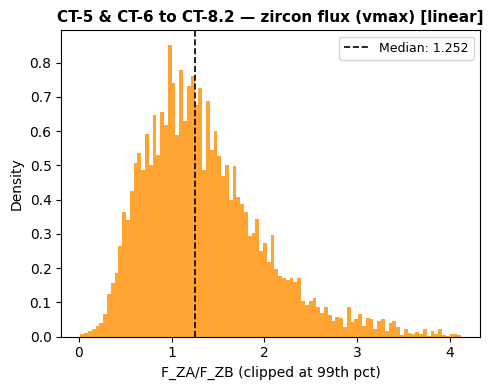

  saved dist_zircon_flux_log10_ct82_vmax.pdf


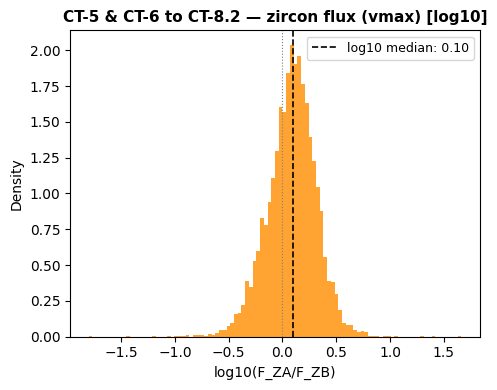

  saved dist_zircon_fertility_linear_ct9_83_vmax.pdf


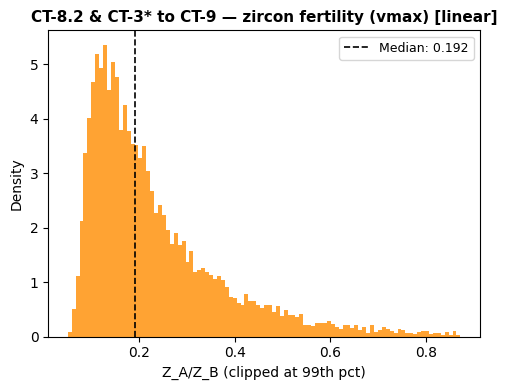

  saved dist_zircon_fertility_log10_ct9_83_vmax.pdf


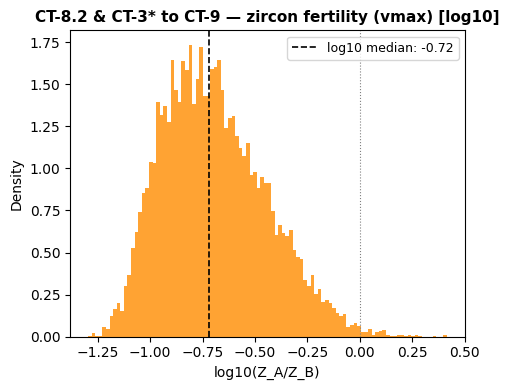

  saved dist_zircon_flux_linear_ct9_83_vmax.pdf


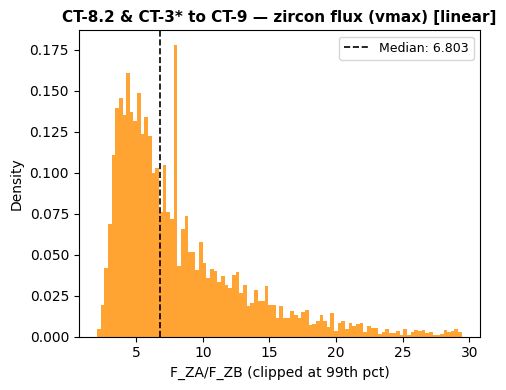

  saved dist_zircon_flux_log10_ct9_83_vmax.pdf


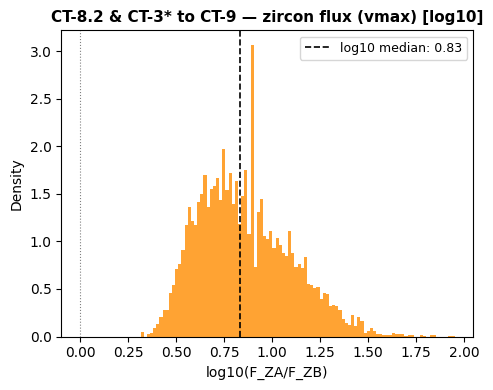

  saved dist_zircon_fertility_linear_ct9_43_vmax.pdf


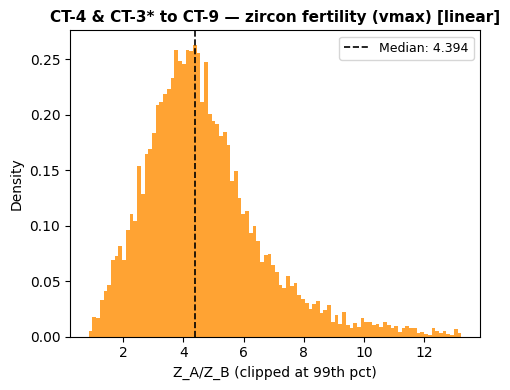

  saved dist_zircon_fertility_log10_ct9_43_vmax.pdf


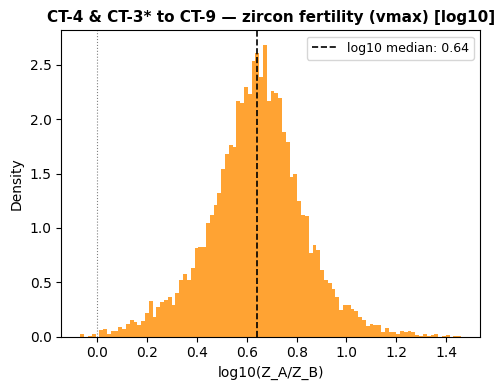

  saved dist_zircon_flux_linear_ct9_43_vmax.pdf


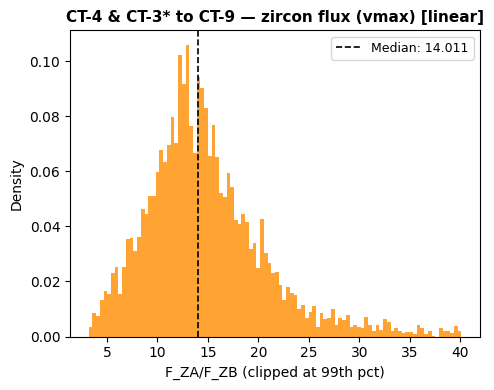

  saved dist_zircon_flux_log10_ct9_43_vmax.pdf


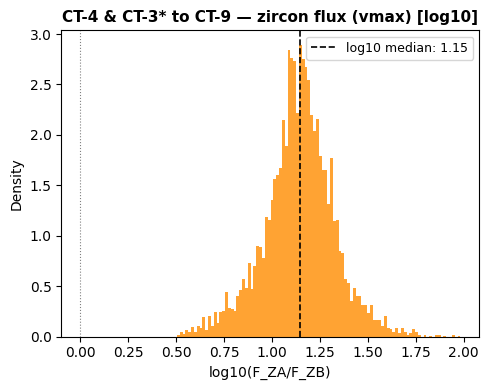

  saved dist_zircon_fertility_linear_ct9_103_vmax.pdf


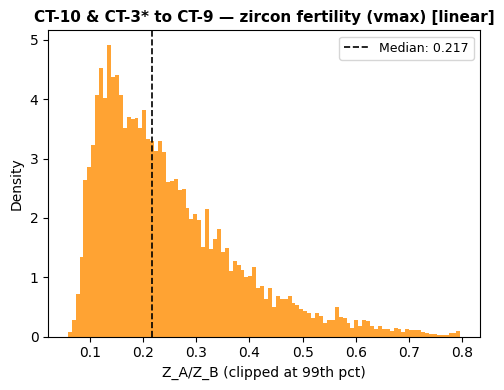

  saved dist_zircon_fertility_log10_ct9_103_vmax.pdf


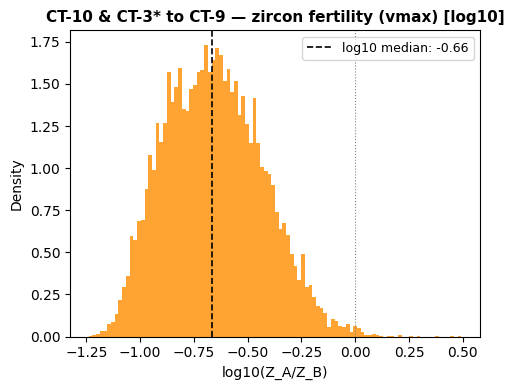

  saved dist_zircon_flux_linear_ct9_103_vmax.pdf


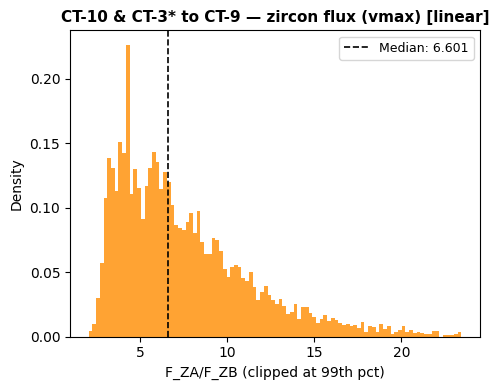

  saved dist_zircon_flux_log10_ct9_103_vmax.pdf


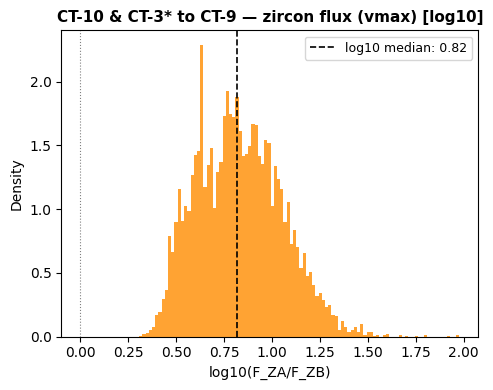

  saved dist_zircon_fertility_linear_ct9_113_vmax.pdf


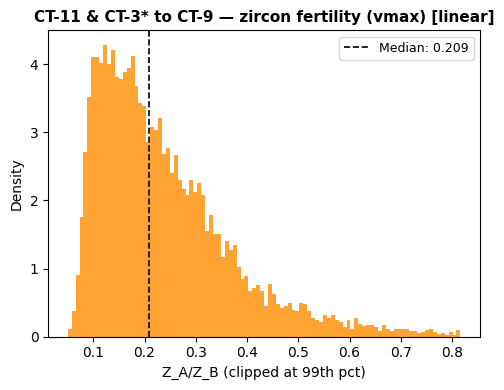

  saved dist_zircon_fertility_log10_ct9_113_vmax.pdf


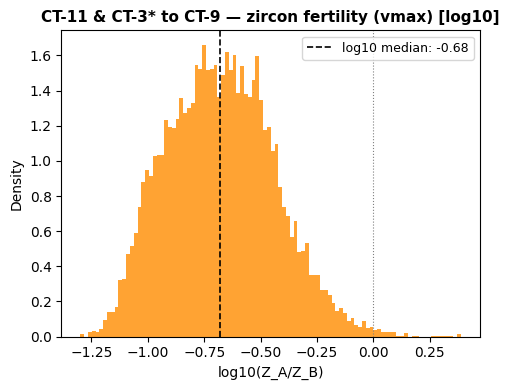

  saved dist_zircon_flux_linear_ct9_113_vmax.pdf


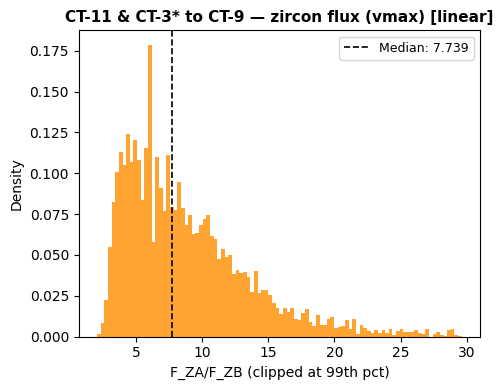

  saved dist_zircon_flux_log10_ct9_113_vmax.pdf


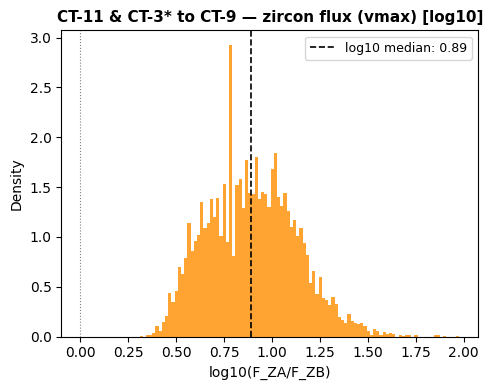

  saved dist_zircon_fertility_linear_ct2_83_vmax.pdf


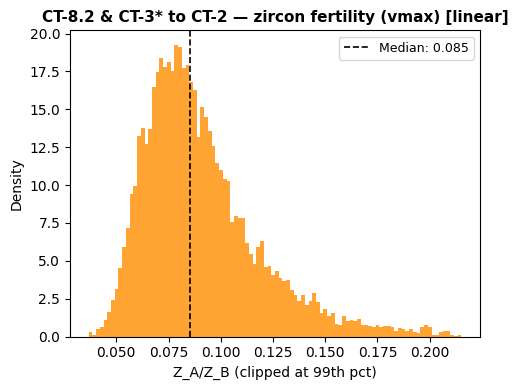

  saved dist_zircon_fertility_log10_ct2_83_vmax.pdf


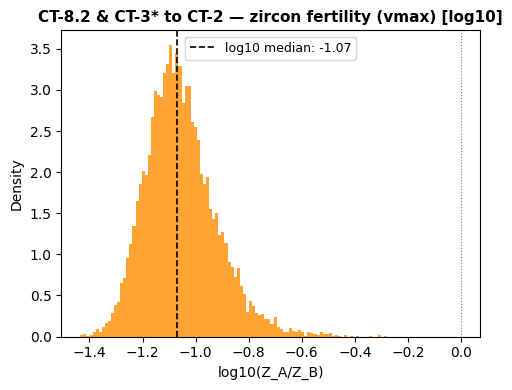

  saved dist_zircon_flux_linear_ct2_83_vmax.pdf


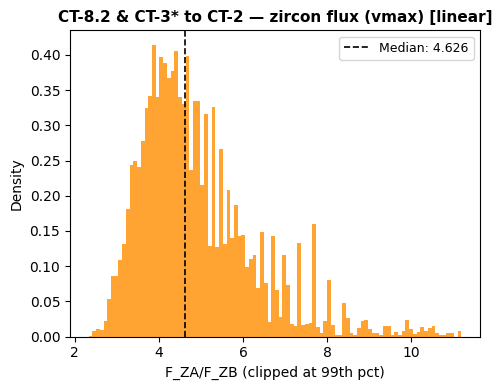

  saved dist_zircon_flux_log10_ct2_83_vmax.pdf


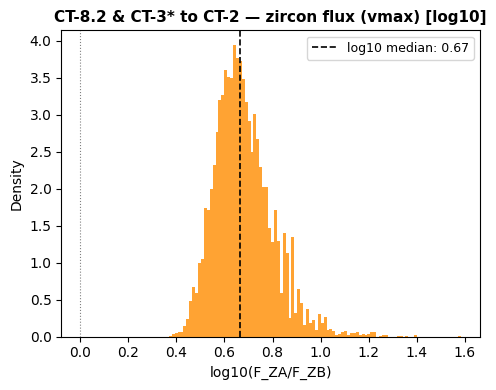

  saved dist_zircon_fertility_linear_ct2_43_vmax.pdf


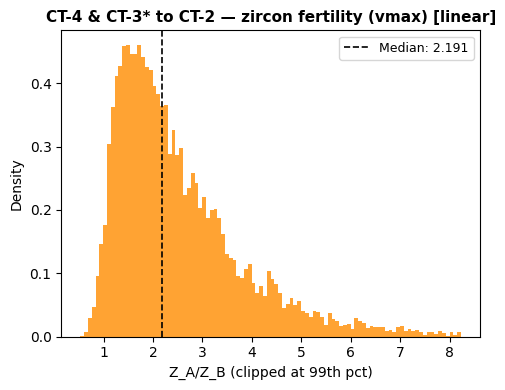

  saved dist_zircon_fertility_log10_ct2_43_vmax.pdf


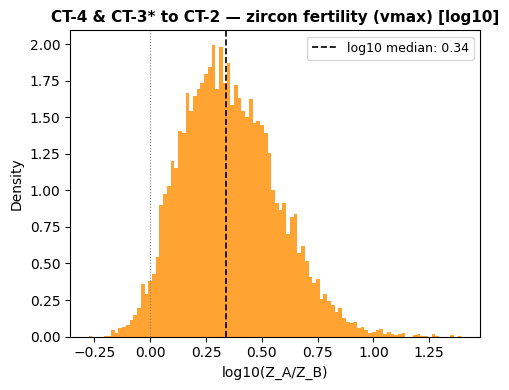

  saved dist_zircon_flux_linear_ct2_43_vmax.pdf


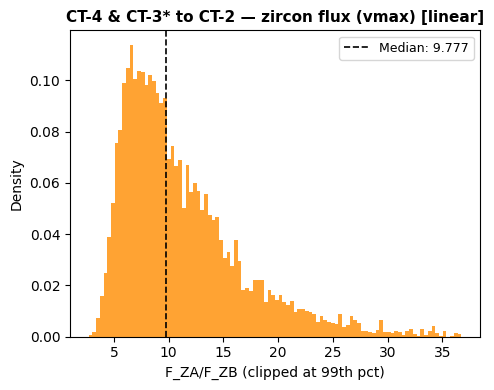

  saved dist_zircon_flux_log10_ct2_43_vmax.pdf


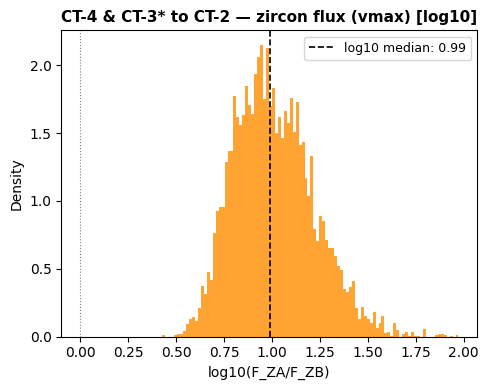

  saved dist_zircon_fertility_linear_ct2_103_vmax.pdf


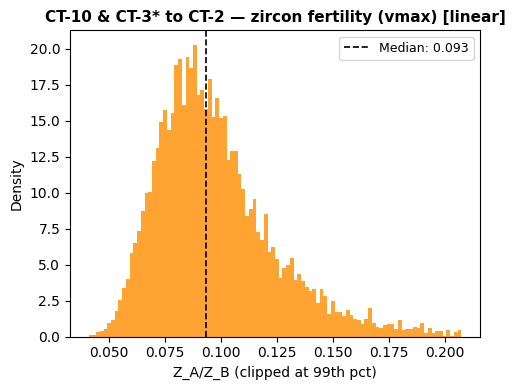

  saved dist_zircon_fertility_log10_ct2_103_vmax.pdf


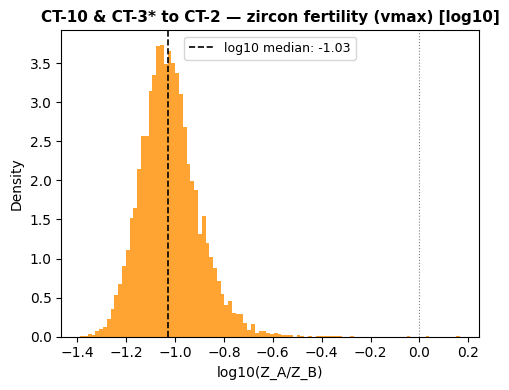

  saved dist_zircon_flux_linear_ct2_103_vmax.pdf


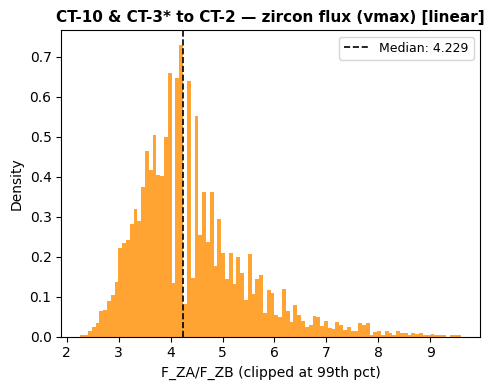

  saved dist_zircon_flux_log10_ct2_103_vmax.pdf


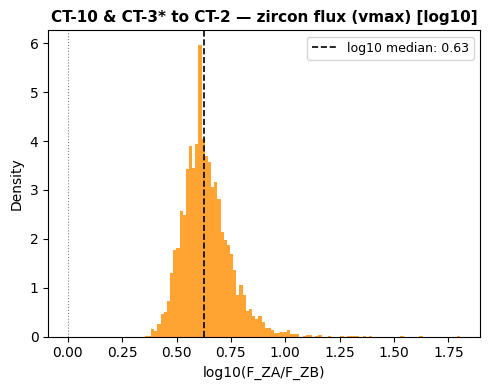

  saved dist_zircon_fertility_linear_ct2_113_vmax.pdf


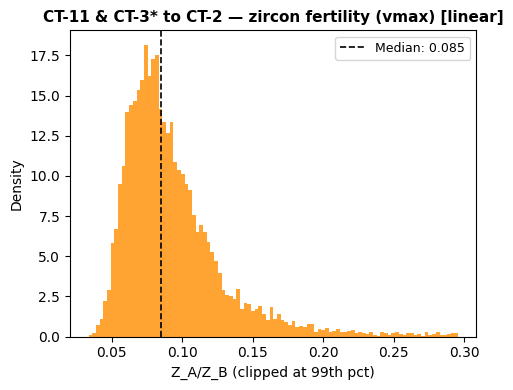

  saved dist_zircon_fertility_log10_ct2_113_vmax.pdf


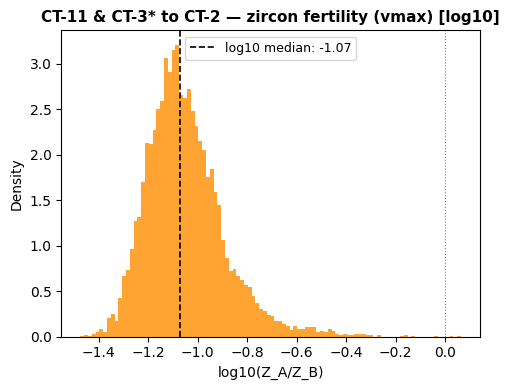

  saved dist_zircon_flux_linear_ct2_113_vmax.pdf


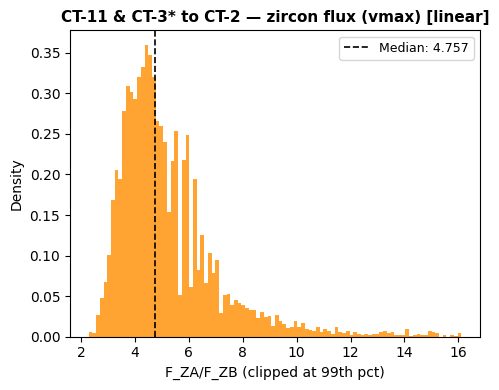

  saved dist_zircon_flux_log10_ct2_113_vmax.pdf


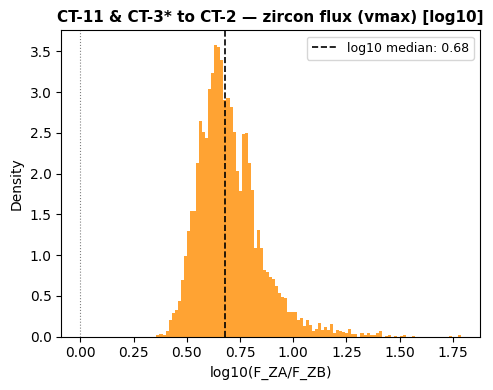

  saved dist_zircon_fertility_linear_ct4_r2kde.pdf


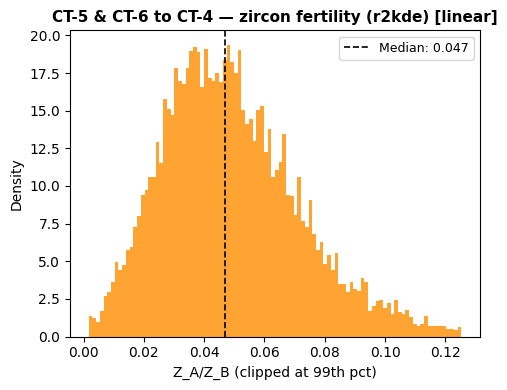

  saved dist_zircon_fertility_log10_ct4_r2kde.pdf


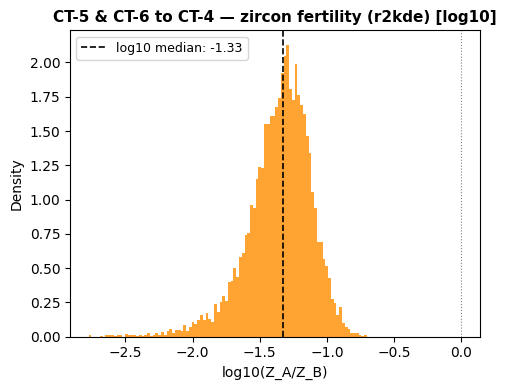

  saved dist_zircon_flux_linear_ct4_r2kde.pdf


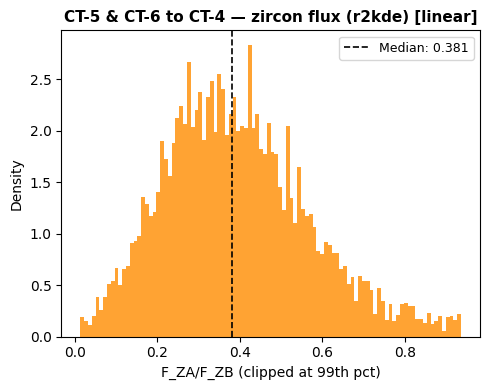

  saved dist_zircon_flux_log10_ct4_r2kde.pdf


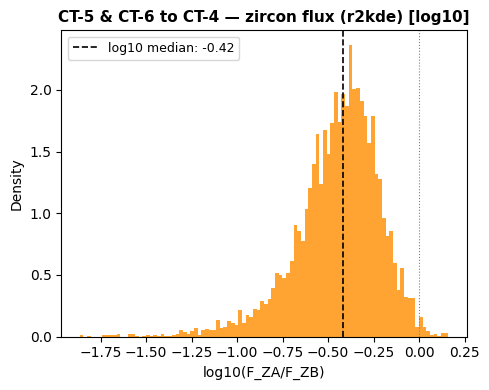

  saved dist_zircon_fertility_linear_ct10_r2kde.pdf


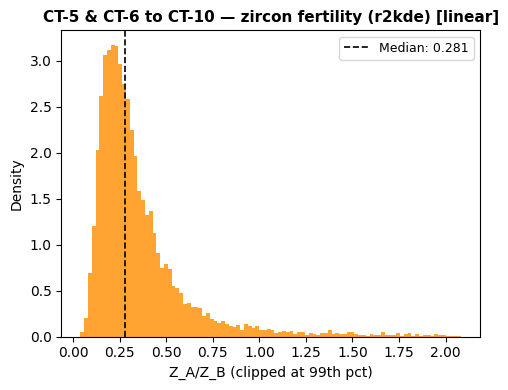

  saved dist_zircon_fertility_log10_ct10_r2kde.pdf


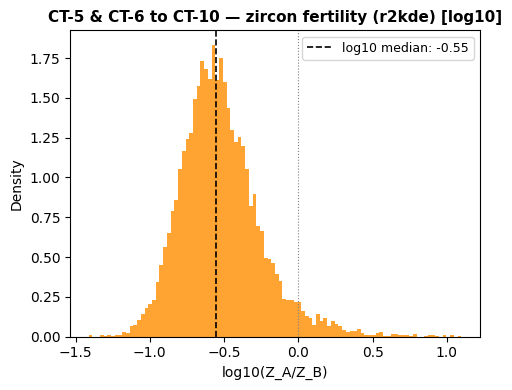

  saved dist_zircon_flux_linear_ct10_r2kde.pdf


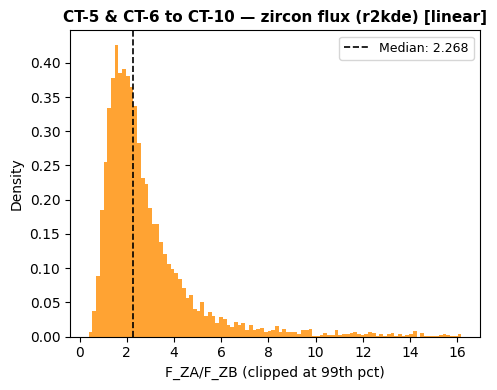

  saved dist_zircon_flux_log10_ct10_r2kde.pdf


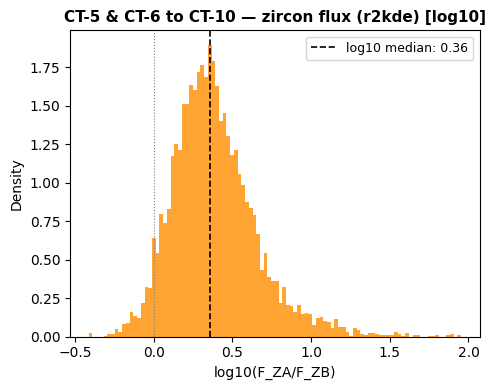

  saved dist_zircon_fertility_linear_ct11_r2kde.pdf


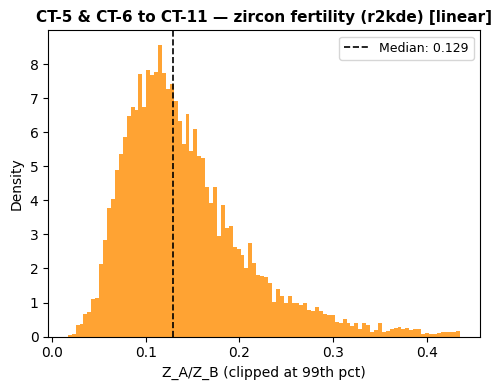

  saved dist_zircon_fertility_log10_ct11_r2kde.pdf


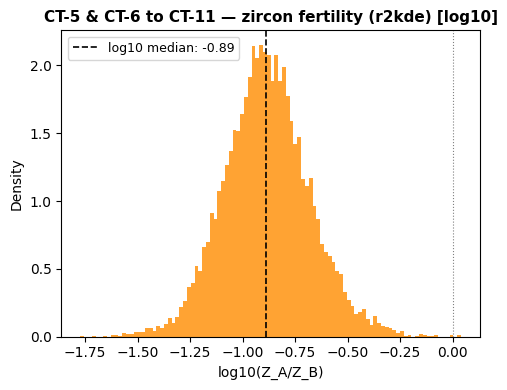

  saved dist_zircon_flux_linear_ct11_r2kde.pdf


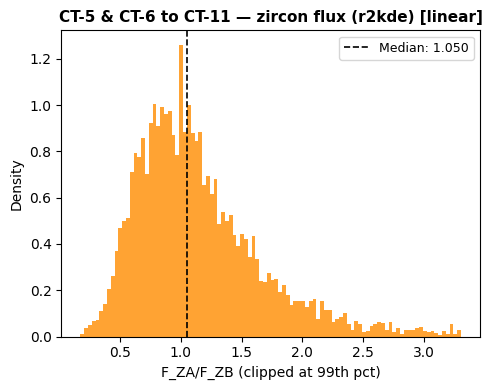

  saved dist_zircon_flux_log10_ct11_r2kde.pdf


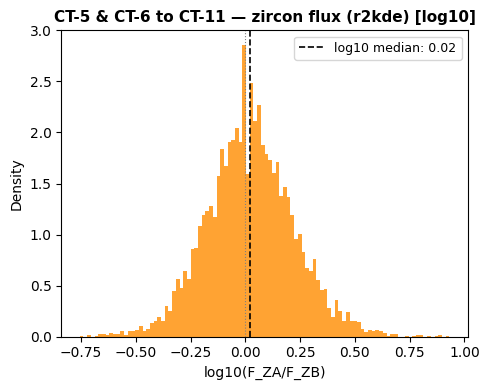

  saved dist_zircon_fertility_linear_ct82_r2kde.pdf


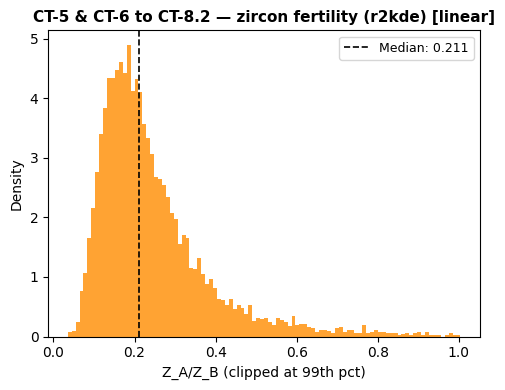

  saved dist_zircon_fertility_log10_ct82_r2kde.pdf


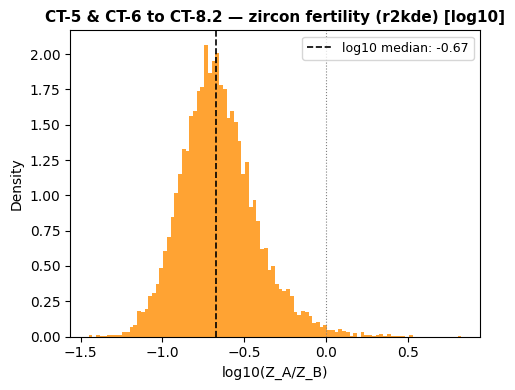

  saved dist_zircon_flux_linear_ct82_r2kde.pdf


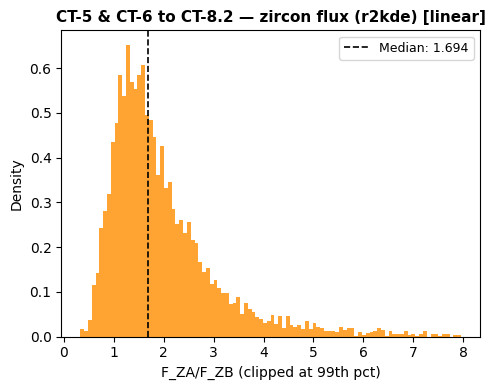

  saved dist_zircon_flux_log10_ct82_r2kde.pdf


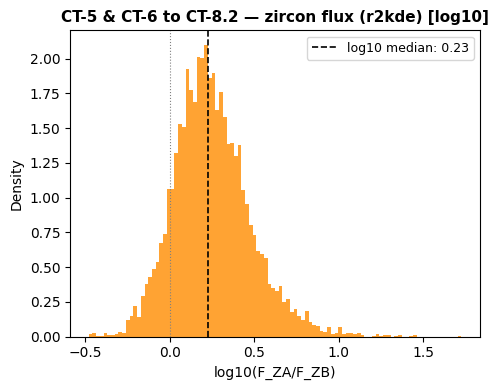

  saved dist_zircon_fertility_linear_ct9_83_r2kde.pdf


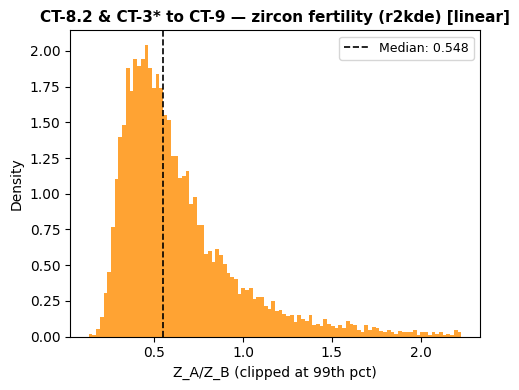

  saved dist_zircon_fertility_log10_ct9_83_r2kde.pdf


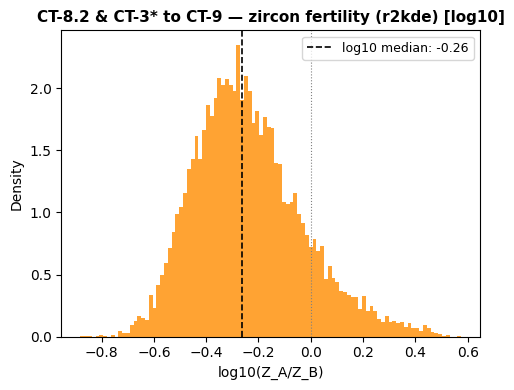

  saved dist_zircon_flux_linear_ct9_83_r2kde.pdf


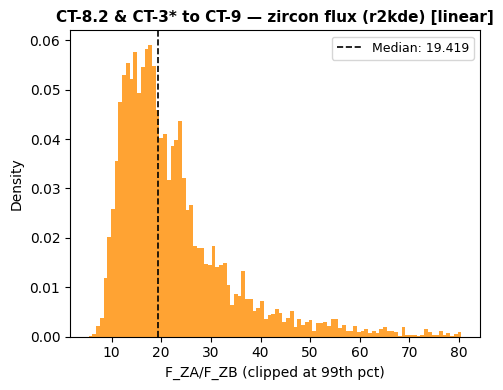

  saved dist_zircon_flux_log10_ct9_83_r2kde.pdf


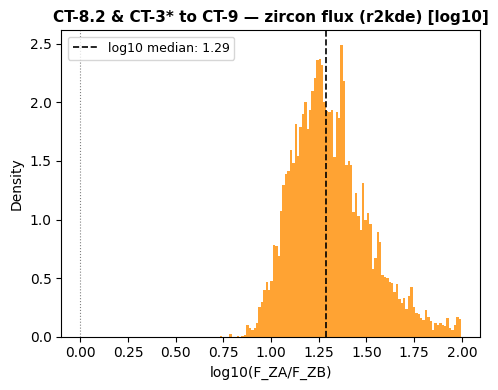

  saved dist_zircon_fertility_linear_ct9_43_r2kde.pdf


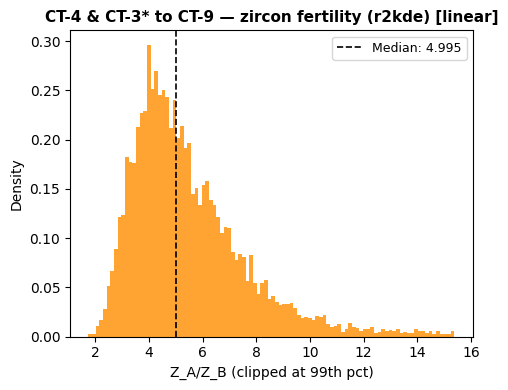

  saved dist_zircon_fertility_log10_ct9_43_r2kde.pdf


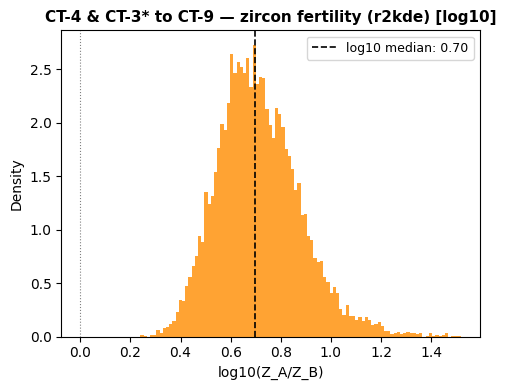

  saved dist_zircon_flux_linear_ct9_43_r2kde.pdf


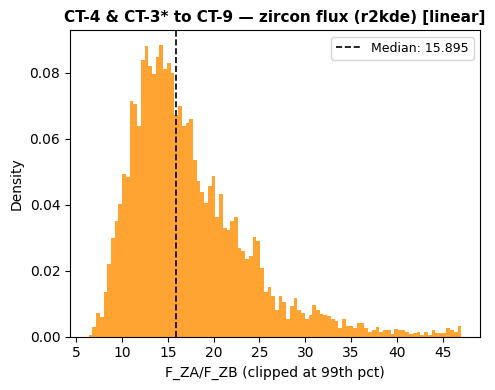

  saved dist_zircon_flux_log10_ct9_43_r2kde.pdf


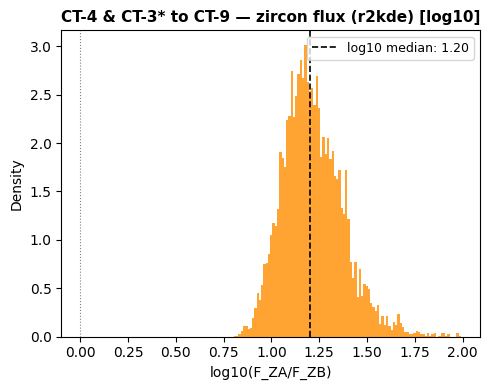

  saved dist_zircon_fertility_linear_ct9_103_r2kde.pdf


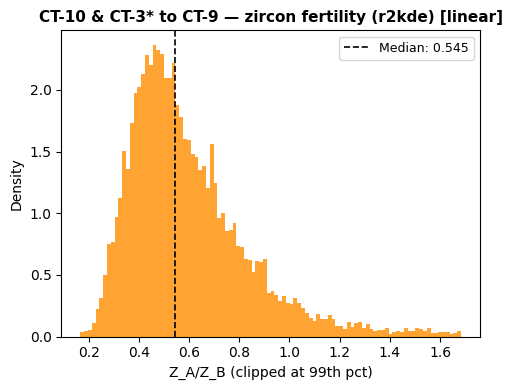

  saved dist_zircon_fertility_log10_ct9_103_r2kde.pdf


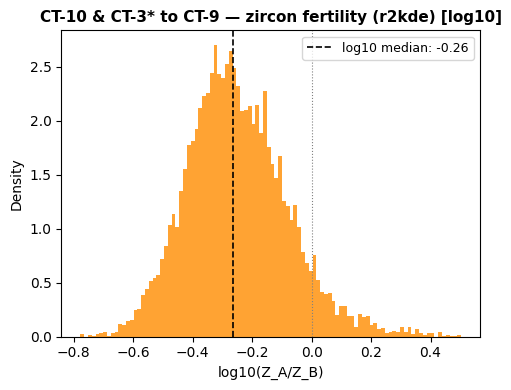

  saved dist_zircon_flux_linear_ct9_103_r2kde.pdf


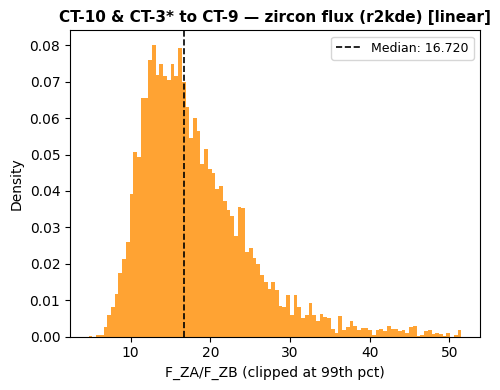

  saved dist_zircon_flux_log10_ct9_103_r2kde.pdf


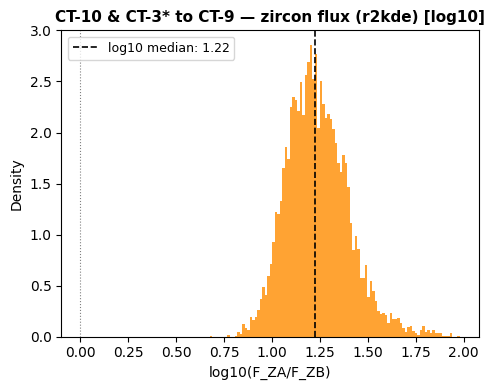

  saved dist_zircon_fertility_linear_ct9_113_r2kde.pdf


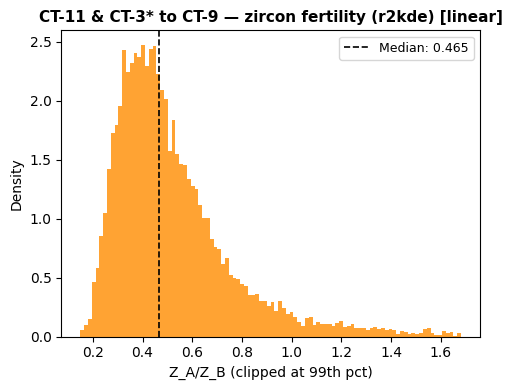

  saved dist_zircon_fertility_log10_ct9_113_r2kde.pdf


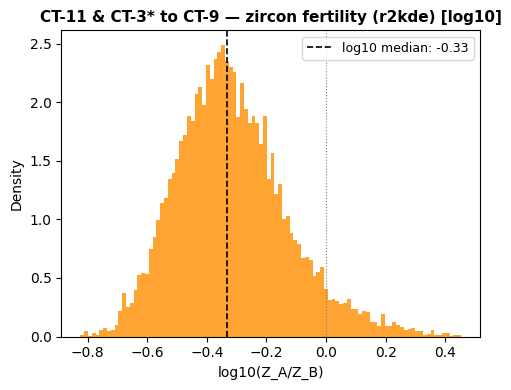

  saved dist_zircon_flux_linear_ct9_113_r2kde.pdf


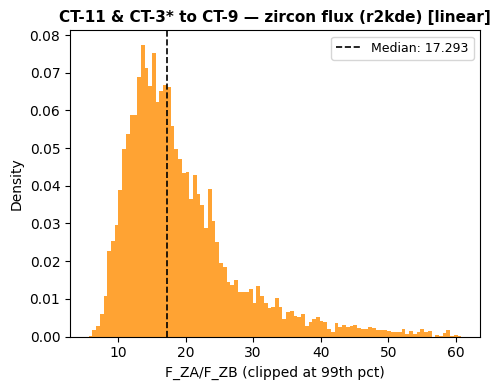

  saved dist_zircon_flux_log10_ct9_113_r2kde.pdf


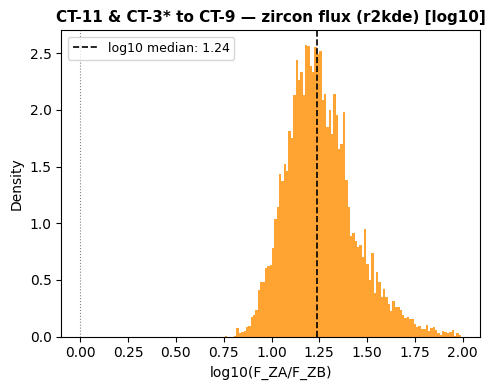

  saved dist_zircon_fertility_linear_ct2_83_r2kde.pdf


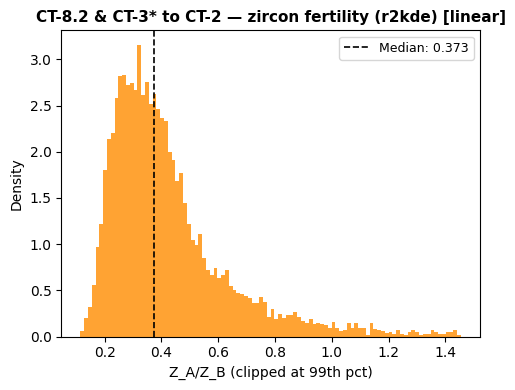

  saved dist_zircon_fertility_log10_ct2_83_r2kde.pdf


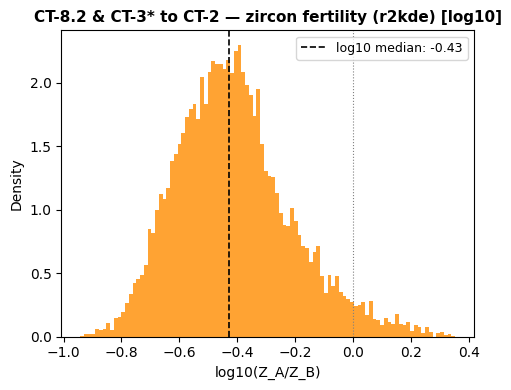

  saved dist_zircon_flux_linear_ct2_83_r2kde.pdf


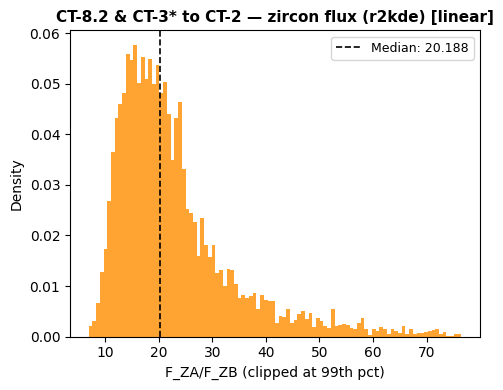

  saved dist_zircon_flux_log10_ct2_83_r2kde.pdf


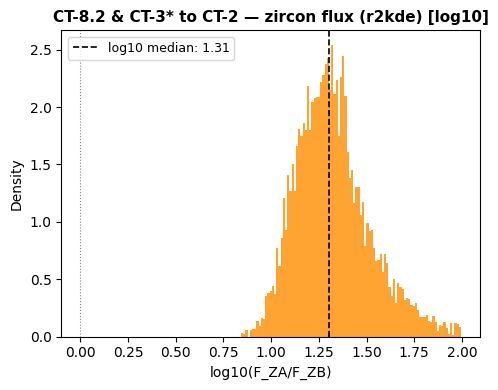

  saved dist_zircon_fertility_linear_ct2_43_r2kde.pdf


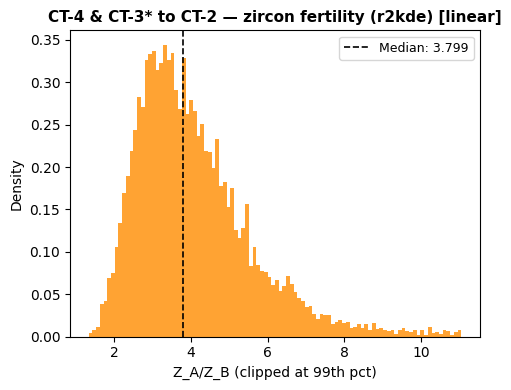

  saved dist_zircon_fertility_log10_ct2_43_r2kde.pdf


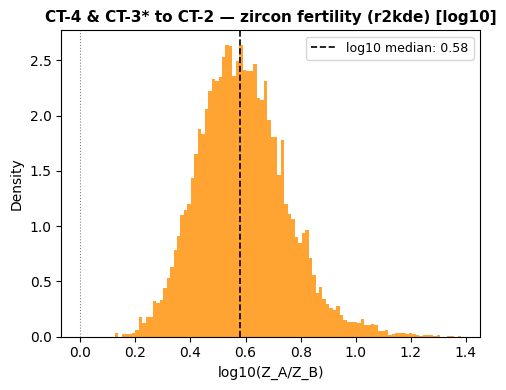

  saved dist_zircon_flux_linear_ct2_43_r2kde.pdf


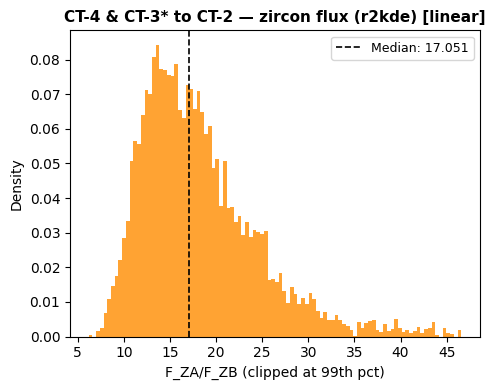

  saved dist_zircon_flux_log10_ct2_43_r2kde.pdf


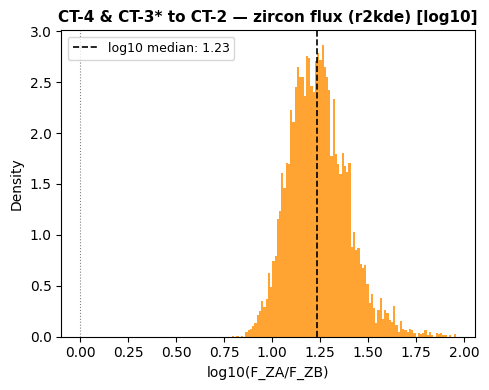

  saved dist_zircon_fertility_linear_ct2_103_r2kde.pdf


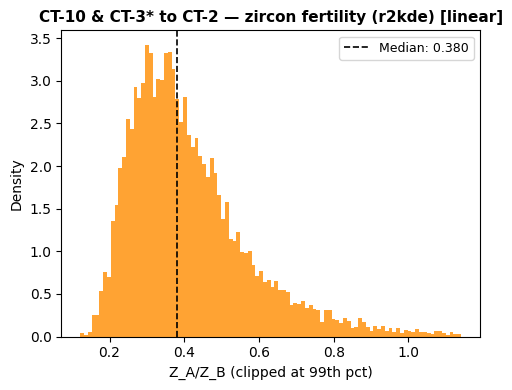

  saved dist_zircon_fertility_log10_ct2_103_r2kde.pdf


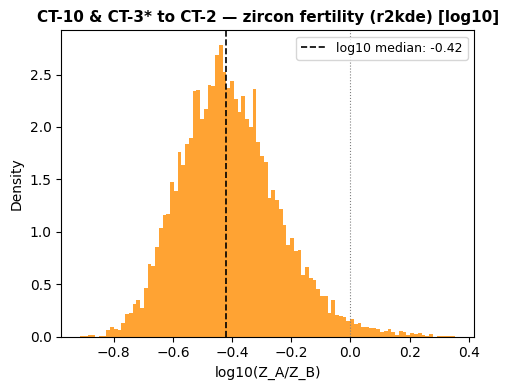

  saved dist_zircon_flux_linear_ct2_103_r2kde.pdf


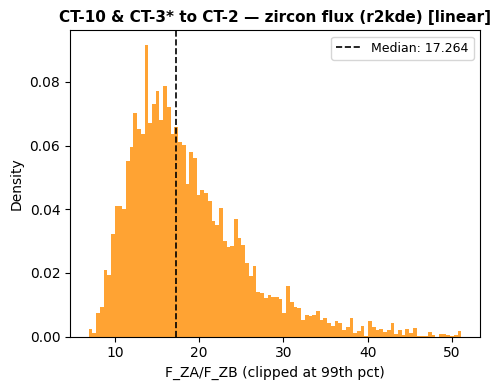

  saved dist_zircon_flux_log10_ct2_103_r2kde.pdf


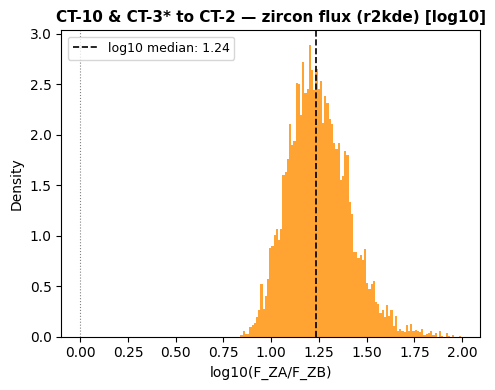

  saved dist_zircon_fertility_linear_ct2_113_r2kde.pdf


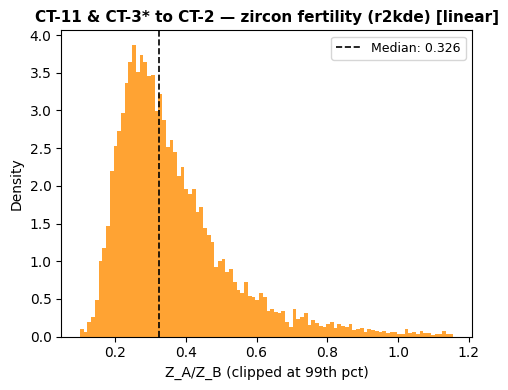

  saved dist_zircon_fertility_log10_ct2_113_r2kde.pdf


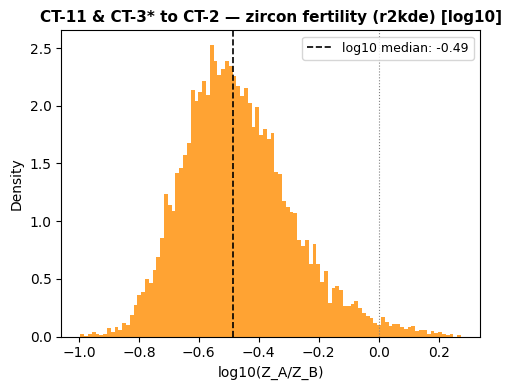

  saved dist_zircon_flux_linear_ct2_113_r2kde.pdf


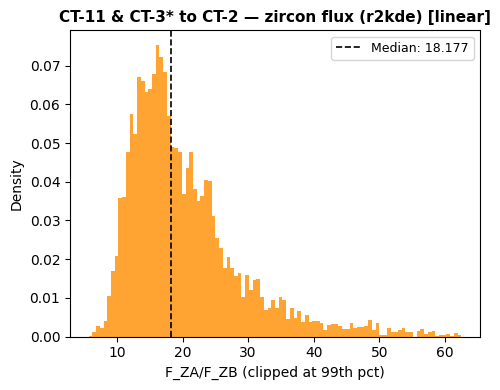

  saved dist_zircon_flux_log10_ct2_113_r2kde.pdf


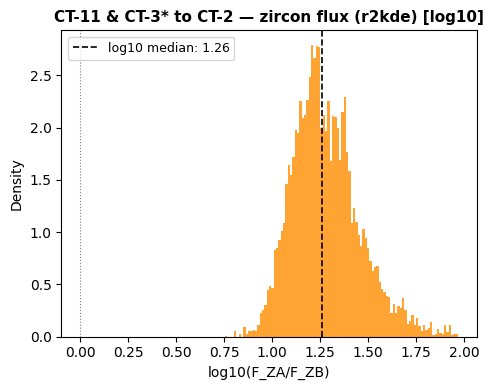

In [23]:
# ── Zircon distributions, one set per metric ────────────────────────────────
# One linear + one log10 histogram per scenario per metric, for fertility and flux
for metric in METRICS:
    for key, s in SCENARIOS.items():
        z = zircon[metric][key]
        for res_key, sym, tag in [('ZA_ZB', 'Z_A/Z_B', 'fertility'),
                                  ('FZA_FZB', 'F_ZA/F_ZB', 'flux')]:
            arr = z[res_key]['samples']
            ttl = f"{s['label']} — zircon {tag} ({metric})"
            fig = plot_hist(arr, ttl + ' [linear]',
                            f'{sym} (clipped at 99th pct)', 'darkorange', log=False)
            savefig(fig, f'dist_zircon_{tag}_linear_{key}_{metric}')   # PDF only if SAVE_FIGS
            plt.show()
            fig = plot_hist(arr, ttl + ' [log10]',
                            f'log10({sym})', 'darkorange', log=True)
            savefig(fig, f'dist_zircon_{tag}_log10_{key}_{metric}')     # PDF only if SAVE_FIGS
            plt.show()

  saved dist_combined_ct5_ct6_quartz_fertility_log10.pdf


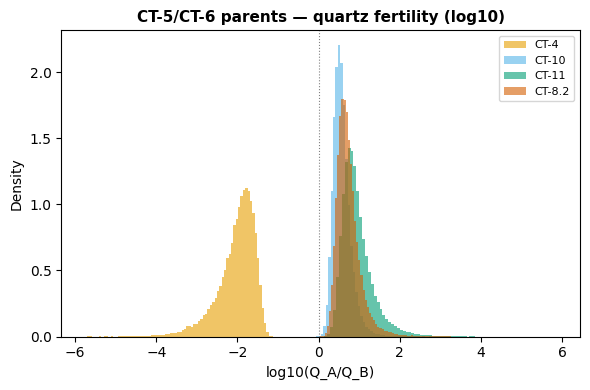

  saved dist_combined_ct5_ct6_quartz_flux_log10.pdf


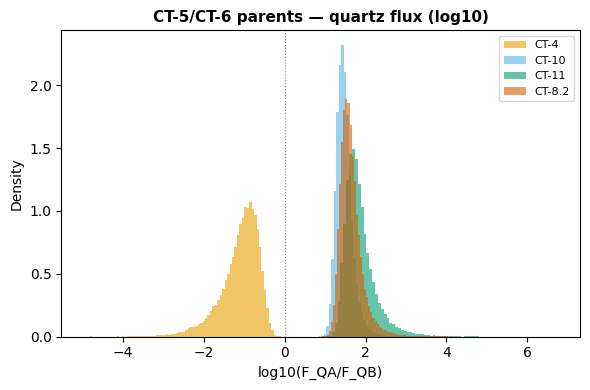

  saved dist_combined_ct82_ct3_quartz_fertility_log10.pdf


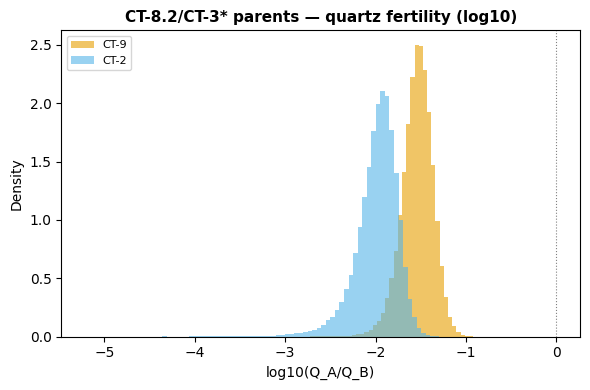

  saved dist_combined_ct82_ct3_quartz_flux_log10.pdf


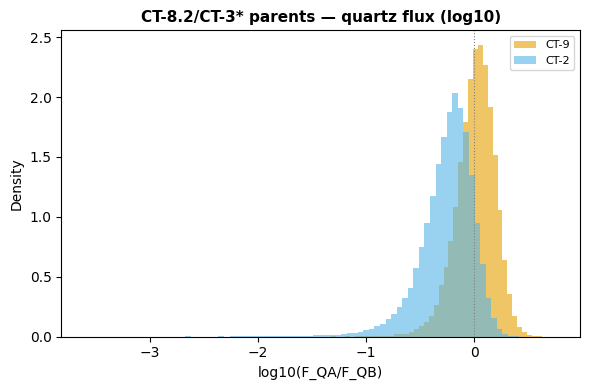

  saved dist_combined_ct9_expl_quartz_fertility_log10.pdf


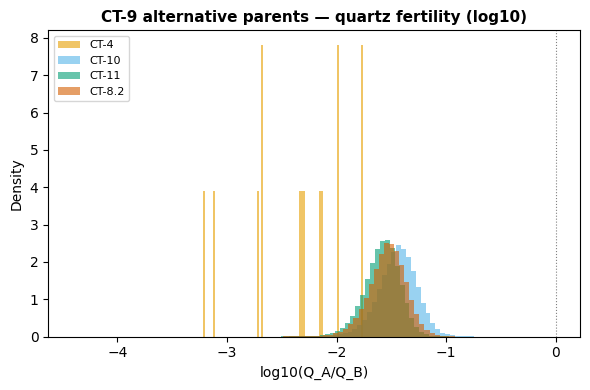

  saved dist_combined_ct9_expl_quartz_flux_log10.pdf


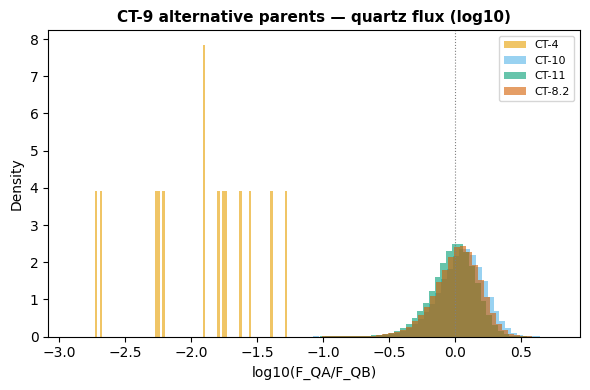

  saved dist_combined_ct2_expl_quartz_fertility_log10.pdf


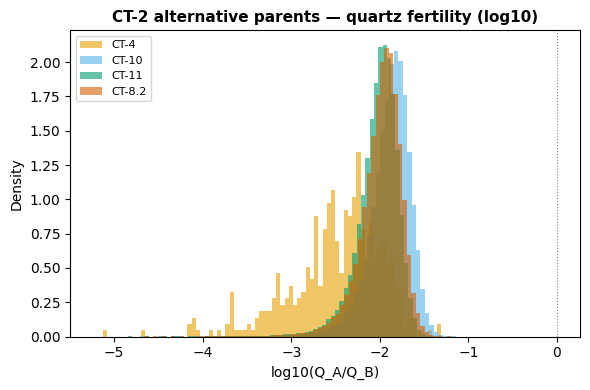

  saved dist_combined_ct2_expl_quartz_flux_log10.pdf


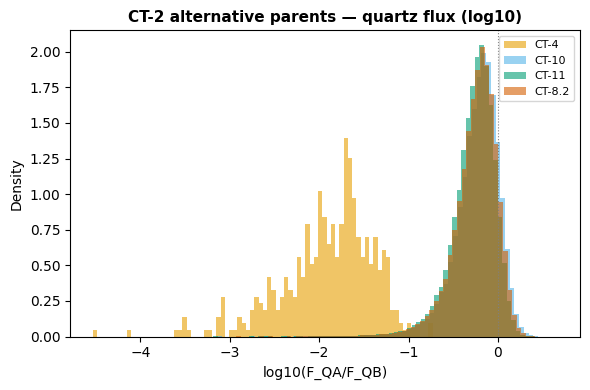

  saved dist_combined_ct5_ct6_zircon_fertility_log10_vmax.pdf


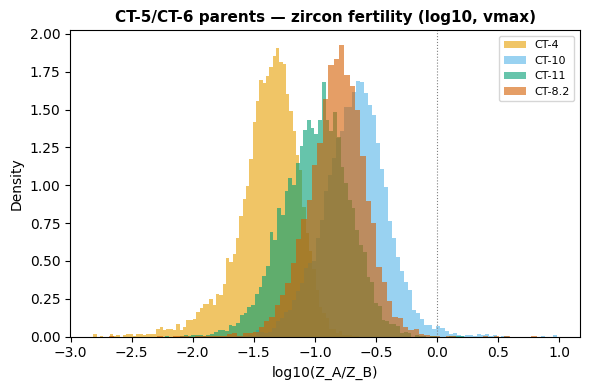

  saved dist_combined_ct5_ct6_zircon_flux_log10_vmax.pdf


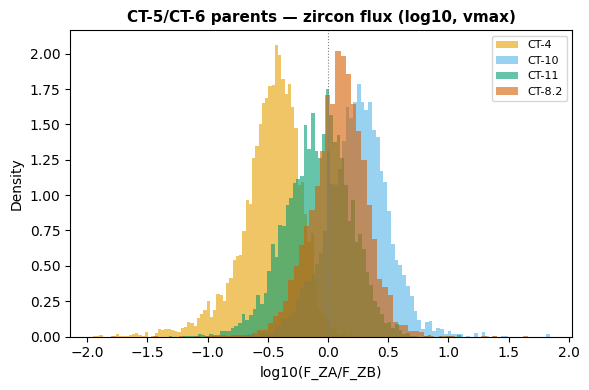

  saved dist_combined_ct82_ct3_zircon_fertility_log10_vmax.pdf


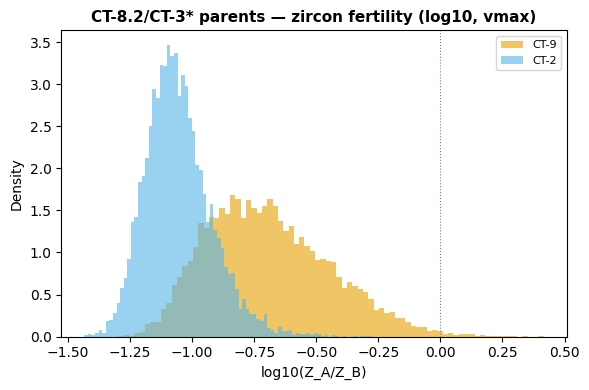

  saved dist_combined_ct82_ct3_zircon_flux_log10_vmax.pdf


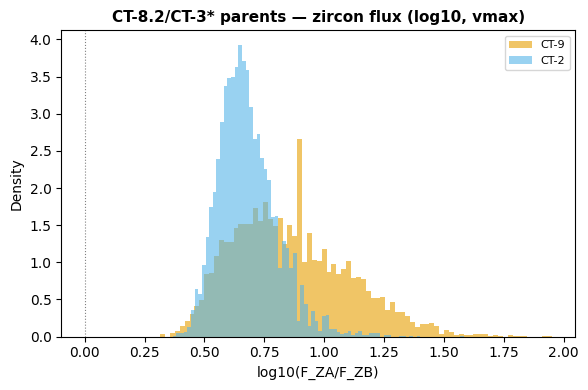

  saved dist_combined_ct9_expl_zircon_fertility_log10_vmax.pdf


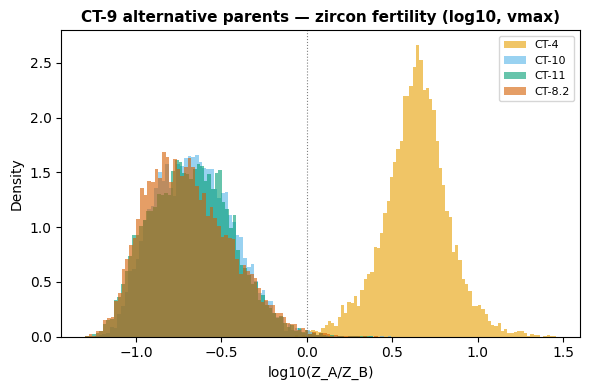

  saved dist_combined_ct9_expl_zircon_flux_log10_vmax.pdf


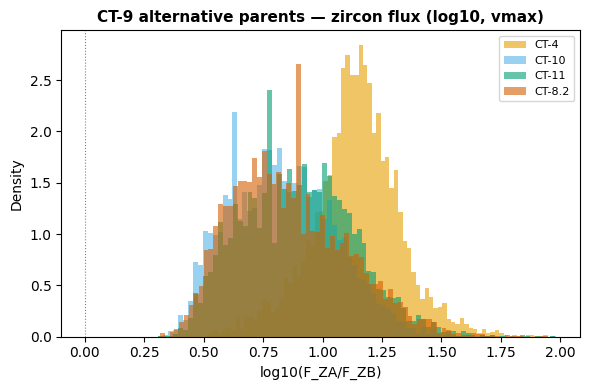

  saved dist_combined_ct2_expl_zircon_fertility_log10_vmax.pdf


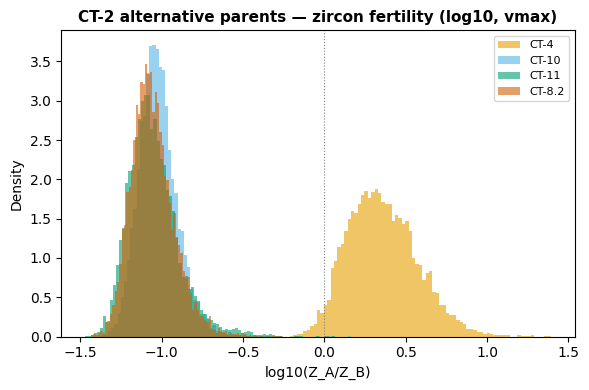

  saved dist_combined_ct2_expl_zircon_flux_log10_vmax.pdf


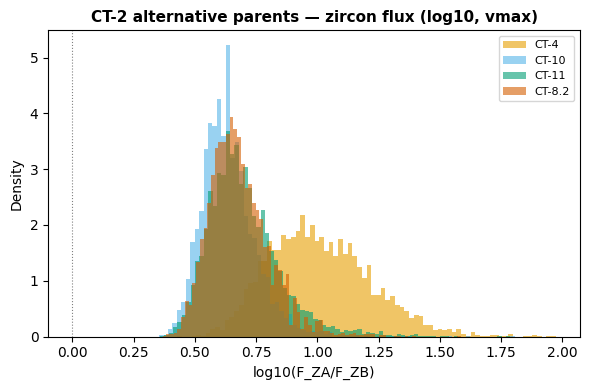

  saved dist_combined_ct5_ct6_zircon_fertility_log10_r2kde.pdf


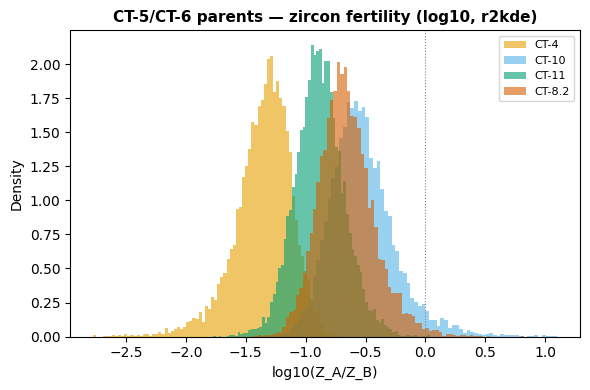

  saved dist_combined_ct5_ct6_zircon_flux_log10_r2kde.pdf


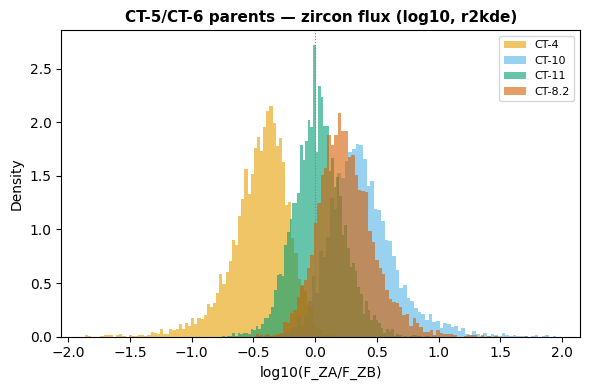

  saved dist_combined_ct82_ct3_zircon_fertility_log10_r2kde.pdf


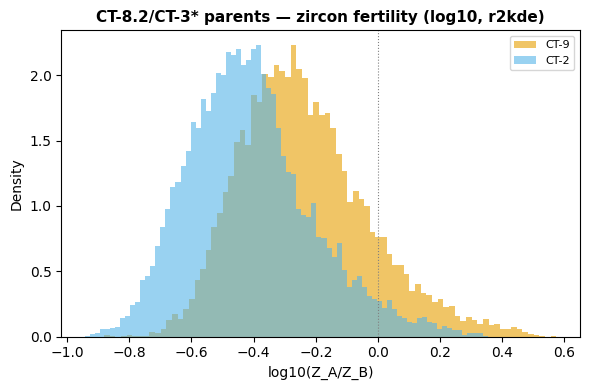

  saved dist_combined_ct82_ct3_zircon_flux_log10_r2kde.pdf


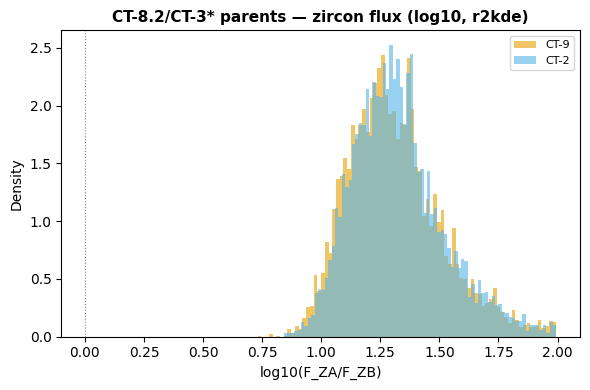

  saved dist_combined_ct9_expl_zircon_fertility_log10_r2kde.pdf


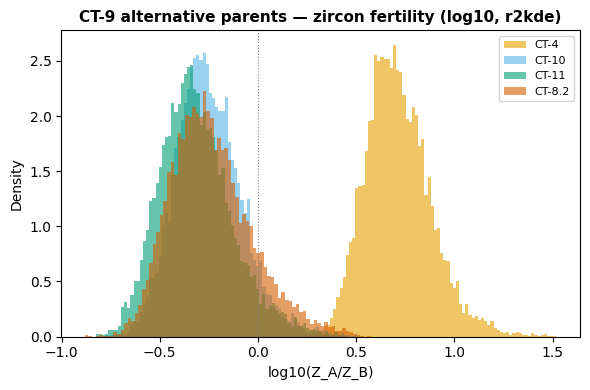

  saved dist_combined_ct9_expl_zircon_flux_log10_r2kde.pdf


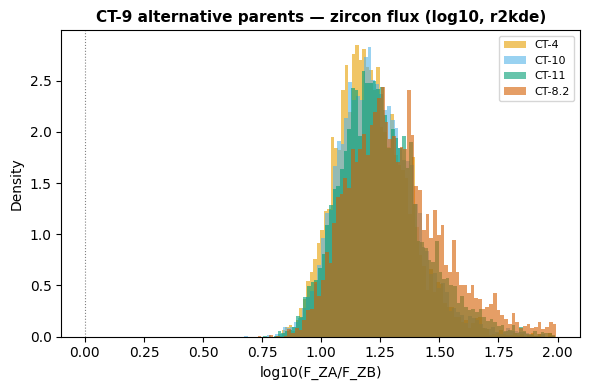

  saved dist_combined_ct2_expl_zircon_fertility_log10_r2kde.pdf


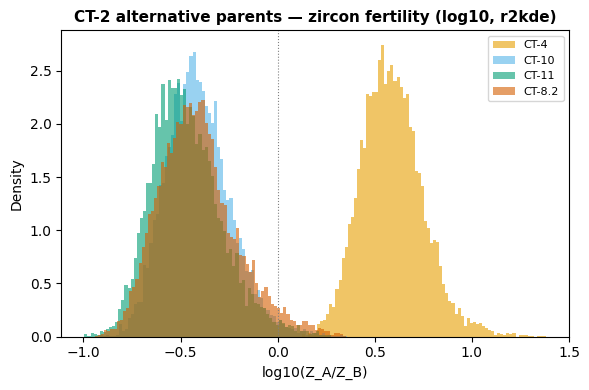

  saved dist_combined_ct2_expl_zircon_flux_log10_r2kde.pdf


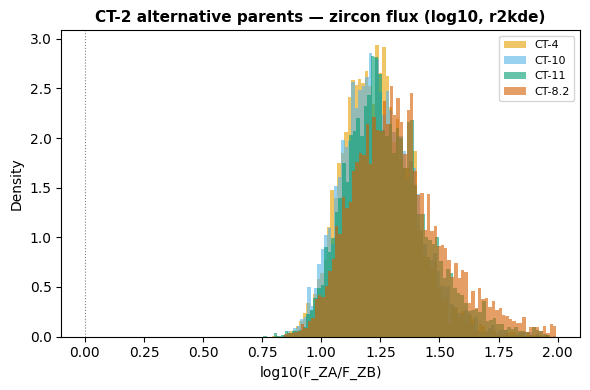

In [24]:
# ── Combined comparison — all children of one parent pair on one axis ───────
# Colourblind-safe palette (Wong 2011), one colour per child in a group
CB_COLORS = ['#E69F00', '#56B4E9', '#009E73', '#D55E00']

# Each group = (scenario keys, legend labels, title). Grouped by parent pair,
# with the alternative-parent sets split by child so each fits the 4-colour palette.
GROUPS = {
    'ct5_ct6':   (['ct4', 'ct10', 'ct11', 'ct82'],
                  ['CT-4', 'CT-10', 'CT-11', 'CT-8.2'], 'CT-5/CT-6 parents'),
    'ct82_ct3':  (['ct9_83', 'ct2_83'],
                  ['CT-9', 'CT-2'], 'CT-8.2/CT-3* parents'),
    'ct9_expl':  (['ct9_43', 'ct9_103', 'ct9_113', 'ct9_83'],
                  ['CT-4', 'CT-10', 'CT-11', 'CT-8.2'], 'CT-9 alternative parents'),
    'ct2_expl':  (['ct2_43', 'ct2_103', 'ct2_113', 'ct2_83'],
                  ['CT-4', 'CT-10', 'CT-11', 'CT-8.2'], 'CT-2 alternative parents'),
}

# Quartz — metric-independent, so one figure per group per quantity
for gname, (keys, labels, title) in GROUPS.items():
    for arr_key, sym, tag in [('Q', 'Q_A/Q_B', 'fertility'),
                              ('F', 'F_QA/F_QB', 'flux')]:
        fig, ax = plt.subplots(figsize=(6, 4))
        for i, (k, lbl) in enumerate(zip(keys, labels)):
            ax.hist(np.log10(quartz[k][arr_key]), bins=80, alpha=0.6,
                    color=CB_COLORS[i], density=True, label=lbl, edgecolor='none')
        ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')   # ratio = 1
        ax.set_xlabel(f'log10({sym})'); ax.set_ylabel('Density')
        ax.set_title(f'{title} — quartz {tag} (log10)', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        plt.tight_layout()
        savefig(fig, f'dist_combined_{gname}_quartz_{tag}_log10')    # PDF only if SAVE_FIGS
        plt.show()

# Zircon — one figure per group per quantity per metric
for metric in METRICS:
    for gname, (keys, labels, title) in GROUPS.items():
        for res_key, sym, tag in [('ZA_ZB', 'Z_A/Z_B', 'fertility'),
                                  ('FZA_FZB', 'F_ZA/F_ZB', 'flux')]:
            fig, ax = plt.subplots(figsize=(6, 4))
            for i, (k, lbl) in enumerate(zip(keys, labels)):
                ax.hist(zircon[metric][k][res_key]['log10_samples'], bins=80,
                        alpha=0.6, color=CB_COLORS[i], density=True,
                        label=lbl, edgecolor='none')
            ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')   # ratio = 1
            ax.set_xlabel(f'log10({sym})'); ax.set_ylabel('Density')
            ax.set_title(f'{title} — zircon {tag} (log10, {metric})',
                         fontsize=11, fontweight='bold')
            ax.legend(fontsize=8)
            plt.tight_layout()
            savefig(fig, f'dist_combined_{gname}_zircon_{tag}_log10_{metric}')  # PDF only if SAVE_FIGS
            plt.show()

---
## 14. Flux-ordering sensitivity

The mass-balance constraint is retained as the primary analysis. It discards the 
majority of Monte Carlo draws for CT-7 → CT-5 (only ~21% satisfy the constraint) 
and shifts CT-5's median erosion rate upward by roughly 7% (from ~387 to ~414 m/Myr). 
Because CT-5 is the fast-eroding parent in every upstream scenario, that shift 
propagates non-linearly through the pole in the denominator of the quartz ratio.

This section reruns the **entire quartz calculation** with the raw, unordered
erosion rates so the size of that effect is on the record.

**Scope.** Only the four CT-5/CT-6 scenarios are affected. CT-6 shifts by <0.1%;
CT-8/CT-10/CT-11 are 100% retained and are numerically identical either way; CT-3
and CT-4 carry no upstream constraint. The CT-8.2/CT-3\* scenarios are therefore
unaffected by definition and are omitted here.

The **zircon** results are unaffected in the fertility case only through $E_A$ and
$E_B$; the zircon **flux** ratio ($w_a/w_b$) is completely independent of the
erosion rates and is identical under both.

In [25]:
# Compare quartz results computed with ordered vs raw (unordered) erosion rates,
# for the four CT-5/CT-6 scenarios the flux ordering actually affects.
raw = raw_triples(ER)                                    # unordered erosion triples per child
sens_rows = []
for key in ['ct4', 'ct10', 'ct11', 'ct82']:
    s = SCENARIOS[key]
    child_er_key = {'ct4': 'CT-4', 'ct10': 'CT-10',
                    'ct11': 'CT-11', 'ct82': 'CT-8'}[key]   # child sample name for `raw`
    # Ordered (primary) — already computed in the quartz section
    Q_ord = quartz[key]['Q']
    F_ord = quartz[key]['F']
    # Unordered (sensitivity) — recompute quartz with the raw erosion rates
    E_a, E_b, E_c = raw[child_er_key]
    Q_raw, F_raw, mask_raw = quartz_fertility(
        E_a, E_b, E_c,
        A_a=s['A_a'], A_b=s['A_b'],
        P_a=s['P_a'], P_b=s['P_b'], P_c=s['P_c'])
    qo, qr = ratio_stats(Q_ord), ratio_stats(Q_raw)      # fertility stats, ordered vs raw
    fo_, fr = ratio_stats(F_ord), ratio_stats(F_raw)     # flux stats, ordered vs raw
    sens_rows.append({
        'scenario': s['label'],
        'Q_ordered': qo['median'], 'Q_unordered': qr['median'],
        'Q_change_pct': 100 * (qr['median'] / qo['median'] - 1),   # % shift from ordering
        'F_ordered': fo_['median'], 'F_unordered': fr['median'],
        'F_change_pct': 100 * (fr['median'] / fo_['median'] - 1),
        'n_ordered': qo['n'], 'n_unordered': qr['n'],
    })
S2 = pd.DataFrame(sens_rows)
print("FLUX-ORDERING SENSITIVITY — quartz")
print("(ordered = primary analysis; unordered = raw Monte Carlo erosion rates)\n")
print(S2.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
print()

# Summarize the effect size directly from the computed changes, not hardcoded
max_q = S2['Q_change_pct'].abs().max()
max_f = S2['F_change_pct'].abs().max()
print(f"Interpretation: the mass-balance constraint is not cosmetic — it changes the")
print(f"quartz fertility by up to {max_q:.0f}% and the flux ratio by up to {max_f:.0f}% "
      f"across these scenarios.")
print("It is defensible (a downstream sample cannot carry less sediment than its")
print("tributaries supply), but its magnitude belongs in the paper, not a footnote.")

FLUX-ORDERING SENSITIVITY — quartz
(ordered = primary analysis; unordered = raw Monte Carlo erosion rates)

             scenario  Q_ordered  Q_unordered  Q_change_pct  F_ordered  F_unordered  F_change_pct  n_ordered  n_unordered
  CT-5 & CT-6 to CT-4      0.012        0.013         9.092      0.097        0.099         1.997      55528        55330
 CT-5 & CT-6 to CT-10      3.500        4.576        30.749     28.472       34.981        22.859      99802        97390
 CT-5 & CT-6 to CT-11      7.421       10.129        36.492     60.602       78.584        29.673      91316        74067
CT-5 & CT-6 to CT-8.2      4.806        6.500        35.248     39.169       49.933        27.479      98387        90711

Interpretation: the mass-balance constraint is not cosmetic — it changes the
quartz fertility by up to 36% and the flux ratio by up to 30% across these scenarios.
It is defensible (a downstream sample cannot carry less sediment than its
tributaries supply), but its magnitude belon

---

## 15. Results summary and table exports

Five CSVs, written to `results/fertility/`, with descriptive names:

| file | manuscript table | contents |
|---|---|---|
| `erosion_rates_flux_ordered.csv` | Table 2 (main) | measured + raw + flux-ordered erosion rates, and % of draws retained |
| `quartz_fertility_and_flux.csv` | main | quartz fertility Q_A/Q_B and flux F_QA/F_QB, linear + log10 (metric-independent) |
| `zircon_fertility_and_flux_by_metric.csv` | main | zircon fertility Z_A/Z_B and flux F_ZA/F_ZB, linear + log10, both metrics, with GOF |
| `mixing_coefficients_both_metrics.csv` | supplemental | best-fit + bootstrap median + 95% CI + crit + both fit diagnostics, both metrics |
| `flux_ordering_sensitivity.csv` | supplemental | ordered vs unordered quartz results |

The quartz and zircon tables together replace manuscript Tables 3, 4, 6 and 7.


In [26]:
# Split by mineral: quartz is metric-independent (one row per scenario); zircon
# has both metrics (one row per scenario per metric). Wide format with linear AND
# log10 columns side by side, so each table pastes into Word with no pivoting.
def _row_cols(st, prefix):
    """Six columns for one ratio: linear median/IQR + log10 median/IQR."""
    return {
        f'{prefix}_lin_median': st['median'],
        f'{prefix}_lin_p25': st['p25'],
        f'{prefix}_lin_p75': st['p75'],
        f'{prefix}_log10_median': st['log10_median'],
        f'{prefix}_log10_p25': st['log10_p25'],
        f'{prefix}_log10_p75': st['log10_p75'],
    }

# ---- Quartz table (metric-independent) ----
q_rows = []
for key, s in SCENARIOS.items():
    if key not in quartz:
        continue
    parents = results['vmax'][key]['parents']            # parent names (metric-independent)
    row = {'scenario': s['label'],
           'parents': f"{parents[0]} / {parents[1]}",
           'child': s['child']}
    row.update(_row_cols(ratio_stats(quartz[key]['Q']), 'Qfert'))   # fertility columns
    row.update(_row_cols(ratio_stats(quartz[key]['F']), 'Qflux'))   # flux columns
    row['n_retained'] = quartz[key]['n']
    row['n_total'] = quartz[key]['n_total']
    row['retention_pct'] = 100 * quartz[key]['retention']
    q_rows.append(row)
quartz_table = pd.DataFrame(q_rows)

# ---- Zircon table (one row per scenario per metric) ----
z_rows = []
for metric in METRICS:
    for key, s in SCENARIOS.items():
        r = results[metric][key]
        parents = r['parents']
        row = {'scenario': s['label'],
               'parents': f"{parents[0]} / {parents[1]}",
               'child': s['child'],
               'metric': metric}
        row.update(_row_cols(ratio_stats(zircon[metric][key]['ZA_ZB']['samples']), 'Zfert'))
        row.update(_row_cols(ratio_stats(zircon[metric][key]['FZA_FZB']['samples']), 'Zflux'))
        row['n_kept'] = r['n_kept']
        row['n_total'] = r['n_total']
        # fit diagnostics (numeric, for reference in the supplement)
        row['gof_best_fit'] = r['best_fit']
        row['gof_crit'] = r['crit']
        row['gof_pct_boot_worse'] = r['pct_boot_worse_than_best_fit']
        row['gof_pct_resampled_better'] = r['pct_resampled_better_than_mixture']
        z_rows.append(row)
zircon_table = pd.DataFrame(z_rows)

print(f"quartz_table: {quartz_table.shape[0]} rows x {quartz_table.shape[1]} cols")
print(f"zircon_table: {zircon_table.shape[0]} rows x {zircon_table.shape[1]} cols "
      f"({len(SCENARIOS)} scenarios x {len(METRICS)} metrics)")

quartz_table: 12 rows x 18 cols
zircon_table: 24 rows x 22 cols (12 scenarios x 2 metrics)


In [27]:
# ── Mixing coefficient summary, both metrics ────────────────────────────────
rows = []
for metric in METRICS:
    for key, s in SCENARIOS.items():
        r = results[metric][key]
        pa, pb = r['parents']
        for name, best, boot in [(pa, r['best_a'], r['wa']),
                                 (pb, r['best_b'], r['wb'])]:
            rows.append(dict(
                scenario=s['label'], child=s['child'], parent=name,
                metric=metric,
                best_fit_coeff=best,
                boot_median=float(np.median(boot)),
                boot_p2_5=float(np.percentile(boot, 2.5)),
                boot_p97_5=float(np.percentile(boot, 97.5)),
                ci_width=float(np.percentile(boot, 97.5) - np.percentile(boot, 2.5)),
                n_kept=r['n_kept'], n_total=r['n_total'],
                gof_best_fit=r['best_fit'], gof_crit=r['crit'],
                gof_pct_boot_worse=r['pct_boot_worse_than_best_fit'],
                gof_pct_resampled_better=r['pct_resampled_better_than_mixture'],
            ))

S1 = pd.DataFrame(rows)
mixing_coeff_table = S1
print(S1.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

              scenario  child parent metric  best_fit_coeff  boot_median  boot_p2_5  boot_p97_5  ci_width  n_kept  n_total  gof_best_fit  gof_crit  gof_pct_boot_worse  gof_pct_resampled_better
   CT-5 & CT-6 to CT-4   CT-4   CT-5   vmax          0.2716       0.2634     0.0776      0.4486    0.3710    9822    10000        0.0516    0.1104              0.1044                    0.5890
   CT-5 & CT-6 to CT-4   CT-4   CT-6   vmax          0.7284       0.7366     0.5514      0.9224    0.3710    9822    10000        0.0516    0.1104              0.1044                    0.5890
  CT-5 & CT-6 to CT-10  CT-10   CT-5   vmax          0.6637       0.6364     0.3459      0.8407    0.4948    9997    10000        0.1304    0.1232              0.6466                    0.9342
  CT-5 & CT-6 to CT-10  CT-10   CT-6   vmax          0.3363       0.3636     0.1593      0.6541    0.4948    9997    10000        0.1304    0.1232              0.6466                    0.9342
  CT-5 & CT-6 to CT-11  CT-11   CT-

In [28]:
# ── Write all five tables ───────────────────────────────────────────────────
# Uncomment to write.
T2.to_csv(FERT_RES_DIR / 'erosion_rates_flux_ordered.csv', index=False)
quartz_table.to_csv(FERT_RES_DIR / 'quartz_fertility_and_flux.csv', index=False)
zircon_table.to_csv(FERT_RES_DIR / 'zircon_fertility_and_flux_by_metric.csv', index=False)
mixing_coeff_table.to_csv(FERT_RES_DIR / 'mixing_coefficients_both_metrics.csv', index=False)
S2.to_csv(FERT_RES_DIR / 'flux_ordering_sensitivity.csv', index=False)
print(f"Wrote 5 tables to {FERT_RES_DIR}")

for name, tbl in [('erosion_rates_flux_ordered', T2),
                  ('quartz_fertility_and_flux', quartz_table),
                  ('zircon_fertility_and_flux_by_metric', zircon_table),
                  ('mixing_coefficients_both_metrics', mixing_coeff_table),
                  ('flux_ordering_sensitivity', S2)]:
    print(f"{name:<40} {tbl.shape[0]:>3} rows x {tbl.shape[1]:>2} cols  "
          f"(not written — uncomment above)")

Wrote 5 tables to /Users/Glong1/Desktop/Andes/Chapter_1_Manuscript/MataquitoWatershedAnalysis/Mataquito/results/fertility
erosion_rates_flux_ordered                11 rows x 10 cols  (not written — uncomment above)
quartz_fertility_and_flux                 12 rows x 18 cols  (not written — uncomment above)
zircon_fertility_and_flux_by_metric       24 rows x 22 cols  (not written — uncomment above)
mixing_coefficients_both_metrics          48 rows x 15 cols  (not written — uncomment above)
flux_ordering_sensitivity                  4 rows x  9 cols  (not written — uncomment above)


In [29]:
# ── Headline numbers, forward and inverse ───────────────────────────────────
# The inverse is retained for legibility: where a log10 median is negative, the
# reciprocal expresses the same result as a magnitude greater than 1.
#
# Note that the inverse carries no independent information:
#     log10(B/A) = -log10(A/B)      exactly
#     median(B/A) = 1 / median(A/B) exactly (median is monotone-invariant)

print('=' * 130)
print('SUMMARY — all 12 scenarios')
print('Each cell: linear median (IQR)  |  log10 median (IQR).  A/B convention per Section 1.')
print('=' * 130)

SUMMARY_KEYS = ['ct4', 'ct10', 'ct11', 'ct82', 'ct9_83', 'ct2_83',
                'ct9_43', 'ct9_103', 'ct9_113', 'ct2_43', 'ct2_103', 'ct2_113']

def inv_label(label):
    """Swap the two parents in a scenario label for the inverse (B/A) tables."""
    return (label.replace('CT-5 & CT-6', 'CT-6 & CT-5')
                 .replace('CT-8.2 & CT-3*', 'CT-3* & CT-8.2')
                 .replace('CT-4 & CT-3*', 'CT-3* & CT-4')
                 .replace('CT-10 & CT-3*', 'CT-3* & CT-10')
                 .replace('CT-11 & CT-3*', 'CT-3* & CT-11'))

for metric in METRICS:
    # ---- forward A/B ----
    print(f"\n--- FORWARD (A/B) — zircon metric: {metric} ---")
    hdr = (f"{'scenario':<22} | {'Q_A/Q_B lin':>24} {'Q_A/Q_B log':>24} | "
           f"{'Z_A/Z_B lin':>24} {'Z_A/Z_B log':>24}")
    print(hdr); print('-' * len(hdr))
    for key in SUMMARY_KEYS:
        s = SCENARIOS[key]
        q = ratio_stats(quartz[key]['Q'])
        z = ratio_stats(zircon[metric][key]['ZA_ZB']['samples'])
        print(f"{s['label']:<22} | {fmt_lin(q):>24} {fmt_log(q):>24} | "
              f"{fmt_lin(z):>24} {fmt_log(z):>24}")

    # flux ratios (forward)
    print(f"\n    ...flux ratios (forward), metric: {metric}")
    hdr = (f"{'scenario':<22} | {'F_QA/F_QB lin':>24} {'F_QA/F_QB log':>24} | "
           f"{'F_ZA/F_ZB lin':>24} {'F_ZA/F_ZB log':>24}")
    print(hdr); print('-' * len(hdr))
    for key in SUMMARY_KEYS:
        s = SCENARIOS[key]
        f = ratio_stats(quartz[key]['F'])
        fz = ratio_stats(zircon[metric][key]['FZA_FZB']['samples'])
        print(f"{s['label']:<22} | {fmt_lin(f):>24} {fmt_log(f):>24} | "
              f"{fmt_lin(fz):>24} {fmt_log(fz):>24}")

    # ---- inverse B/A ----
    # Computed from the inverse SAMPLE distributions (1/x), so the IQR bounds
    # invert and swap correctly. log10(inverse) = -log10(forward) exactly.
    print(f"\n--- INVERSE (B/A) — zircon metric: {metric} ---")
    hdr = (f"{'scenario':<22} | {'Q_B/Q_A lin':>24} {'Q_B/Q_A log':>24} | "
           f"{'Z_B/Z_A lin':>24} {'Z_B/Z_A log':>24}")
    print(hdr); print('-' * len(hdr))
    for key in SUMMARY_KEYS:
        s = SCENARIOS[key]
        qi = ratio_stats(1.0 / quartz[key]['Q'])
        zi = ratio_stats(zircon[metric][key]['ZB_ZA']['samples'])
        inv = inv_label(s['label'])
        print(f"{inv:<22} | {fmt_lin(qi):>24} {fmt_log(qi):>24} | "
              f"{fmt_lin(zi):>24} {fmt_log(zi):>24}")

    print(f"\n    ...flux ratios (inverse), metric: {metric}")
    hdr = (f"{'scenario':<22} | {'F_QB/F_QA lin':>24} {'F_QB/F_QA log':>24} | "
           f"{'F_ZB/F_ZA lin':>24} {'F_ZB/F_ZA log':>24}")
    print(hdr); print('-' * len(hdr))
    for key in SUMMARY_KEYS:
        s = SCENARIOS[key]
        fi = ratio_stats(1.0 / quartz[key]['F'])
        fzi = ratio_stats(zircon[metric][key]['FZB_FZA']['samples'])
        inv = inv_label(s['label'])
        print(f"{inv:<22} | {fmt_lin(fi):>24} {fmt_log(fi):>24} | "
              f"{fmt_lin(fzi):>24} {fmt_log(fzi):>24}")

SUMMARY — all 12 scenarios
Each cell: linear median (IQR)  |  log10 median (IQR).  A/B convention per Section 1.

--- FORWARD (A/B) — zircon metric: vmax ---
scenario               |              Q_A/Q_B lin              Q_A/Q_B log |              Z_A/Z_B lin              Z_A/Z_B log
------------------------------------------------------------------------------------------------------------------------------
CT-5 & CT-6 to CT-4    | 0.0117 (0.0056 - 0.0197) -1.9333 (-2.2525 - -1.7057) | 0.0440 (0.0308 - 0.0604) -1.3570 (-1.5111 - -1.2188)
CT-5 & CT-6 to CT-10   | 3.5001 (2.6788 - 4.8026) 0.5441 (0.4279 - 0.6815) | 0.2195 (0.1482 - 0.3147) -0.6585 (-0.8291 - -0.5021)
CT-5 & CT-6 to CT-11   | 7.4206 (4.9196 - 12.9897) 0.8704 (0.6919 - 1.1136) | 0.1055 (0.0676 - 0.1565) -0.9767 (-1.1702 - -0.8056)
CT-5 & CT-6 to CT-8.2  | 4.8061 (3.4778 - 7.2730) 0.6818 (0.5413 - 0.8617) | 0.1549 (0.1092 - 0.2139) -0.8100 (-0.9617 - -0.6698)
CT-8.2 & CT-3* to CT-9 | 0.0295 (0.0229 - 0.0376) -1.5299 (-1.64

In [30]:
# ── PREFLIGHT: verify every input file exists before running the analysis ────
# Lists the sample spreadsheet + every mixing-results workbook the notebook will
# load, and flags any that are missing. Run this before the heavy cells so a
# wrong path fails here, loudly, instead of silently loading stale data.
from pathlib import Path

print("Sample data:")
sample_xlsx = DATA_DIR / 'sample_metadata' / 'MataquitoSampleData.xlsx'
print(f"  [{'OK' if sample_xlsx.exists() else 'MISSING':>7}]  {sample_xlsx}")

print("\nMixing-results workbooks (one per scenario per metric):")
missing = []
seen = set()
for metric in METRICS:
    for key, s in SCENARIOS.items():
        path = MIXING_RES_DIR / f"{s['workbook']}_{metric}.xlsx"
        status = 'OK' if path.exists() else 'MISSING'
        if status == 'MISSING':
            missing.append(path)
        # note when two scenarios read the SAME workbook (the combined run does)
        dup = '  <- shared workbook' if path in seen else ''
        seen.add(path)
        print(f"  [{status:>7}]  {key:<9} {metric:<6}  {path.name}{dup}")

print(f"\n{len(seen)} unique workbook(s), {len(missing)} missing.")
if missing:
    print("\nMISSING FILES — fix these before running:")
    for p in missing:
        print(f"  {p}")
    raise FileNotFoundError(f"{len(missing)} input file(s) not found; see above.")
else:
    print("All input files present.")

Sample data:
  [     OK]  /Users/Glong1/Desktop/Andes/Chapter_1_Manuscript/MataquitoWatershedAnalysis/Mataquito/data/sample_metadata/MataquitoSampleData.xlsx

Mixing-results workbooks (one per scenario per metric):
  [     OK]  ct4       vmax    dPy-mix_ct-5_ct-6_to_ct-4_ct-10_ct-11_ct-8.2_results_vmax.xlsx
  [     OK]  ct10      vmax    dPy-mix_ct-5_ct-6_to_ct-4_ct-10_ct-11_ct-8.2_results_vmax.xlsx  <- shared workbook
  [     OK]  ct11      vmax    dPy-mix_ct-5_ct-6_to_ct-4_ct-10_ct-11_ct-8.2_results_vmax.xlsx  <- shared workbook
  [     OK]  ct82      vmax    dPy-mix_ct-5_ct-6_to_ct-4_ct-10_ct-11_ct-8.2_results_vmax.xlsx  <- shared workbook
  [     OK]  ct9_83    vmax    dPy-mix_ct-8.2_ct-3_to_ct-9_results_vmax.xlsx
  [     OK]  ct9_43    vmax    dPy-mix_ct-4_ct-3_to_ct-9_results_vmax.xlsx
  [     OK]  ct9_103   vmax    dPy-mix_ct-10_ct-3_to_ct-9_results_vmax.xlsx
  [     OK]  ct9_113   vmax    dPy-mix_ct-11_ct-3_to_ct-9_results_vmax.xlsx
  [     OK]  ct2_83    vmax    dPy-mix_ct-8.2

In [31]:
# ── PREFLIGHT 2: fingerprint the loaded ensembles ───────────────────────────
# Confirms each workbook's child sheet has the expected parents, metric label,
# row count, and shows the seed + first bootstrap row so you can eyeball that
# the combined run (not an overwriting single-child run) is being read.
import pandas as pd

print(f"{'key':<9} {'metric':<6} {'child':<7} {'parents':<16} {'metric_col':<8} "
      f"{'rows':>6}  first_wa")
print('-' * 80)
for metric in METRICS:
    for key, s in SCENARIOS.items():
        path = MIXING_RES_DIR / f"{s['workbook']}_{metric}.xlsx"
        boot = pd.read_excel(path, sheet_name=s['child'])
        pa, pb = boot.columns[0], boot.columns[1]
        mcol = str(boot.columns[2])
        first_wa = float(boot.iloc[0, 0])
        print(f"{key:<9} {metric:<6} {s['child']:<7} {f'{pa}/{pb}':<16} "
              f"{mcol:<8} {len(boot):>6}  {first_wa:.6f}")

key       metric child   parents          metric_col   rows  first_wa
--------------------------------------------------------------------------------
ct4       vmax   CT-4    CT-5/CT-6        vmax      10000  0.210181
ct10      vmax   CT-10   CT-5/CT-6        vmax      10000  0.751392
ct11      vmax   CT-11   CT-5/CT-6        vmax      10000  0.405587
ct82      vmax   CT-8.2  CT-5/CT-6        vmax      10000  0.386207
ct9_83    vmax   CT-9    CT-8.2/CT-3      vmax      10000  0.726399
ct9_43    vmax   CT-9    CT-4/CT-3        vmax      10000  0.967978
ct9_103   vmax   CT-9    CT-10/CT-3       vmax      10000  0.794489
ct9_113   vmax   CT-9    CT-11/CT-3       vmax      10000  0.931684
ct2_83    vmax   CT-2    CT-8.2/CT-3      vmax      10000  0.812320
ct2_43    vmax   CT-2    CT-4/CT-3        vmax      10000  1.000000
ct2_103   vmax   CT-2    CT-10/CT-3       vmax      10000  0.791739
ct2_113   vmax   CT-2    CT-11/CT-3       vmax      10000  0.805975
ct4       r2kde  CT-4    CT-5/CT-